# EDA Bài toán dự đoán giá nhà

## Chuẩn bị dữ liệu

### Khai báo thư viện cần thiết

In [35]:
# Xử lý dữ liệu
import pandas as pd
import numpy as np

# Trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Thống kê và phân tích
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, StandardScaler

from IPython import display
%matplotlib inline

### Tải dữ liệu

In [36]:
df_train = pd.read_csv('../../data/house-prices/train.csv')
df_test = pd.read_csv('../../data/house-prices/test.csv')
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True).drop(columns=['Id'])

## Sơ lược về dữ liệu

### Head, Tail

In [37]:
print("Head")
display.display(df.head())
print("\nTail")
display.display(df.tail())

Head


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0



Tail


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
2914,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2915,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2916,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
2917,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
2918,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


### Shape, info, descibe

In [38]:
print("\nShape:")
print(df.shape)
print("\nInfo:")
print(df.info())
print("\nDescribe:")
display.display(df.describe().T)


Shape:
(2919, 80)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2433 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2917 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-nu

,count,mean,std,min,25%,50%,75%,max
MSSubClass,2919.0,57.137718,42.517628,20.0,20.0,50.0,70.0,190.0
LotFrontage,2433.0,69.305795,23.344905,21.0,59.0,68.0,80.0,313.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
OverallQual,2919.0,6.089072,1.409947,1.0,5.0,6.0,7.0,10.0
OverallCond,2919.0,5.564577,1.113131,1.0,5.0,5.0,6.0,9.0
YearBuilt,2919.0,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
MasVnrArea,2896.0,102.201312,179.334253,0.0,0.0,0.0,164.0,1600.0
BsmtFinSF1,2918.0,441.423235,455.610826,0.0,0.0,368.5,733.0,5644.0
BsmtFinSF2,2918.0,49.582248,169.205611,0.0,0.0,0.0,0.0,1526.0


### Null

In [39]:
df_null = []
for col in df.columns:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df_null.append((col, n_null, n_null / df.shape[0] * 100))
        
df_null = pd.DataFrame(df_null, columns=['Column', 'Num_Null', 'Percent_Null'])
df_null = df_null.sort_values(by='Percent_Null', ascending=False).reset_index(drop=True)
print("\nNull values in each column:")
display.display(df_null)


Null values in each column:


,Column,Num_Null,Percent_Null
0,PoolQC,2909,99.657417
1,MiscFeature,2814,96.402878
2,Alley,2721,93.216855
3,Fence,2348,80.438506
4,MasVnrType,1766,60.500171
5,SalePrice,1459,49.982871
6,FireplaceQu,1420,48.646797
7,LotFrontage,486,16.649538
8,GarageCond,159,5.447071
9,GarageYrBlt,159,5.447071


### Duplicate

In [40]:
df[df.duplicated()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


## Trực quan dữ liệu

### Categorical columns

In [41]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Number of categorical columns:", len(categorical_cols))
print("Categorical columns:", categorical_cols)

Number of categorical columns: 43
Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


- Đã lưu: ./plots\SalePrice_vs_MSZoning.png


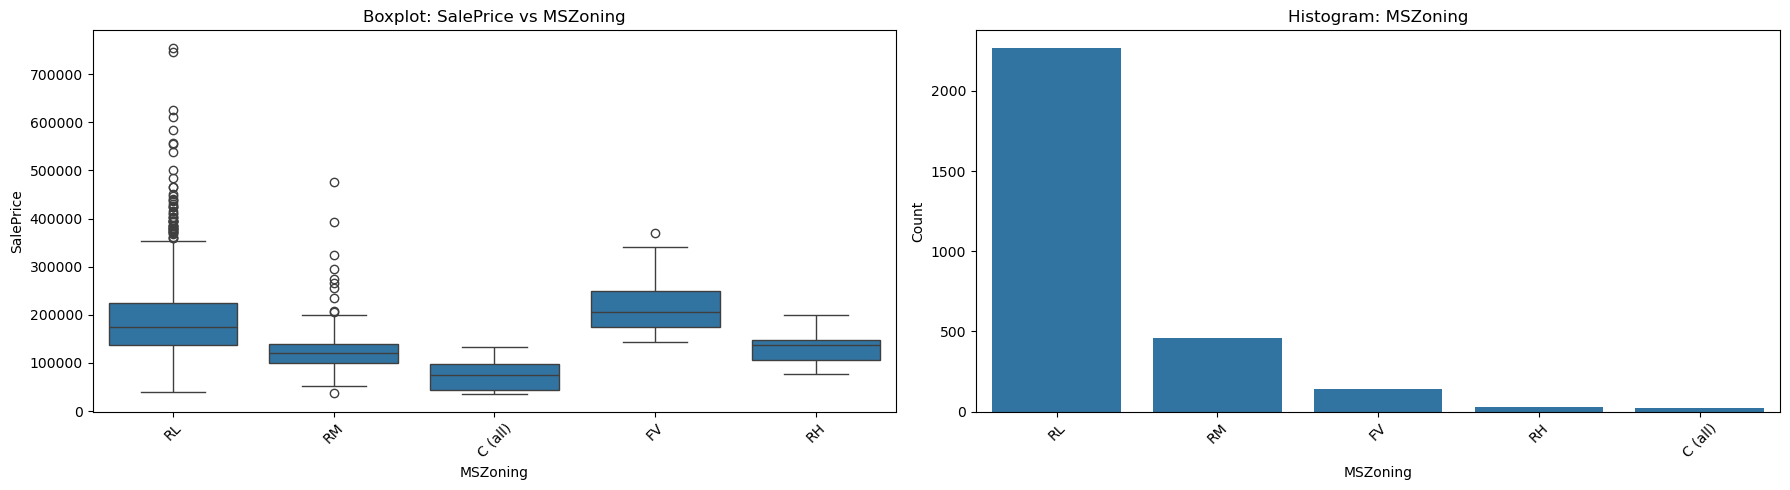

- Đã lưu: ./plots\SalePrice_vs_Street.png


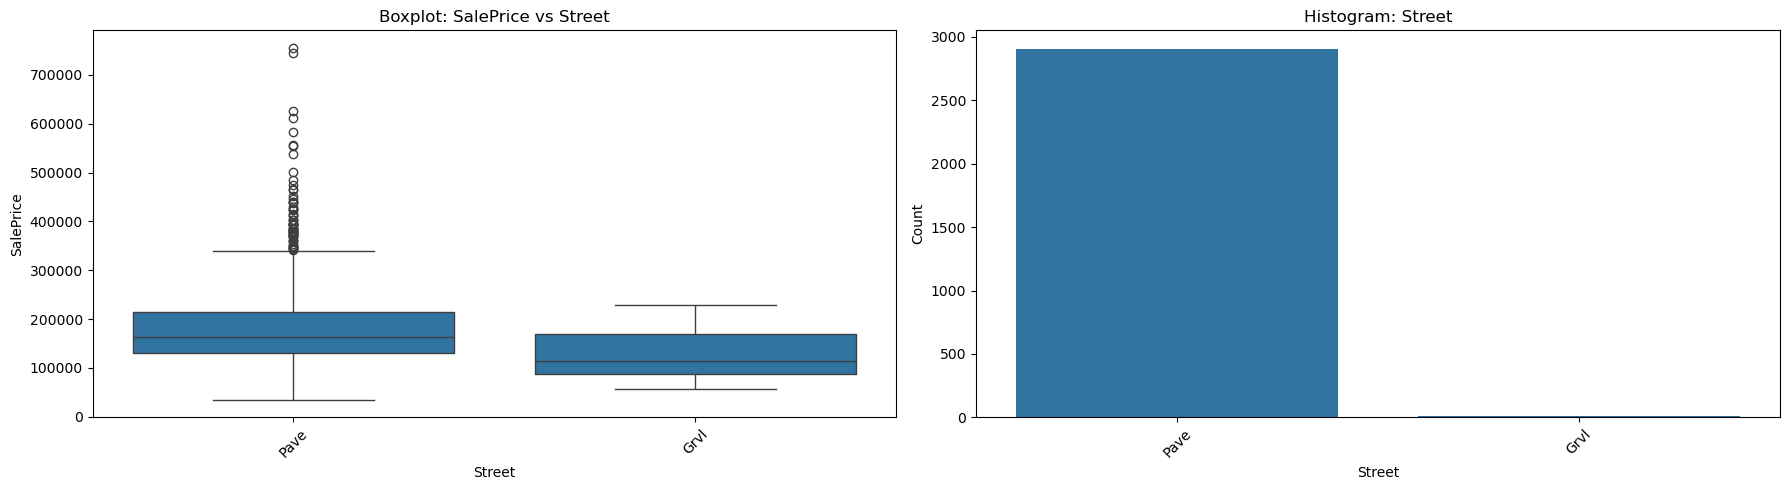

- Đã lưu: ./plots\SalePrice_vs_Alley.png


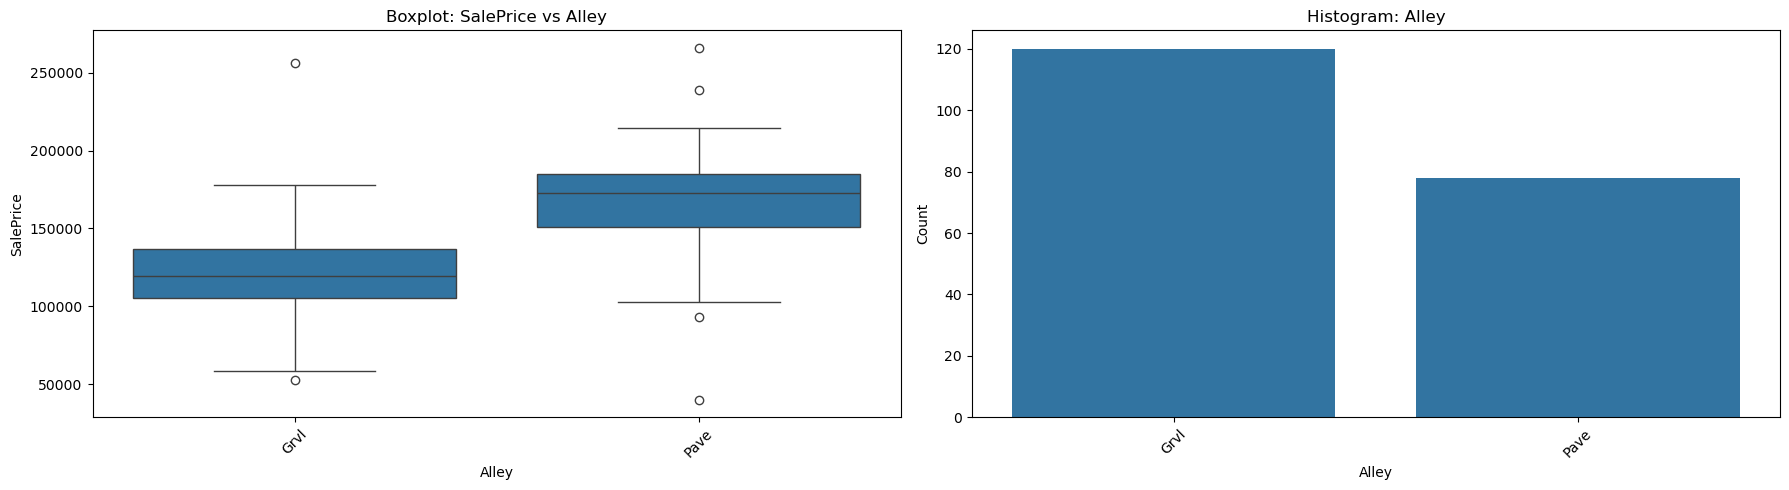

- Đã lưu: ./plots\SalePrice_vs_LotShape.png


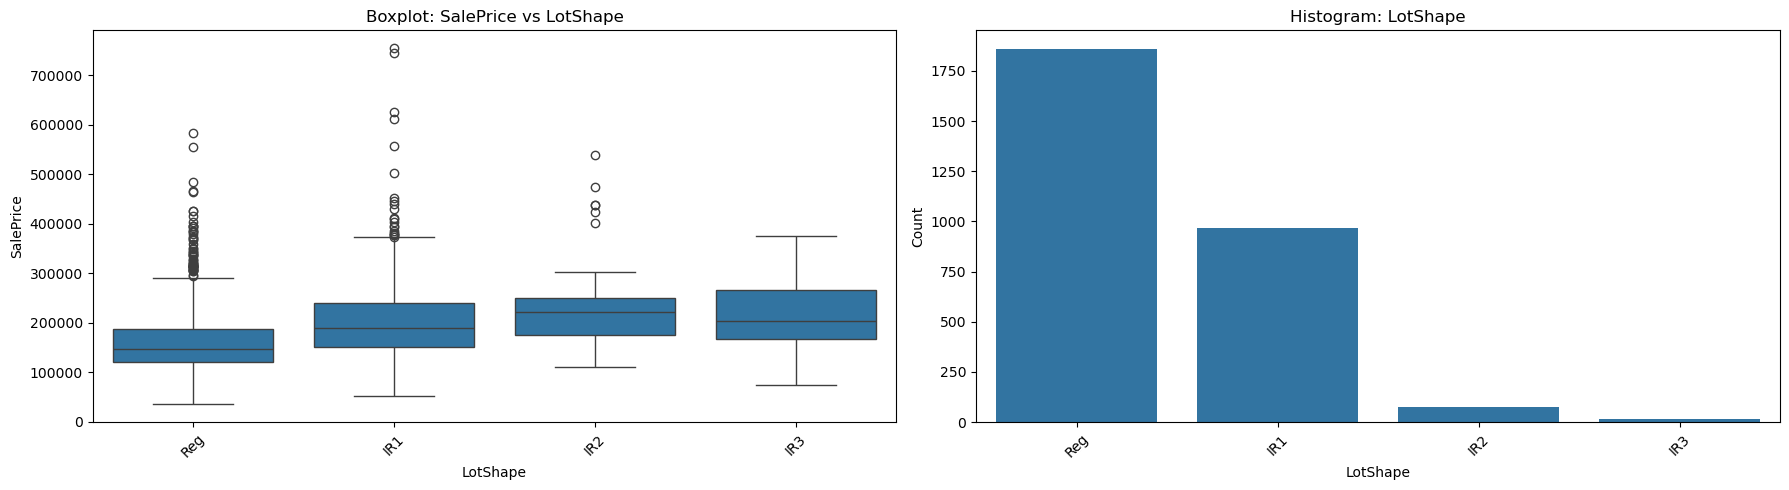

- Đã lưu: ./plots\SalePrice_vs_LandContour.png


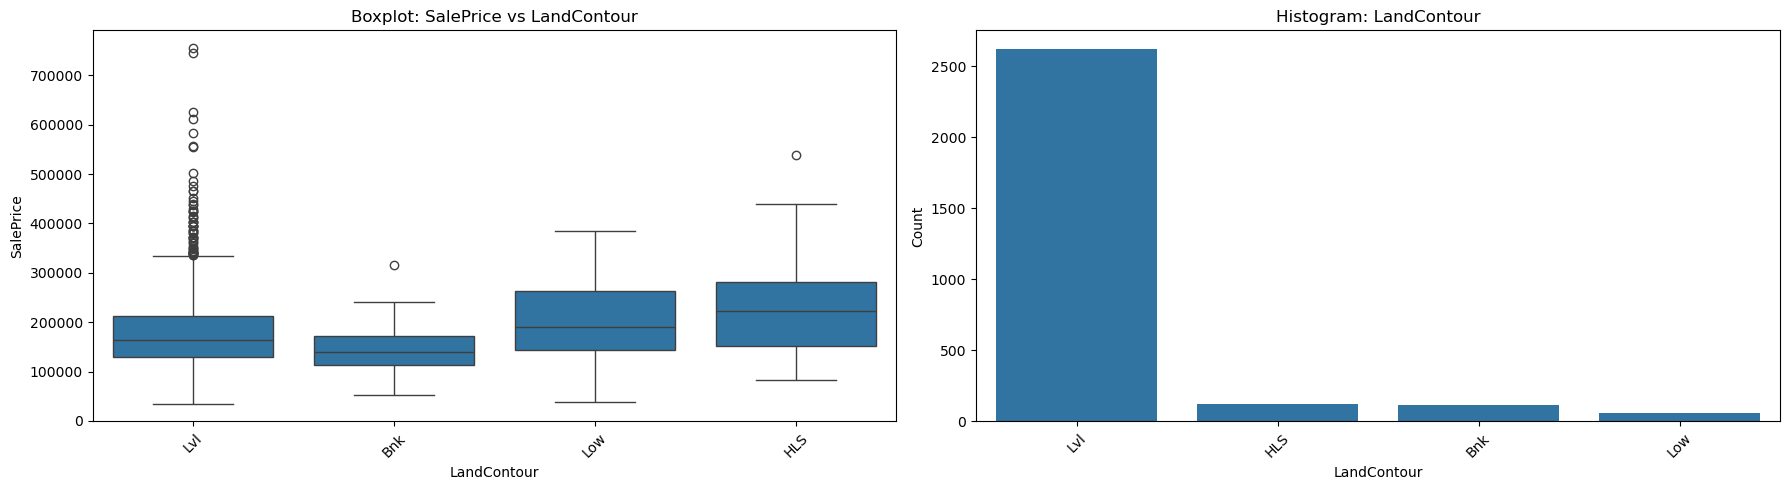

- Đã lưu: ./plots\SalePrice_vs_Utilities.png


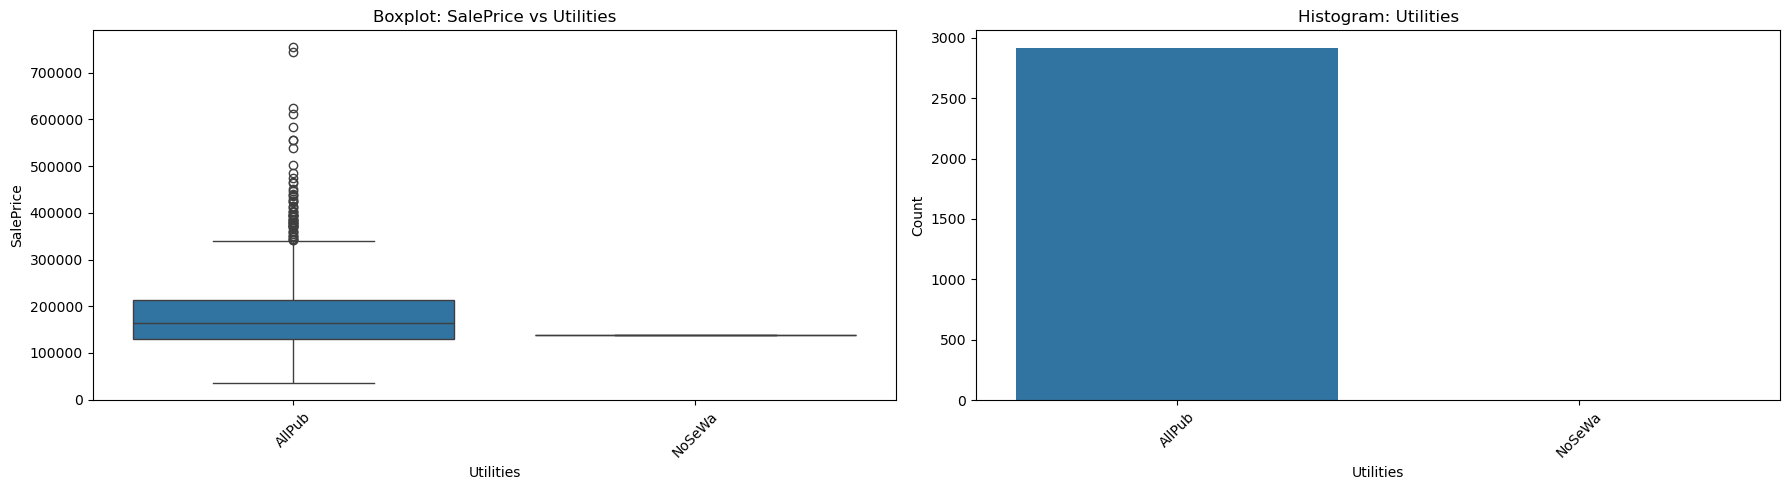

- Đã lưu: ./plots\SalePrice_vs_LotConfig.png


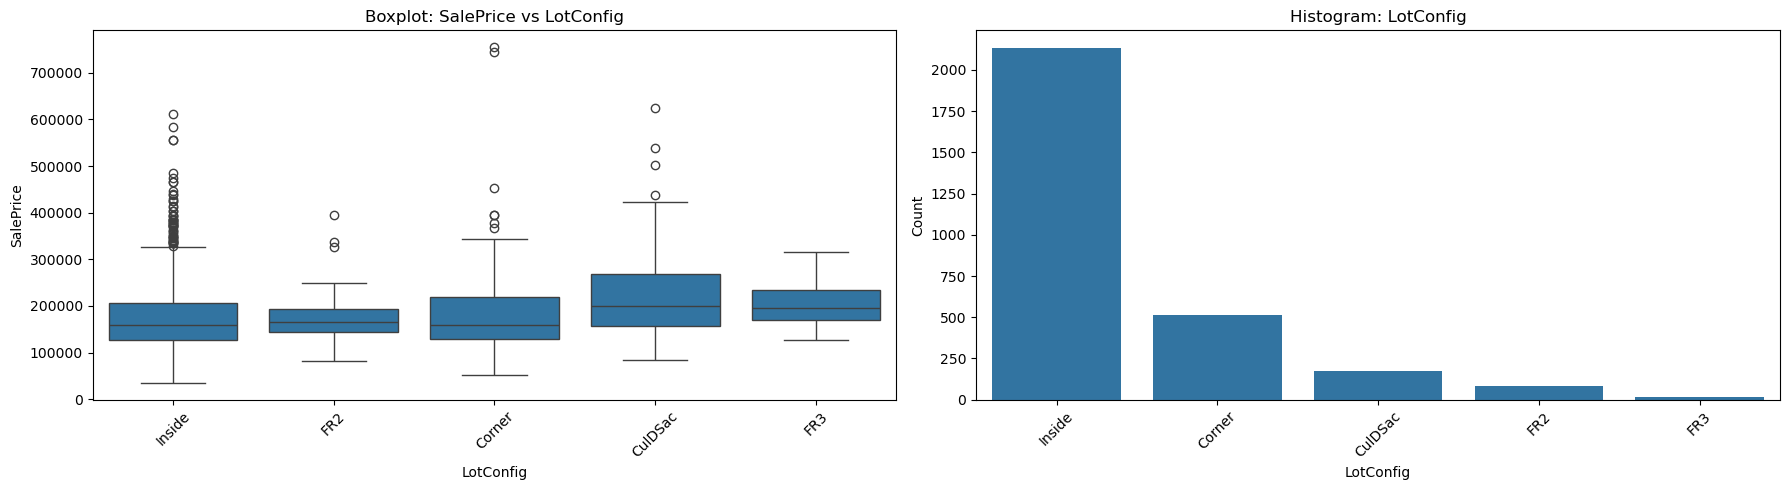

- Đã lưu: ./plots\SalePrice_vs_LandSlope.png


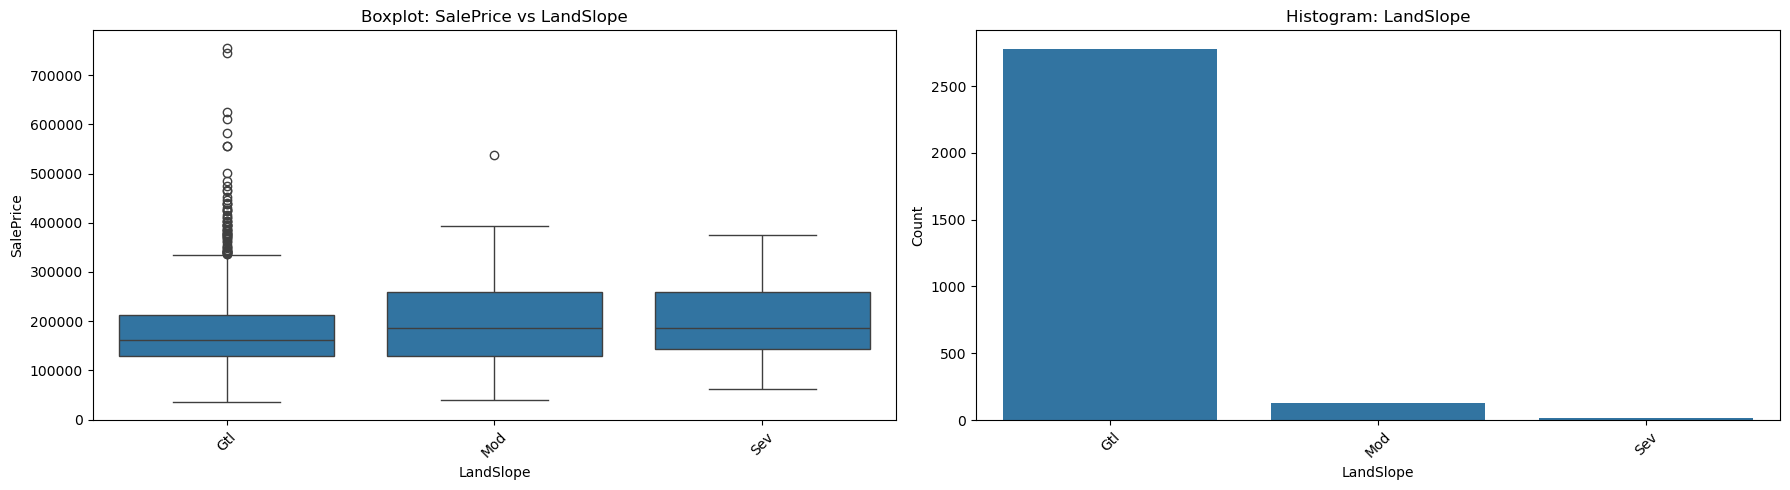

- Đã lưu: ./plots\SalePrice_vs_Neighborhood.png


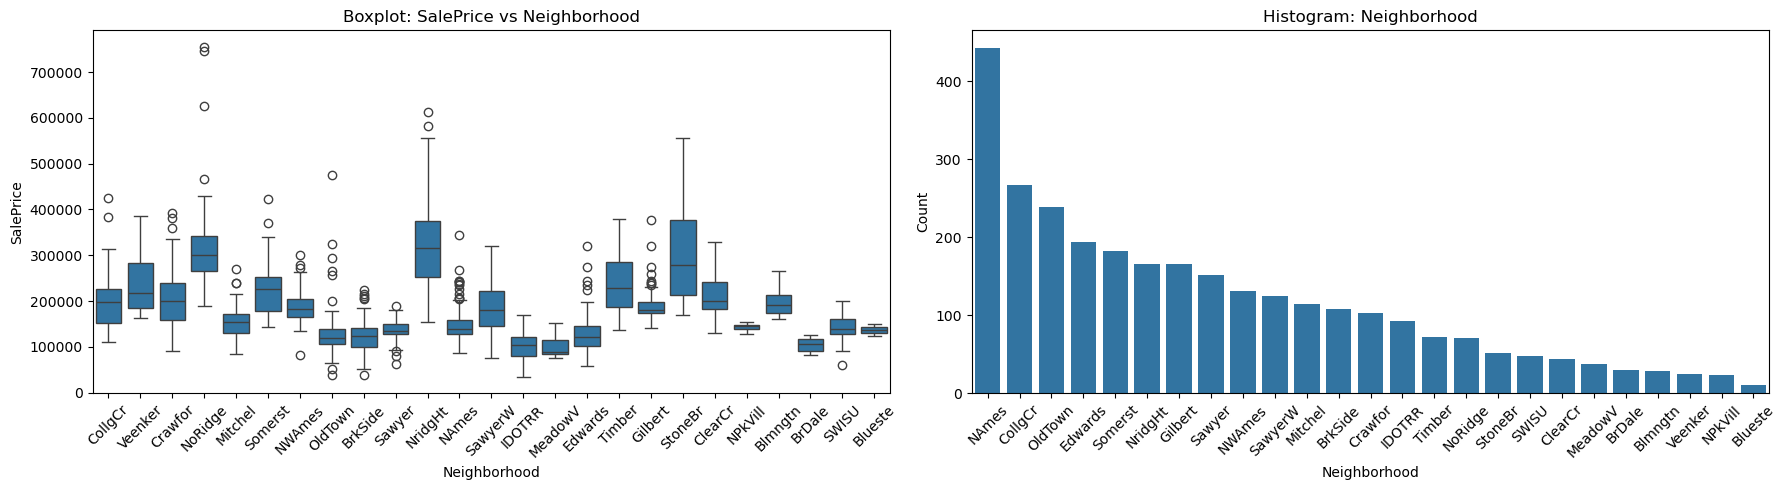

- Đã lưu: ./plots\SalePrice_vs_Condition1.png


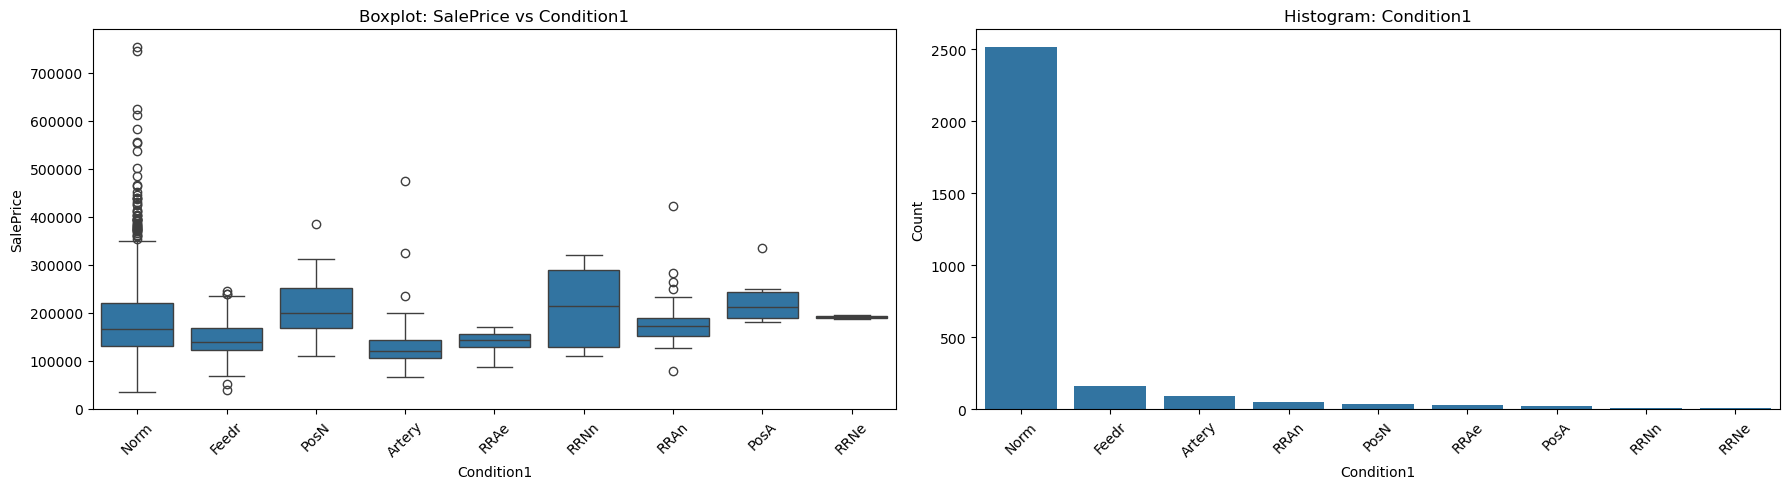

- Đã lưu: ./plots\SalePrice_vs_Condition2.png


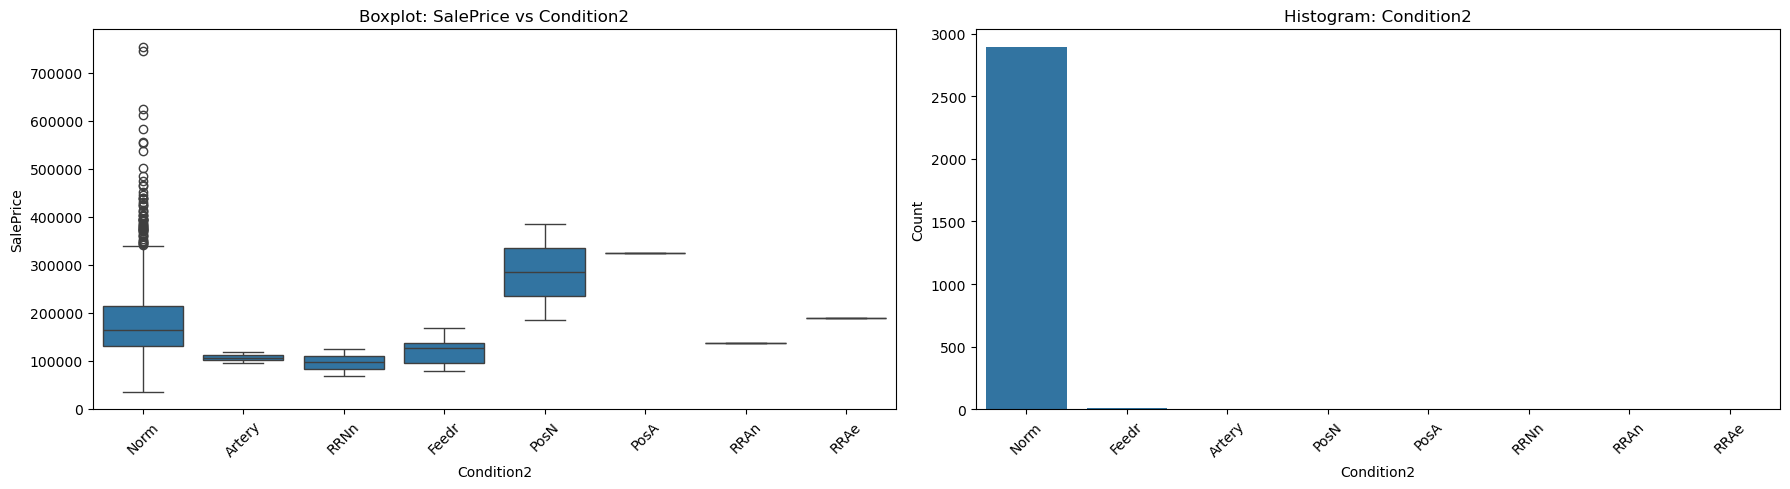

- Đã lưu: ./plots\SalePrice_vs_BldgType.png


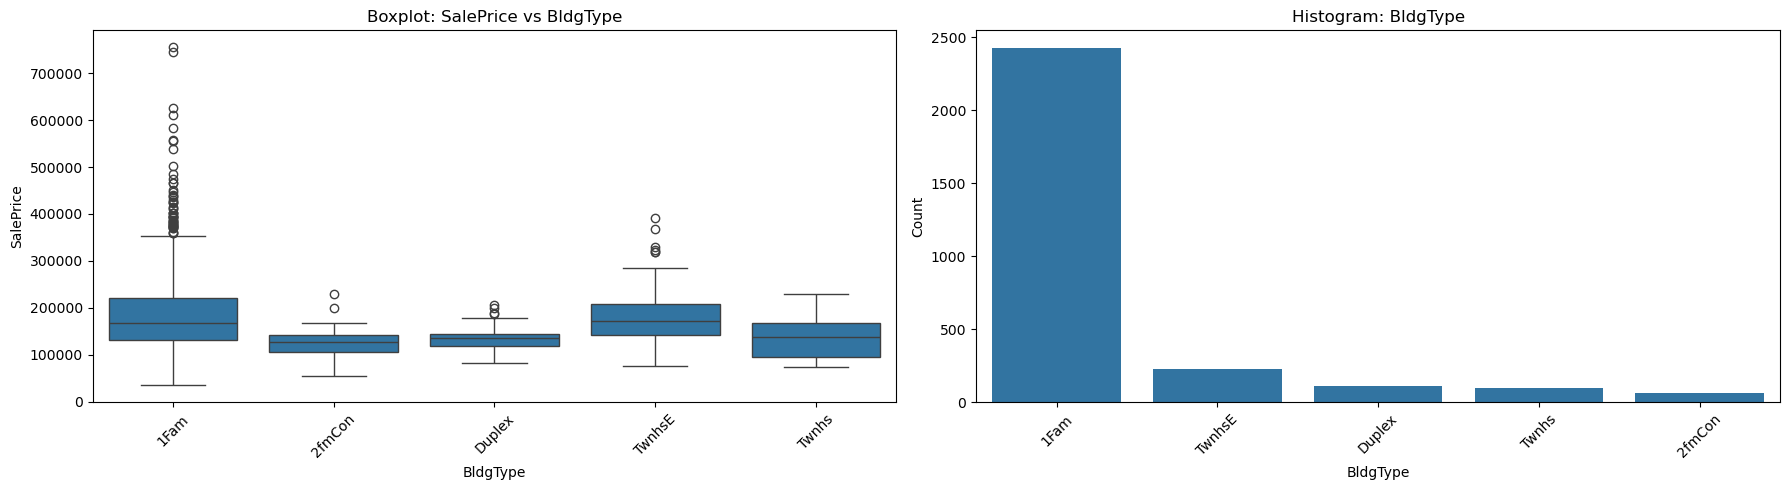

- Đã lưu: ./plots\SalePrice_vs_HouseStyle.png


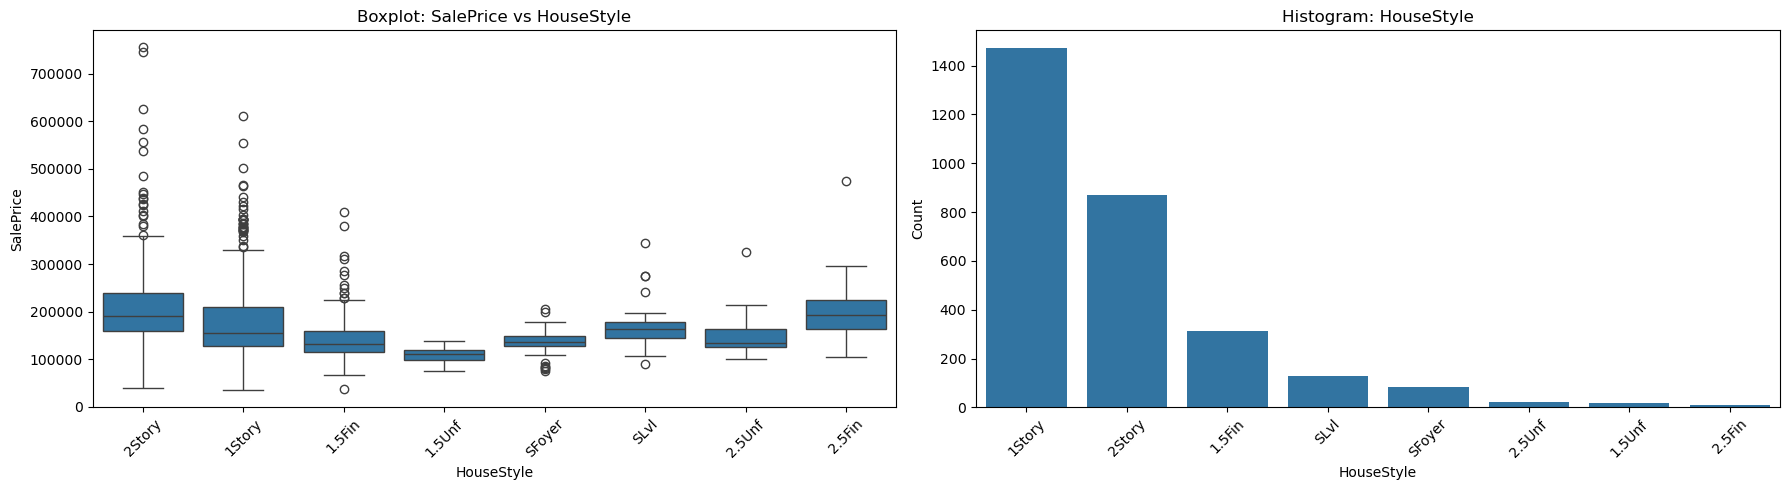

- Đã lưu: ./plots\SalePrice_vs_RoofStyle.png


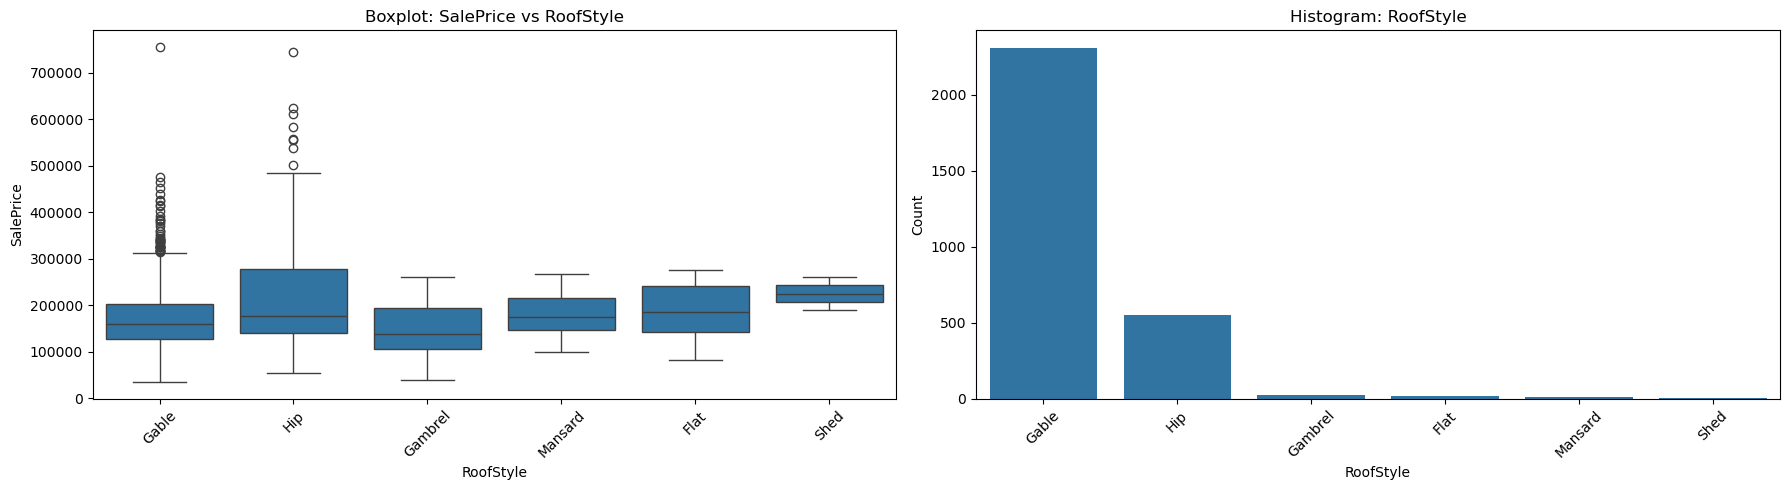

- Đã lưu: ./plots\SalePrice_vs_RoofMatl.png


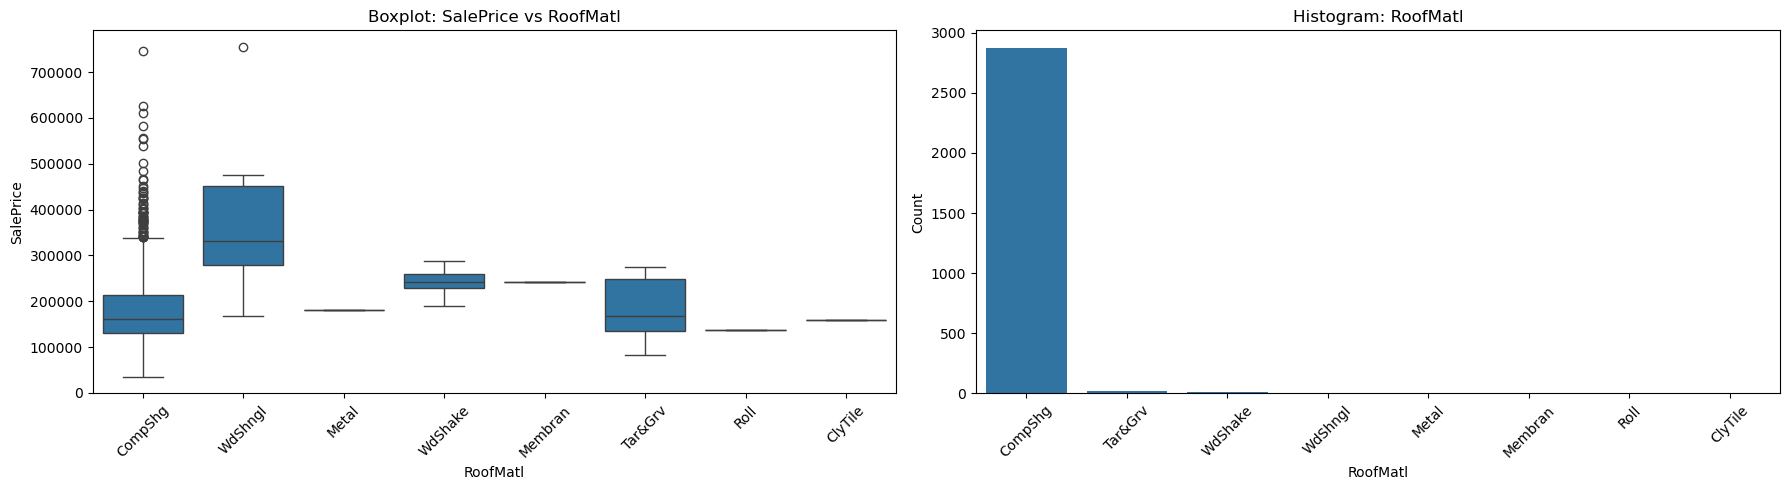

- Đã lưu: ./plots\SalePrice_vs_Exterior1st.png


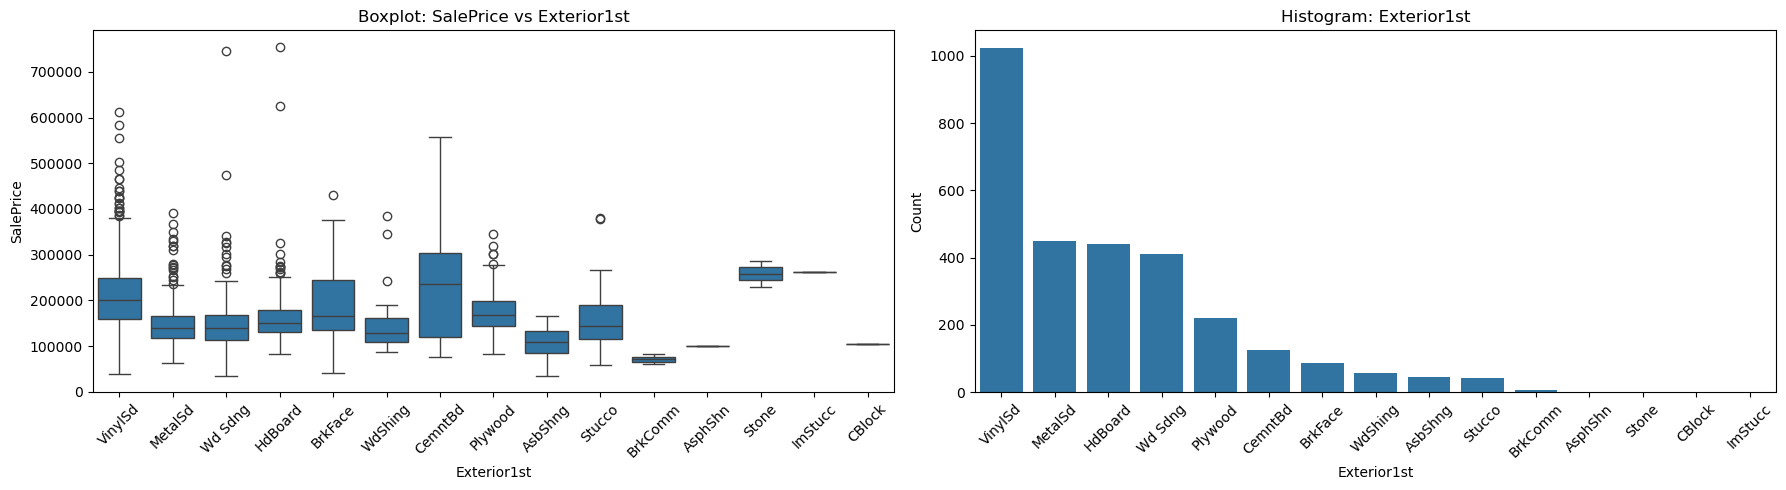

- Đã lưu: ./plots\SalePrice_vs_Exterior2nd.png


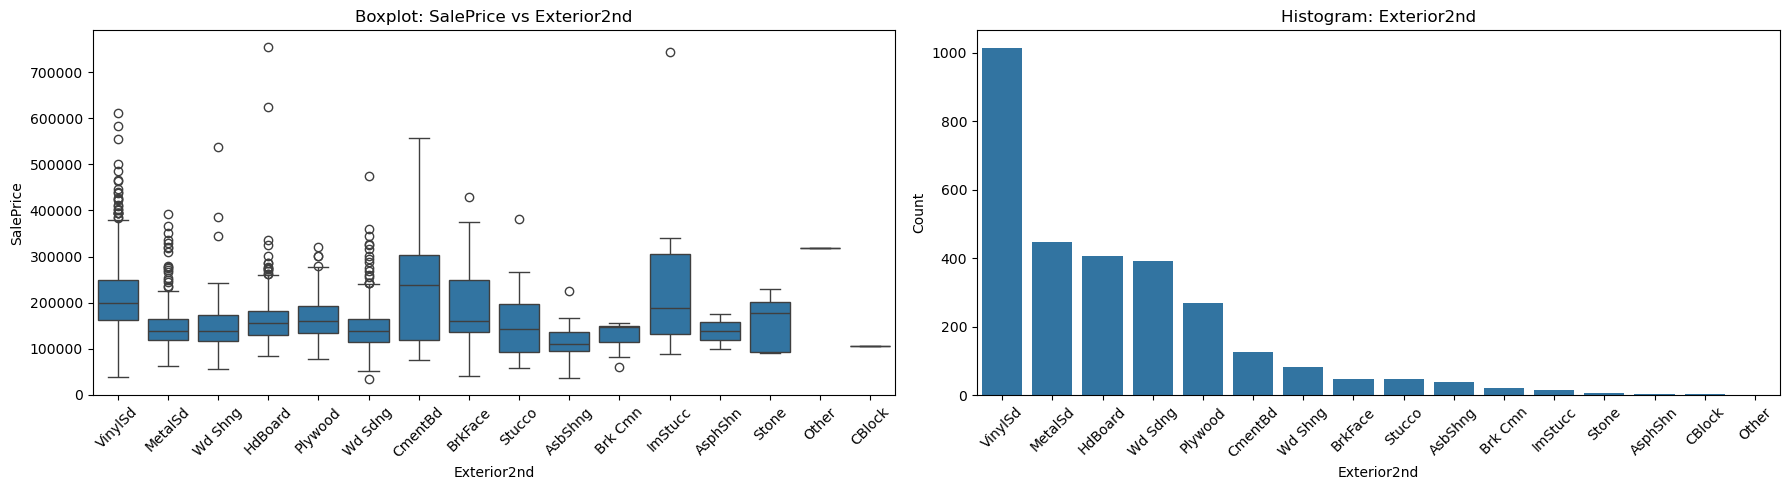

- Đã lưu: ./plots\SalePrice_vs_MasVnrType.png


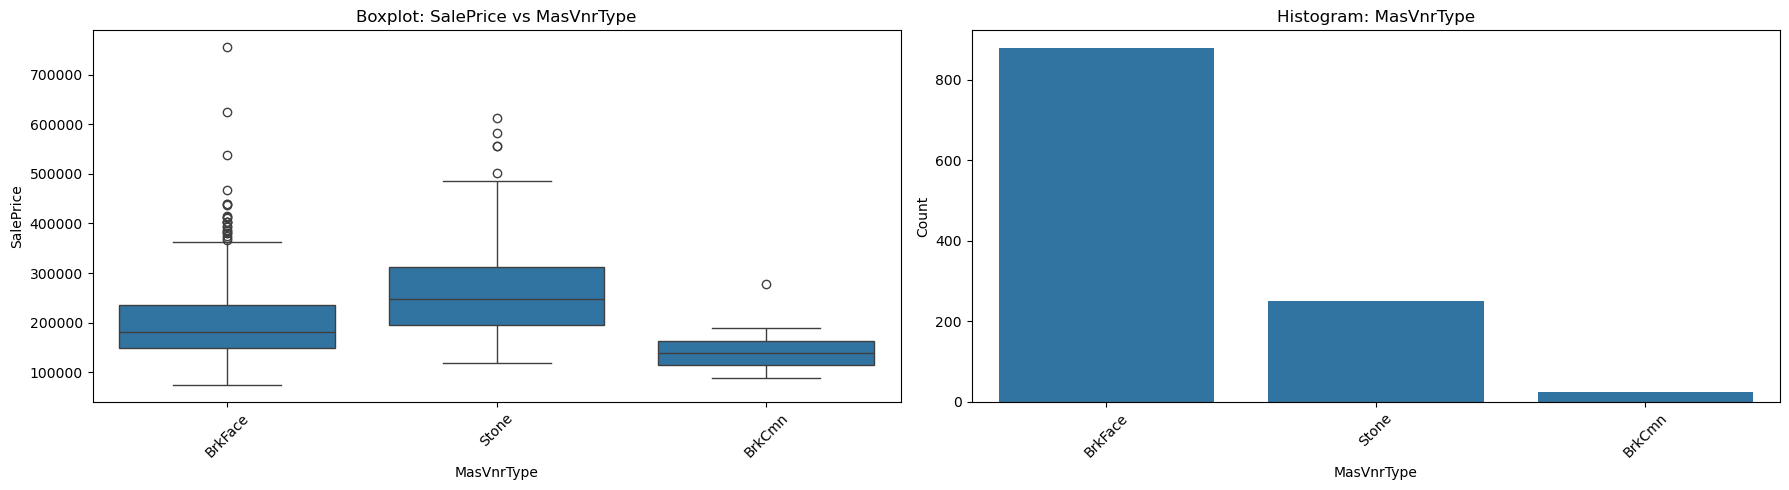

- Đã lưu: ./plots\SalePrice_vs_ExterQual.png


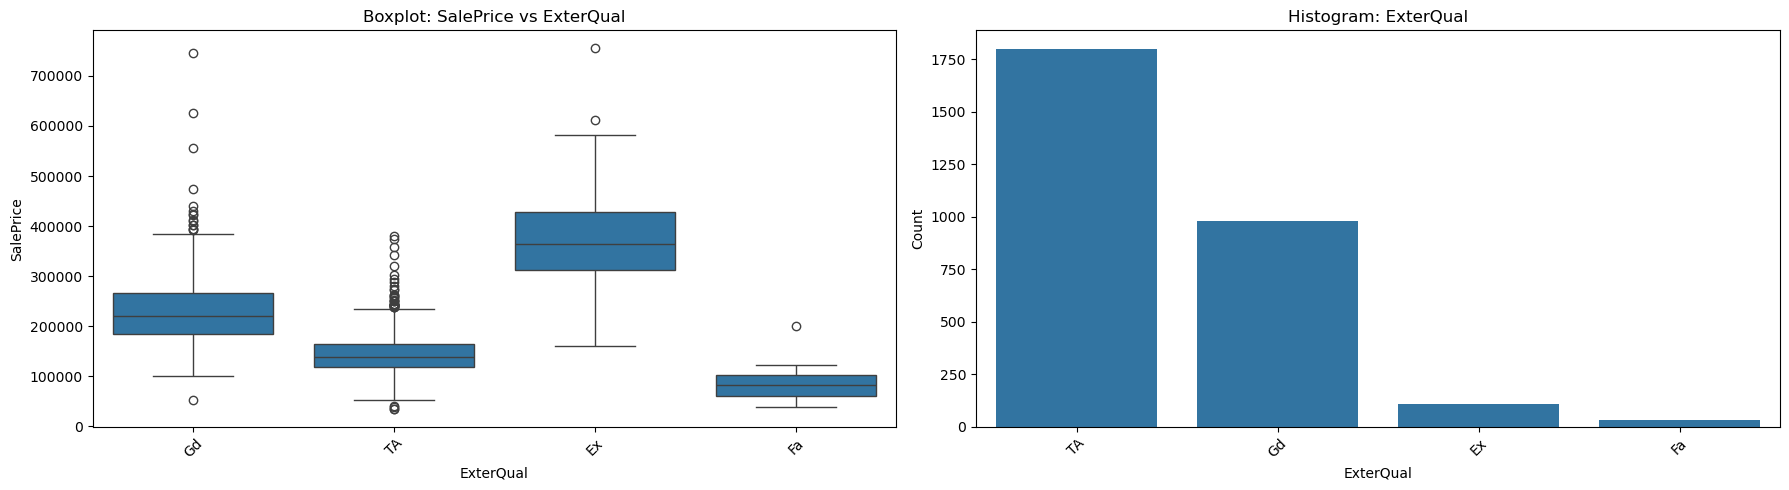

- Đã lưu: ./plots\SalePrice_vs_ExterCond.png


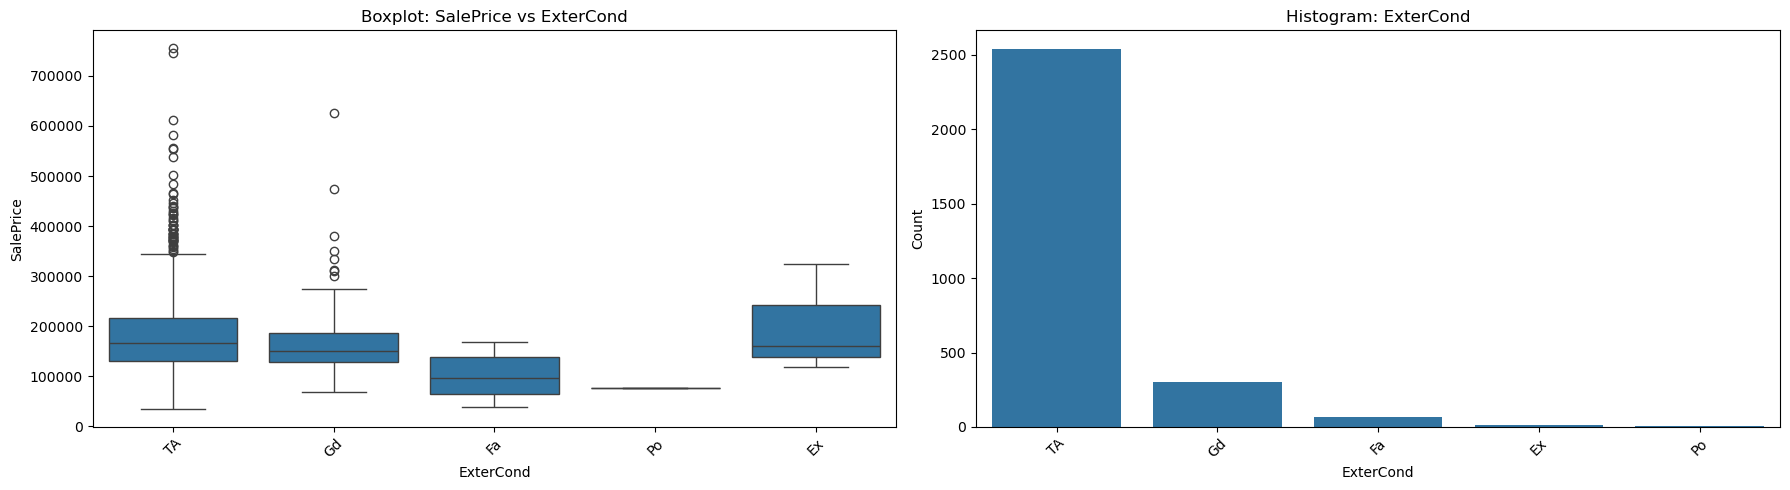

- Đã lưu: ./plots\SalePrice_vs_Foundation.png


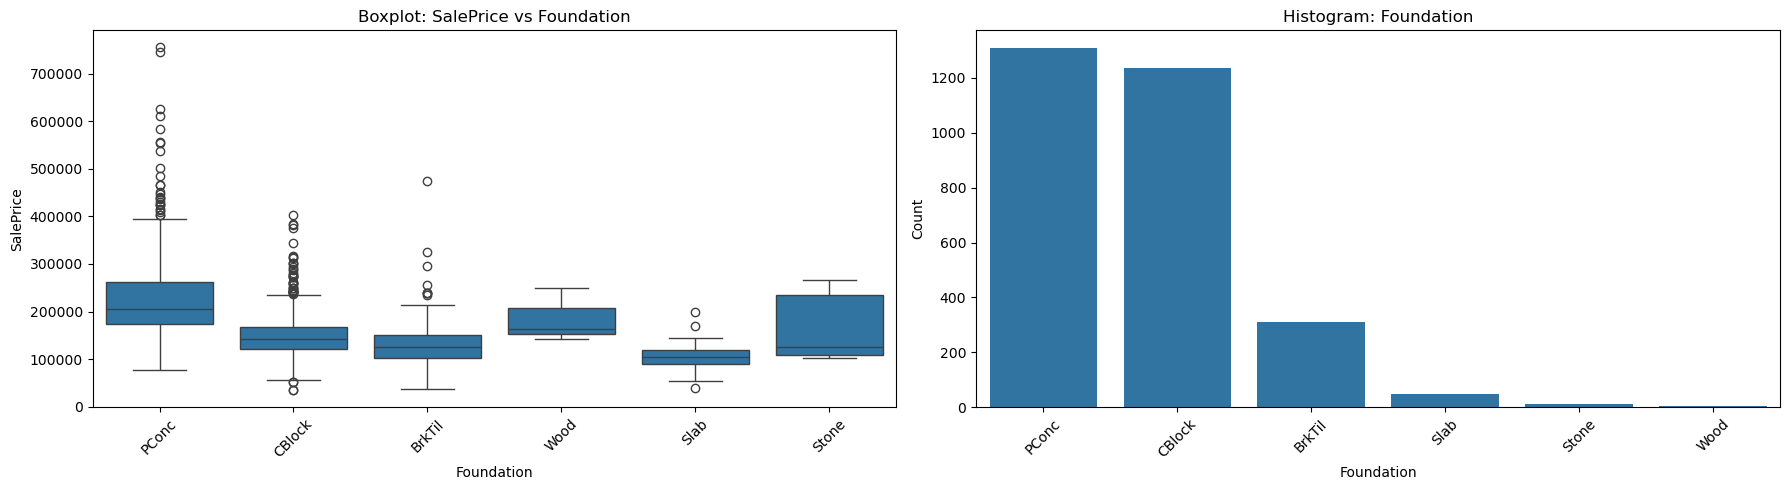

- Đã lưu: ./plots\SalePrice_vs_BsmtQual.png


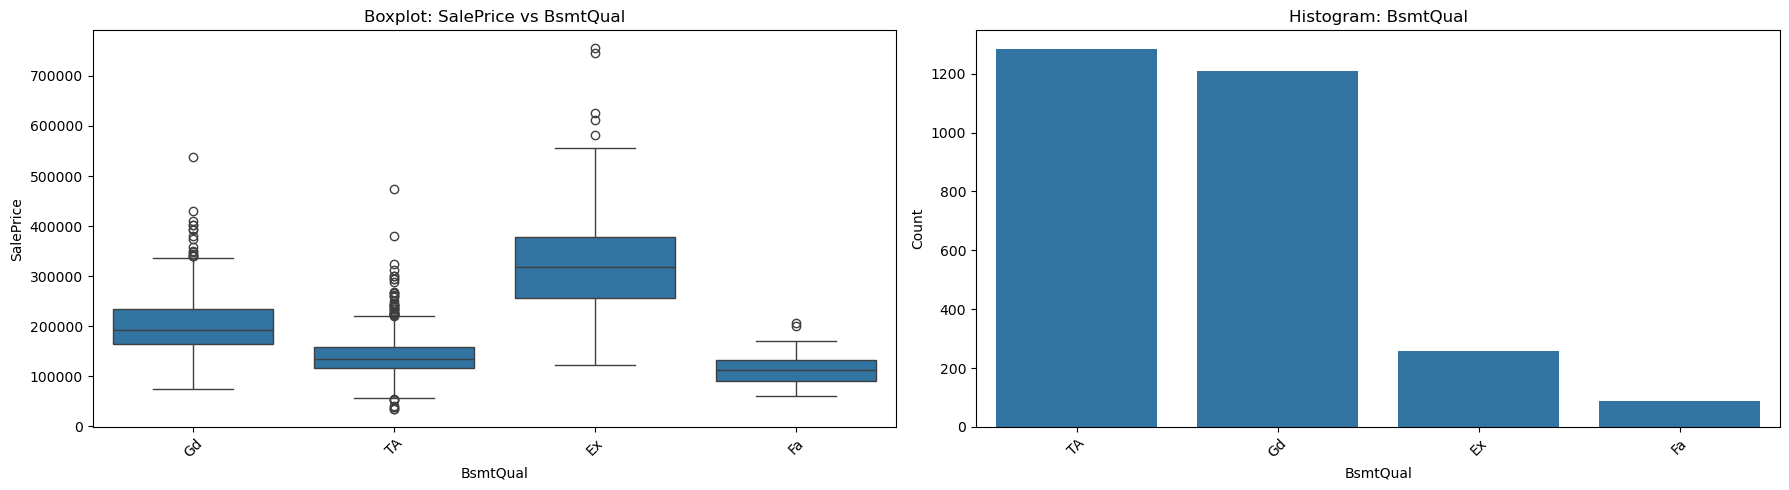

- Đã lưu: ./plots\SalePrice_vs_BsmtCond.png


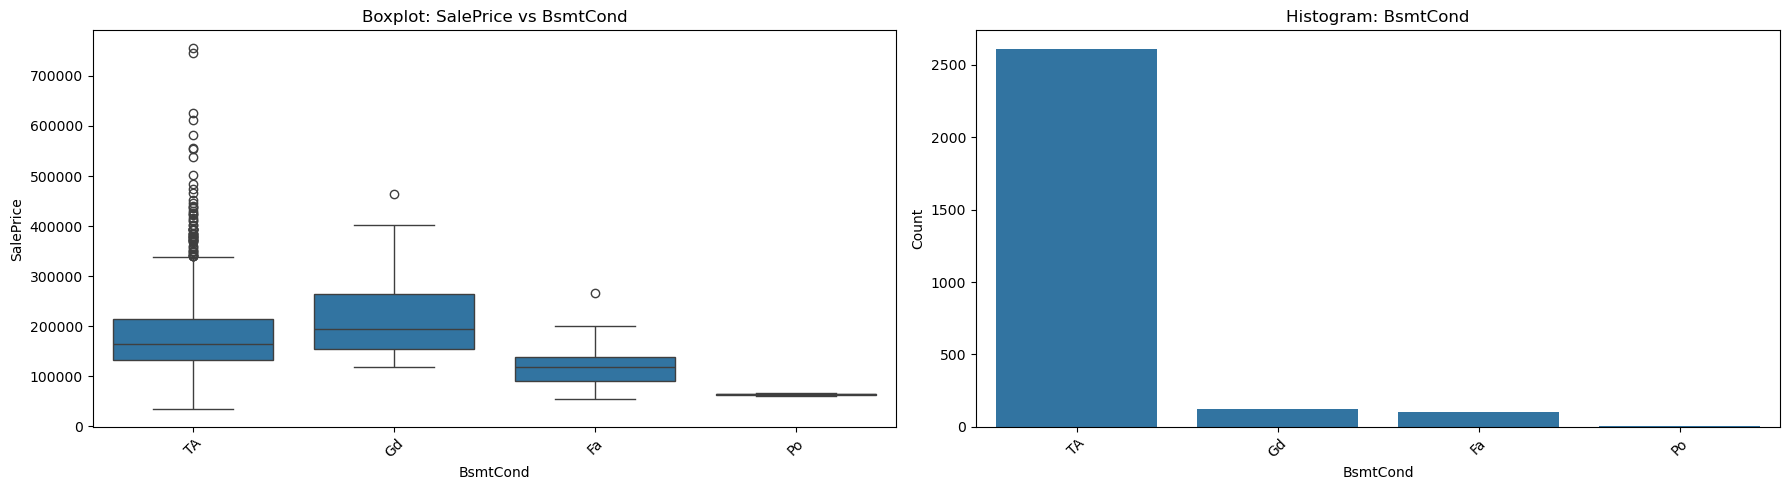

- Đã lưu: ./plots\SalePrice_vs_BsmtExposure.png


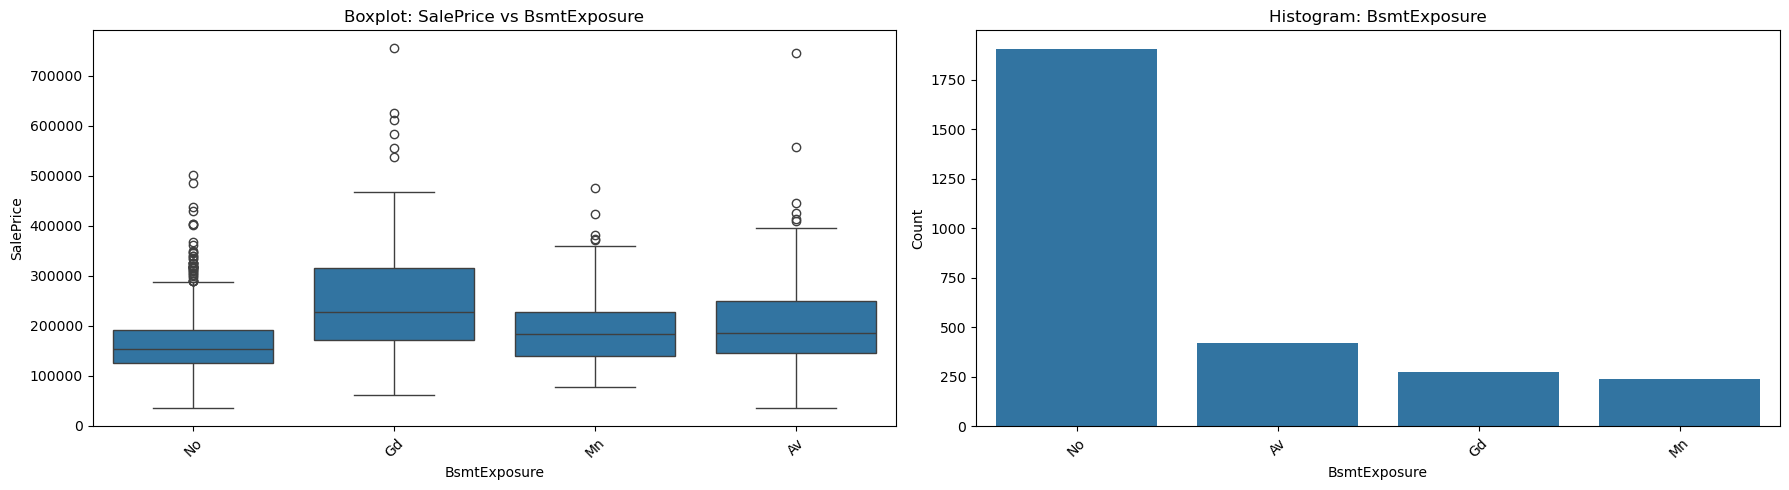

- Đã lưu: ./plots\SalePrice_vs_BsmtFinType1.png


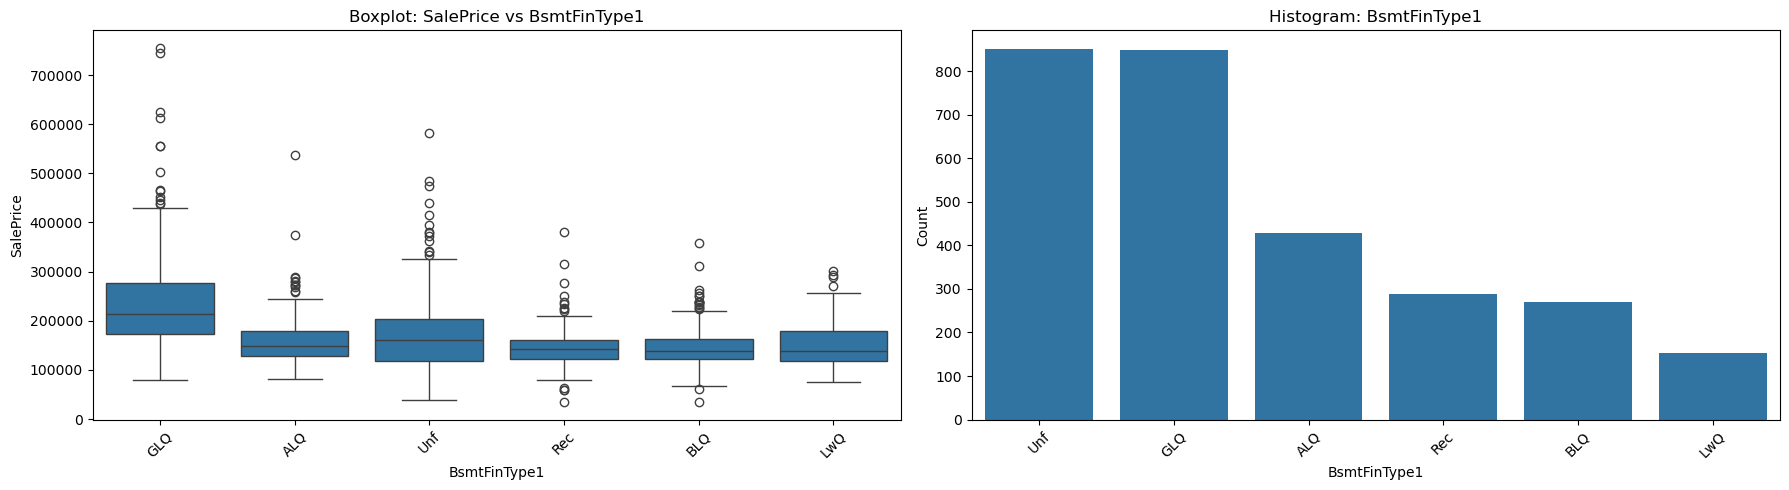

- Đã lưu: ./plots\SalePrice_vs_BsmtFinType2.png


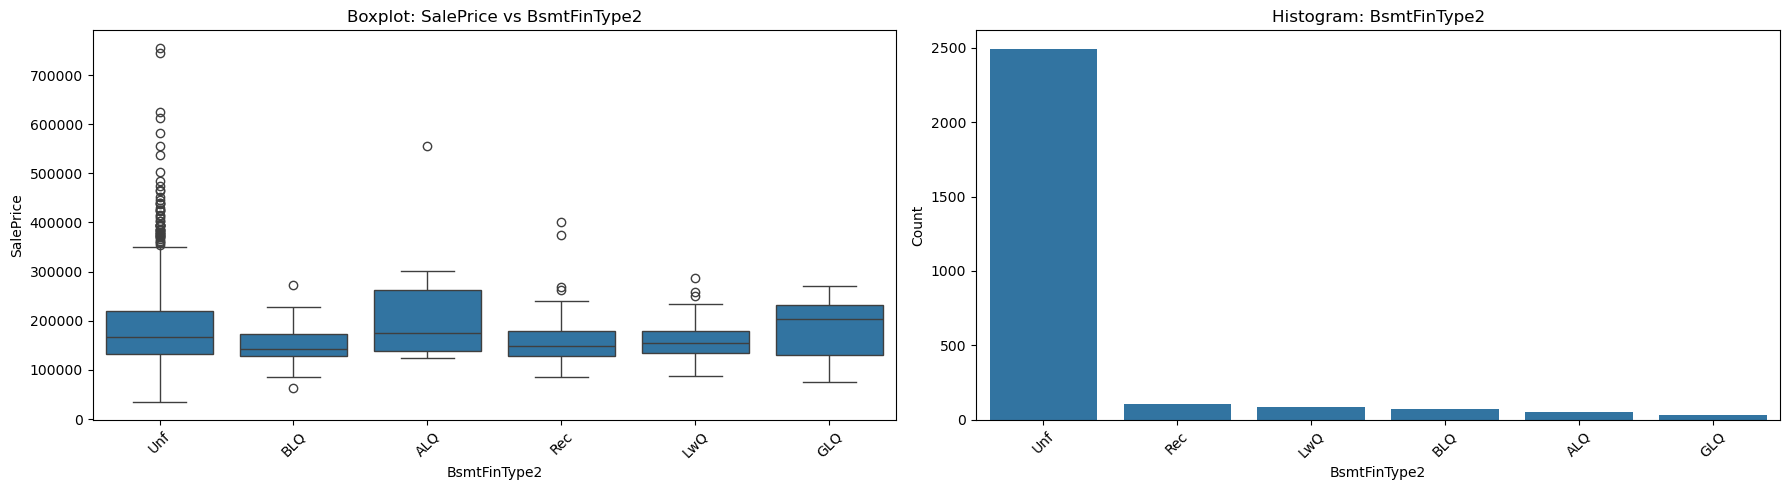

- Đã lưu: ./plots\SalePrice_vs_Heating.png


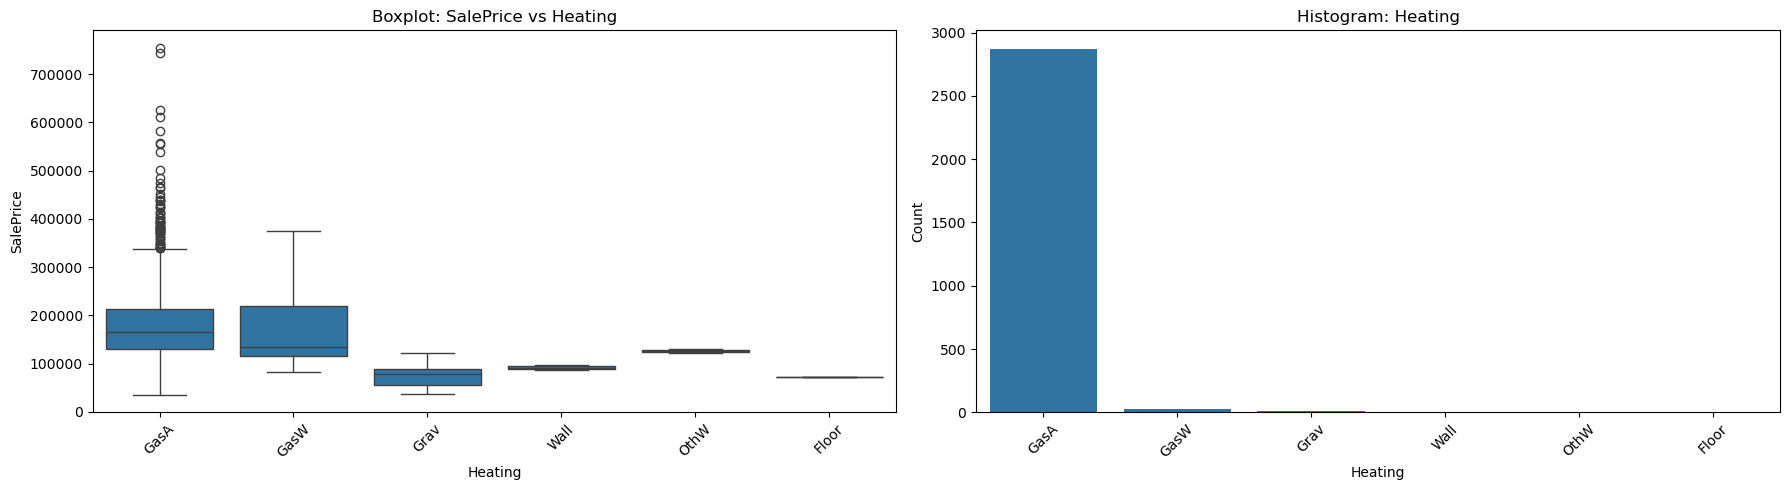

- Đã lưu: ./plots\SalePrice_vs_HeatingQC.png


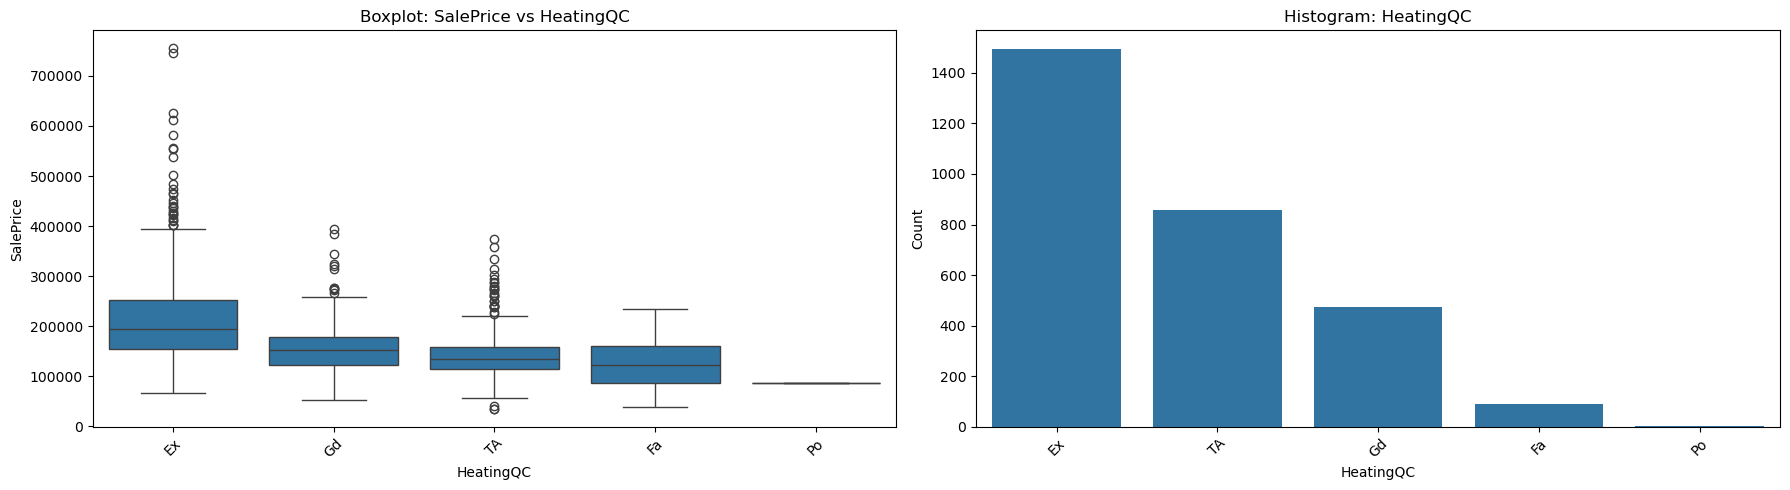

- Đã lưu: ./plots\SalePrice_vs_CentralAir.png


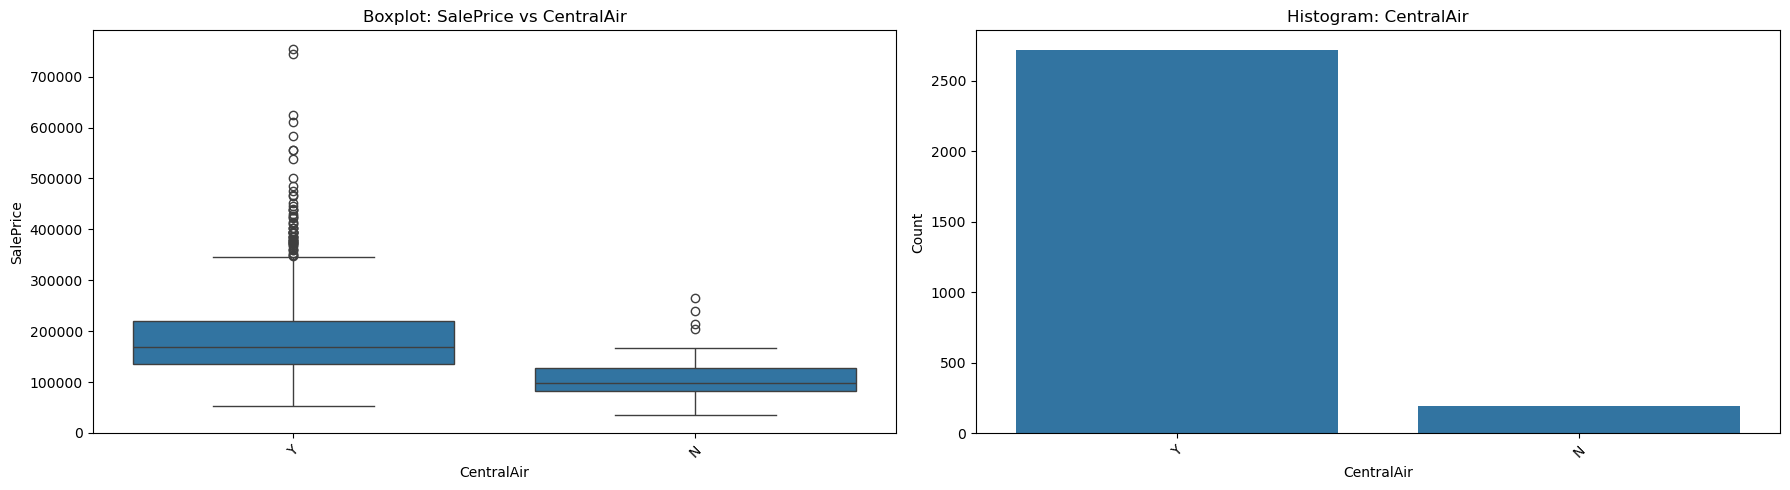

- Đã lưu: ./plots\SalePrice_vs_Electrical.png


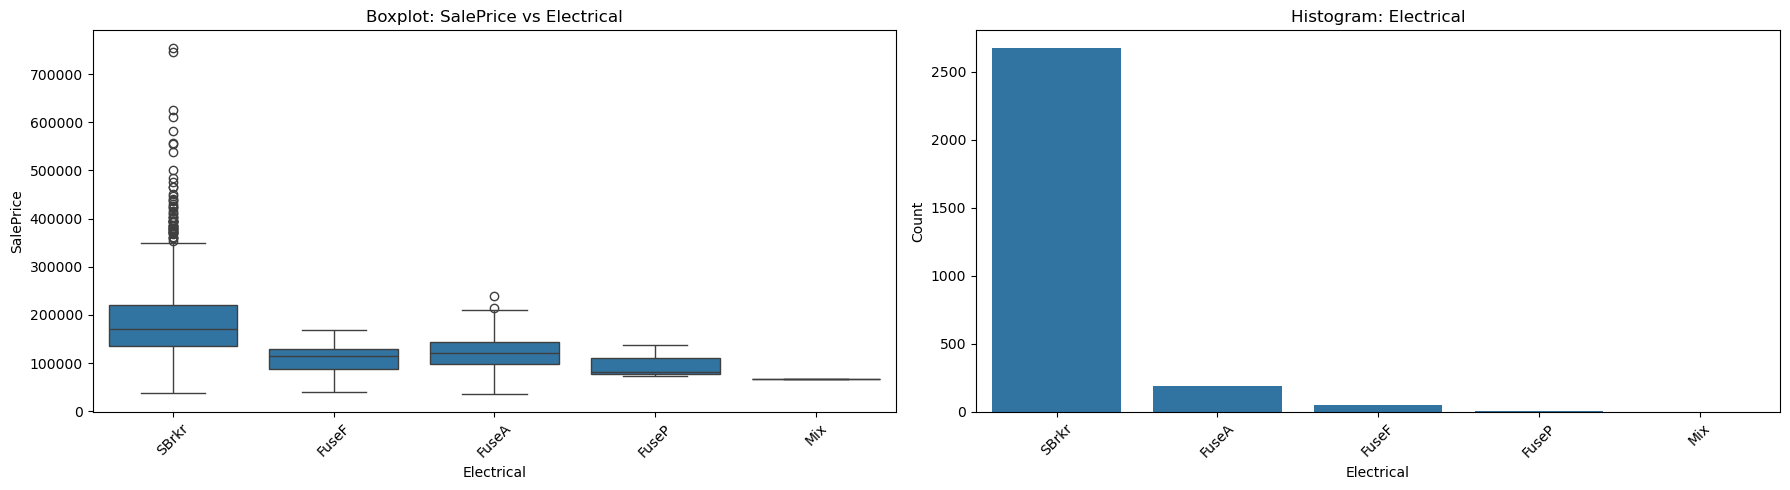

- Đã lưu: ./plots\SalePrice_vs_KitchenQual.png


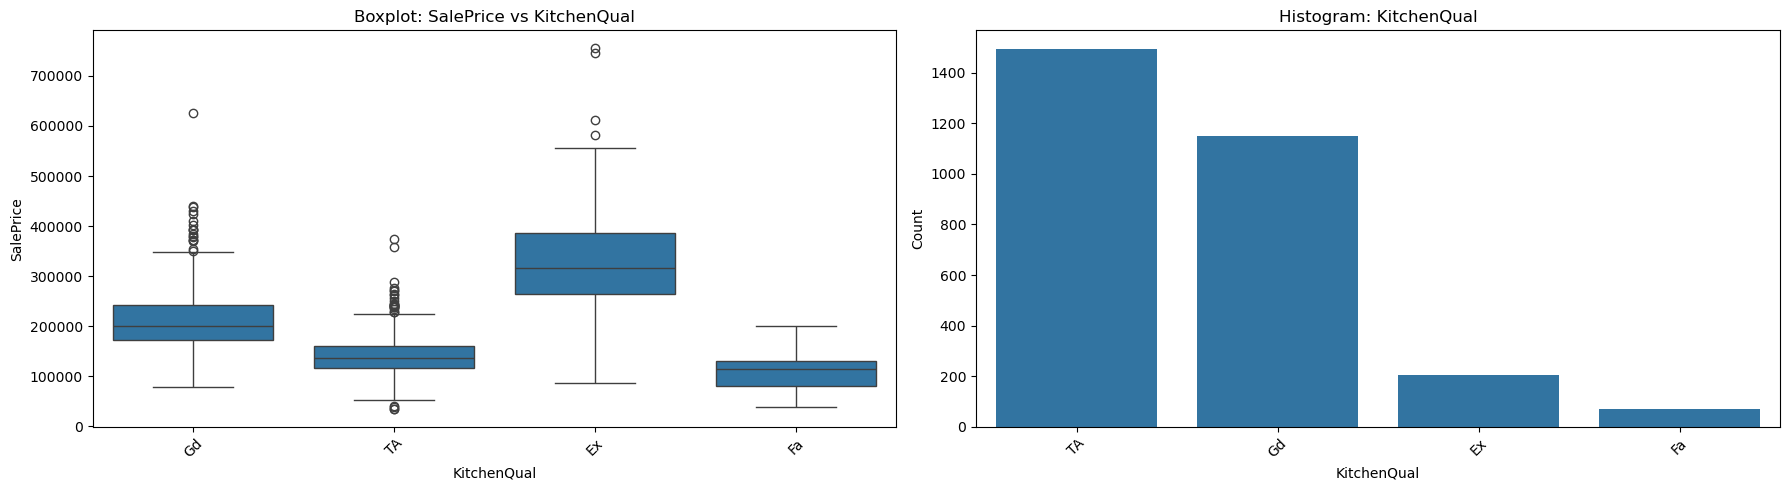

- Đã lưu: ./plots\SalePrice_vs_Functional.png


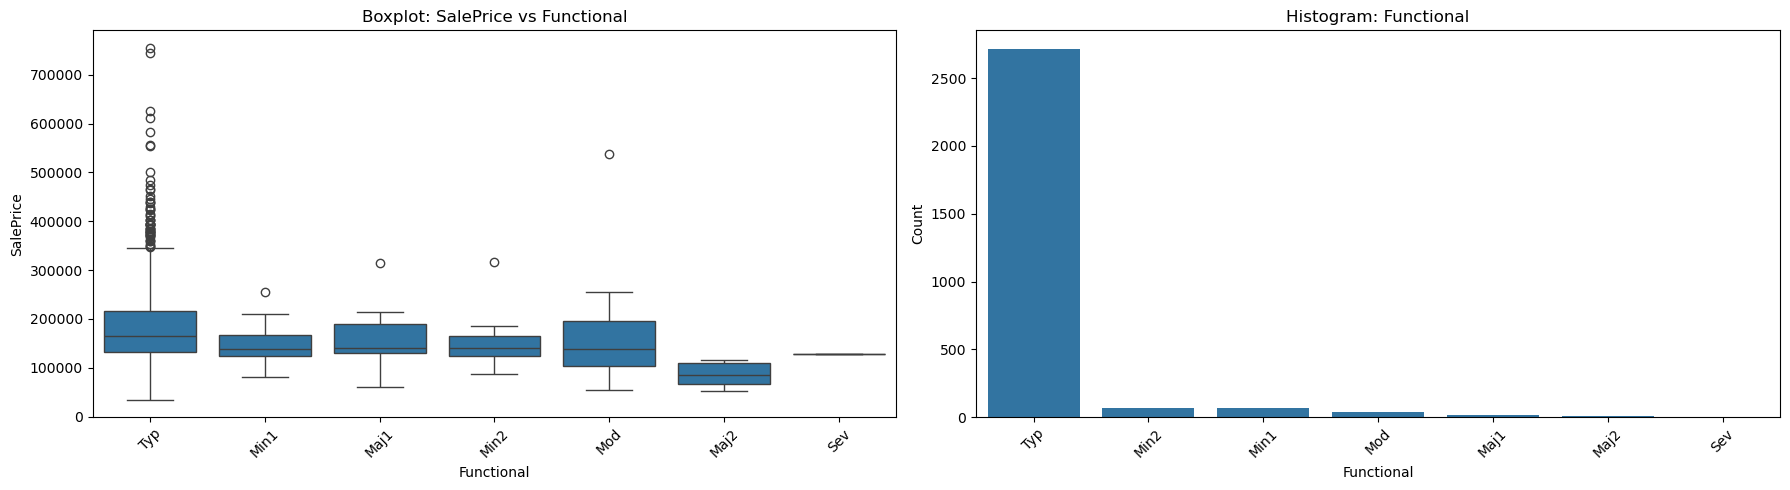

- Đã lưu: ./plots\SalePrice_vs_FireplaceQu.png


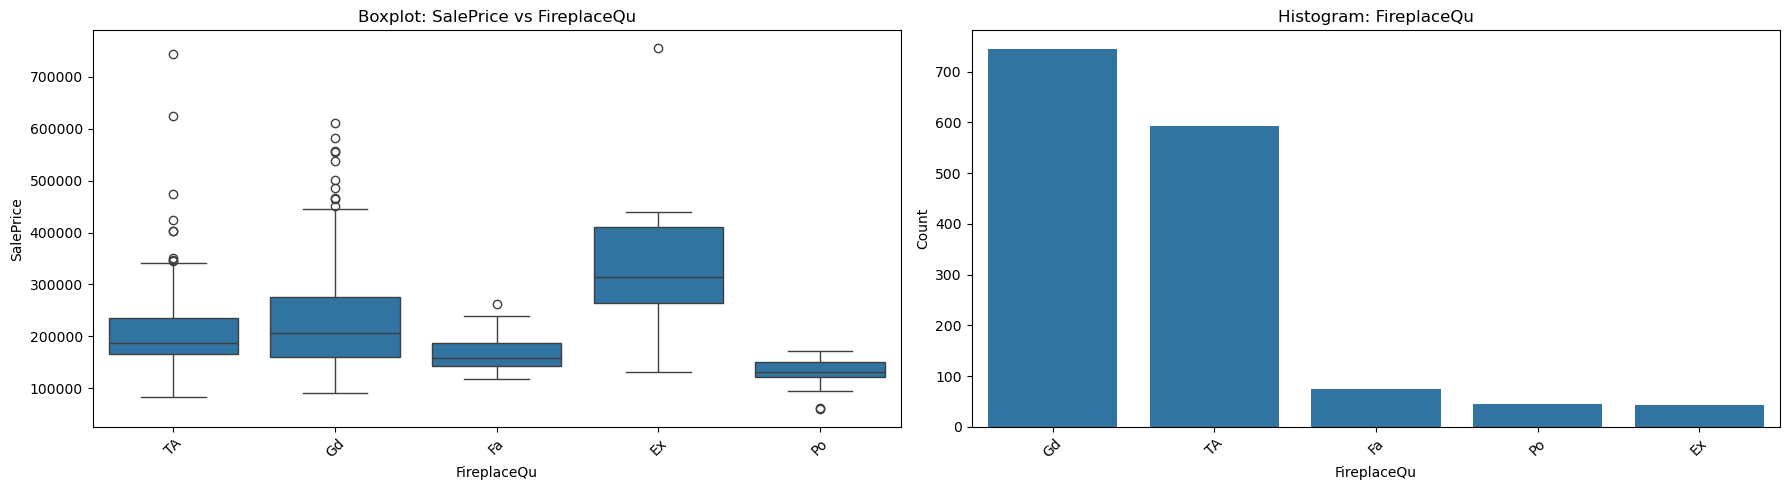

- Đã lưu: ./plots\SalePrice_vs_GarageType.png


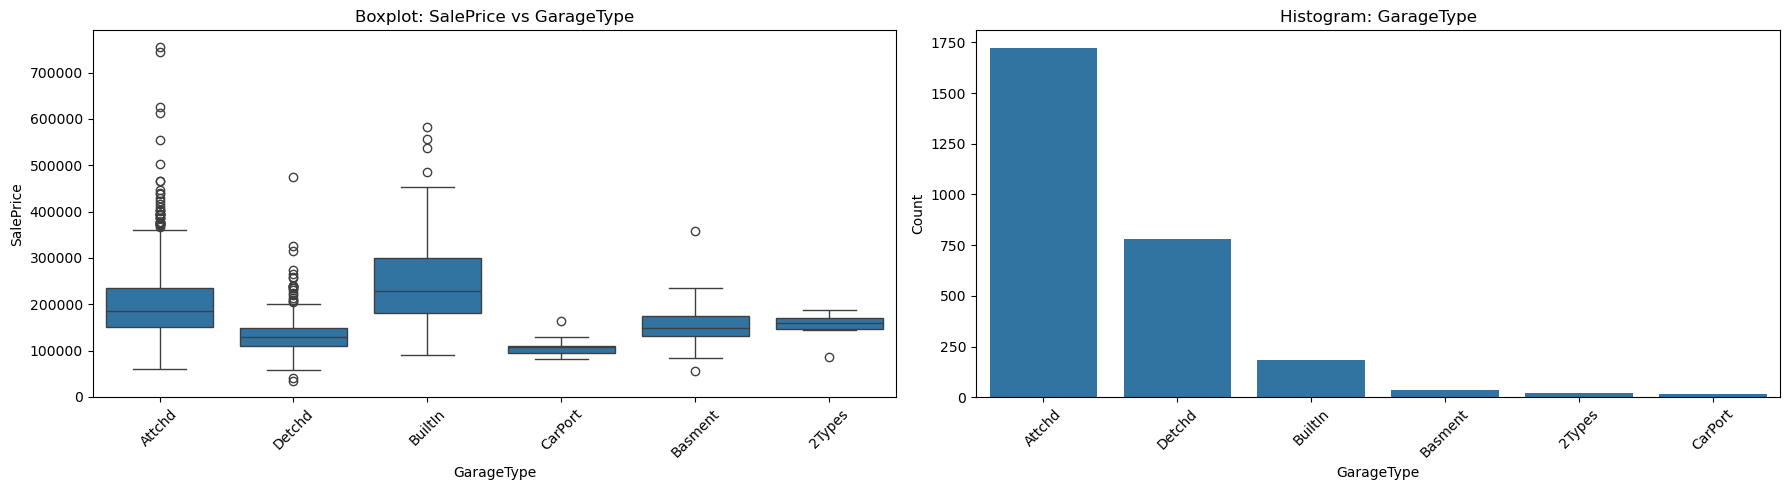

- Đã lưu: ./plots\SalePrice_vs_GarageFinish.png


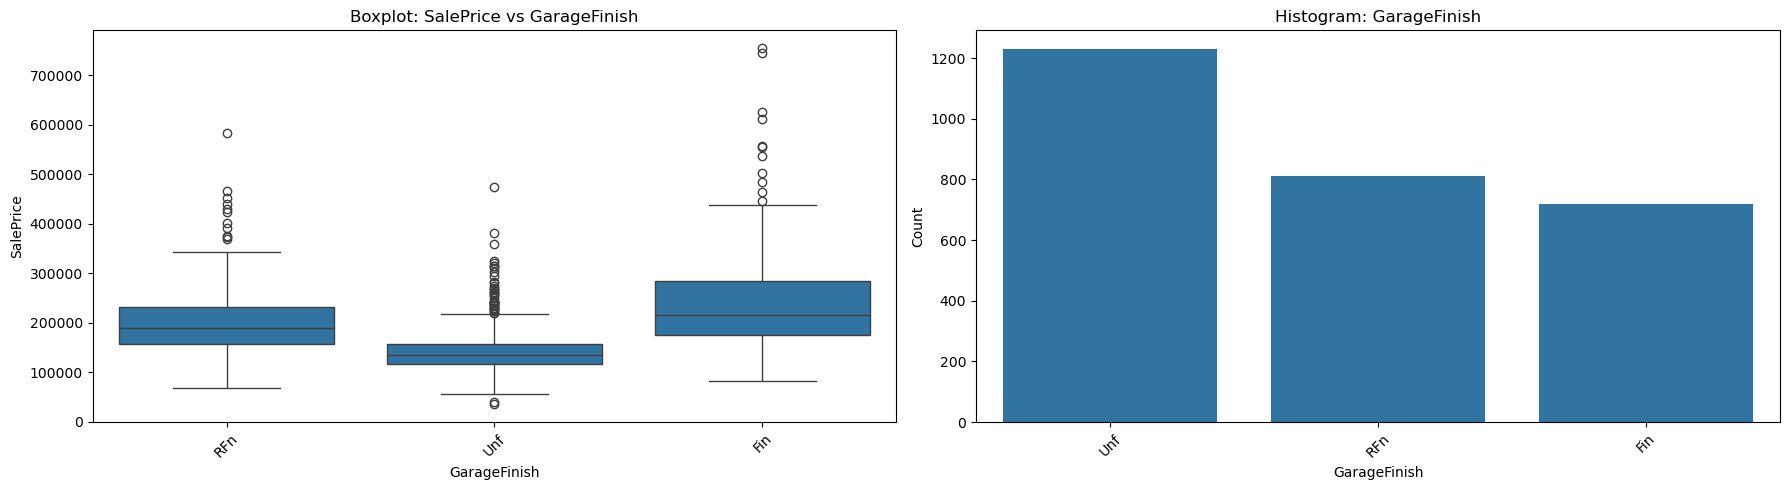

- Đã lưu: ./plots\SalePrice_vs_GarageQual.png


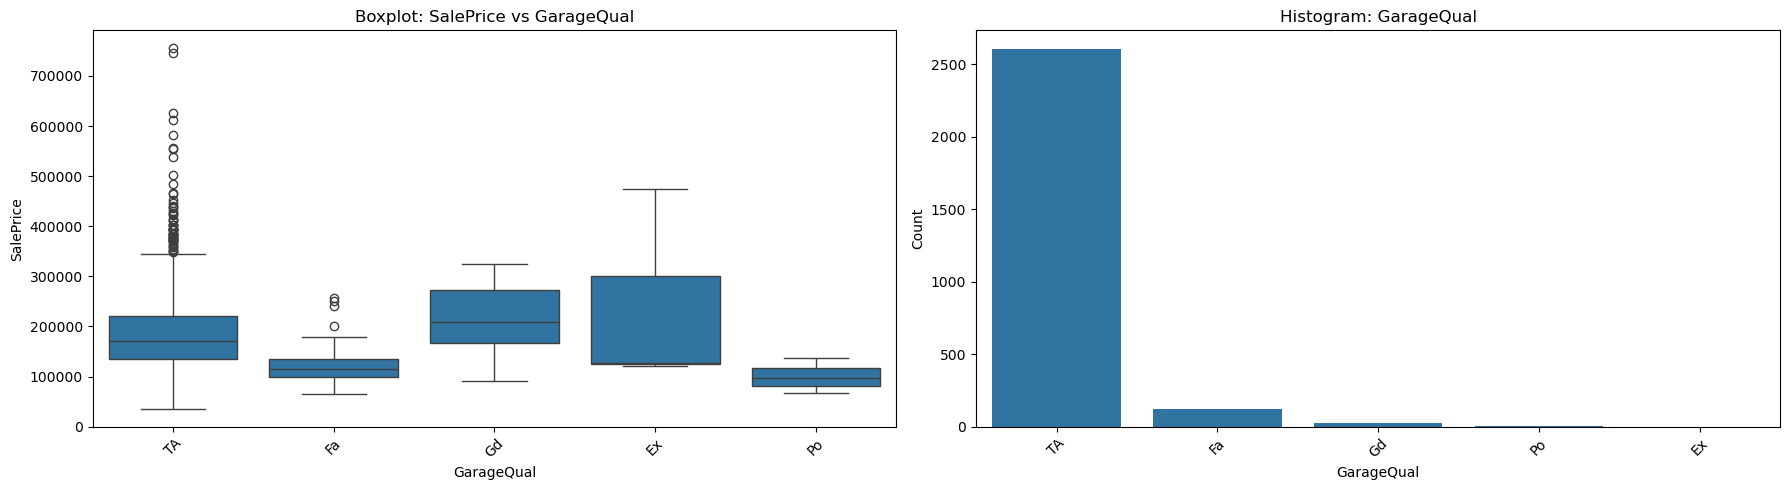

- Đã lưu: ./plots\SalePrice_vs_GarageCond.png


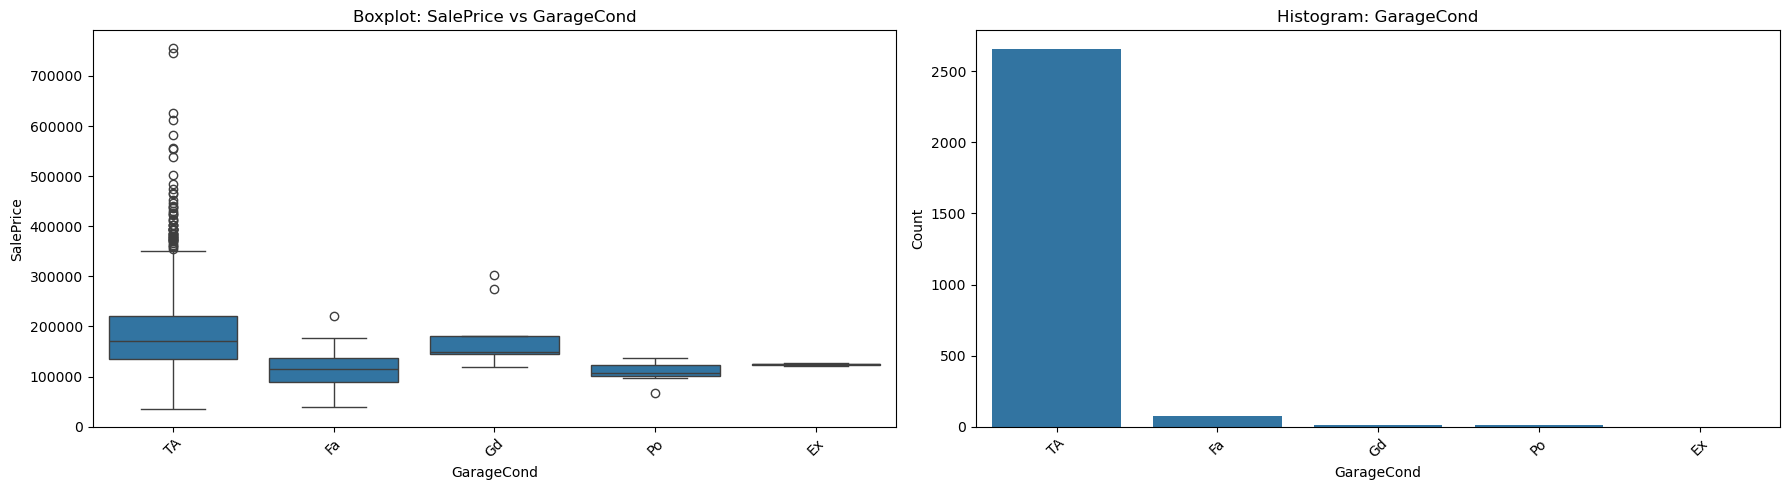

- Đã lưu: ./plots\SalePrice_vs_PavedDrive.png


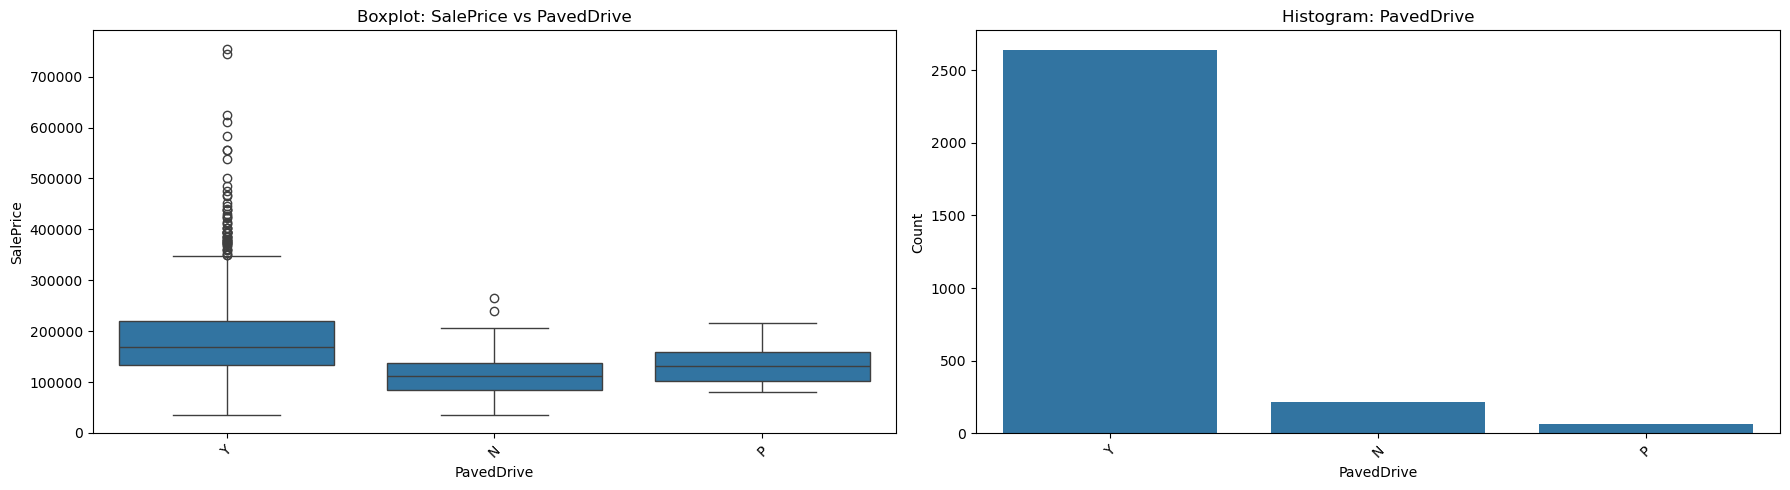

- Đã lưu: ./plots\SalePrice_vs_PoolQC.png


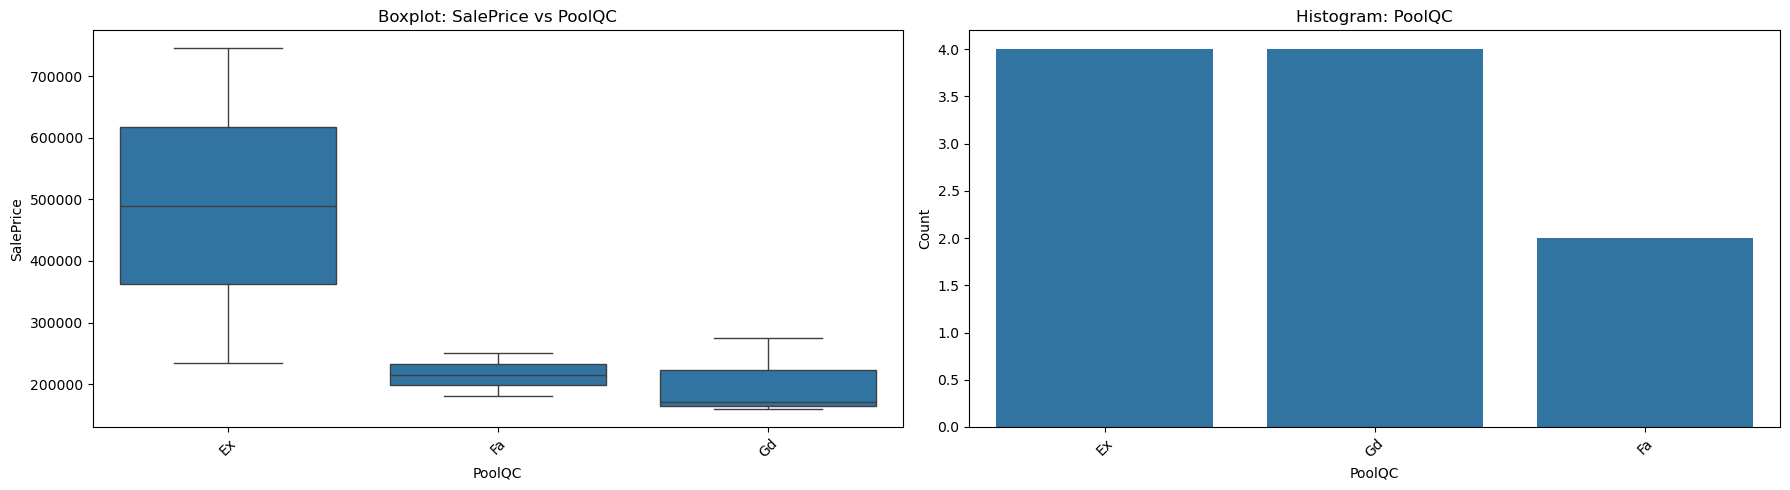

- Đã lưu: ./plots\SalePrice_vs_Fence.png


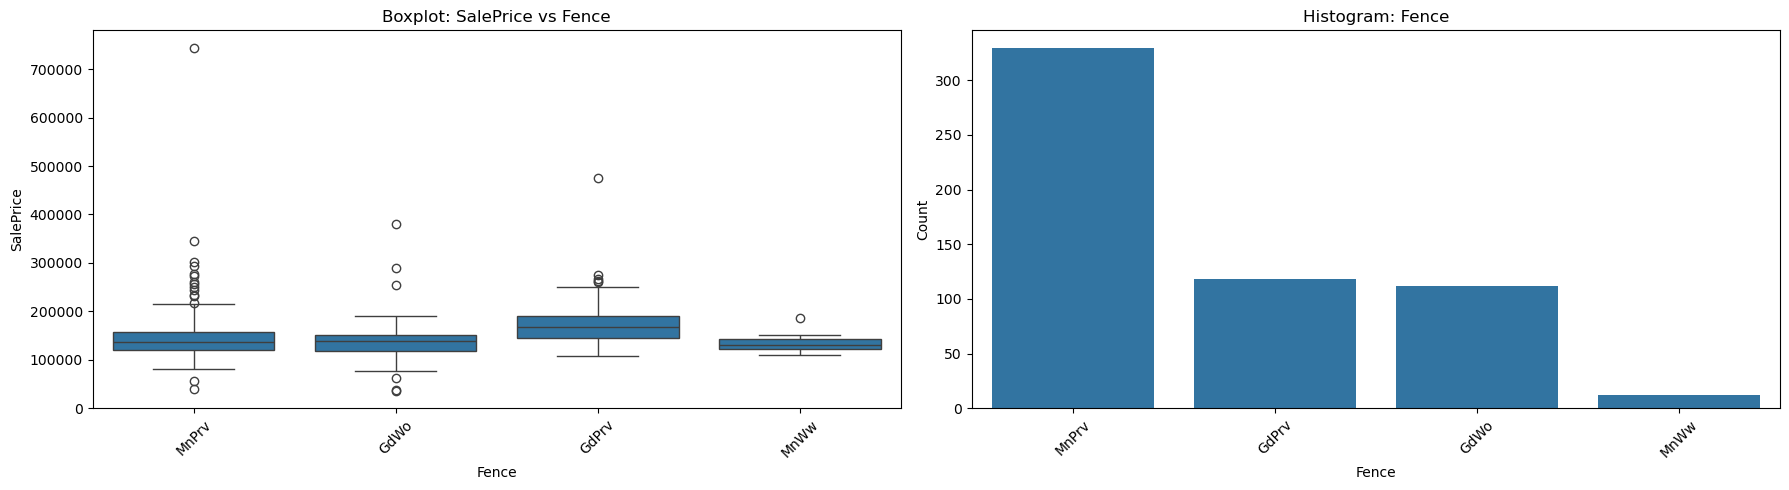

- Đã lưu: ./plots\SalePrice_vs_MiscFeature.png


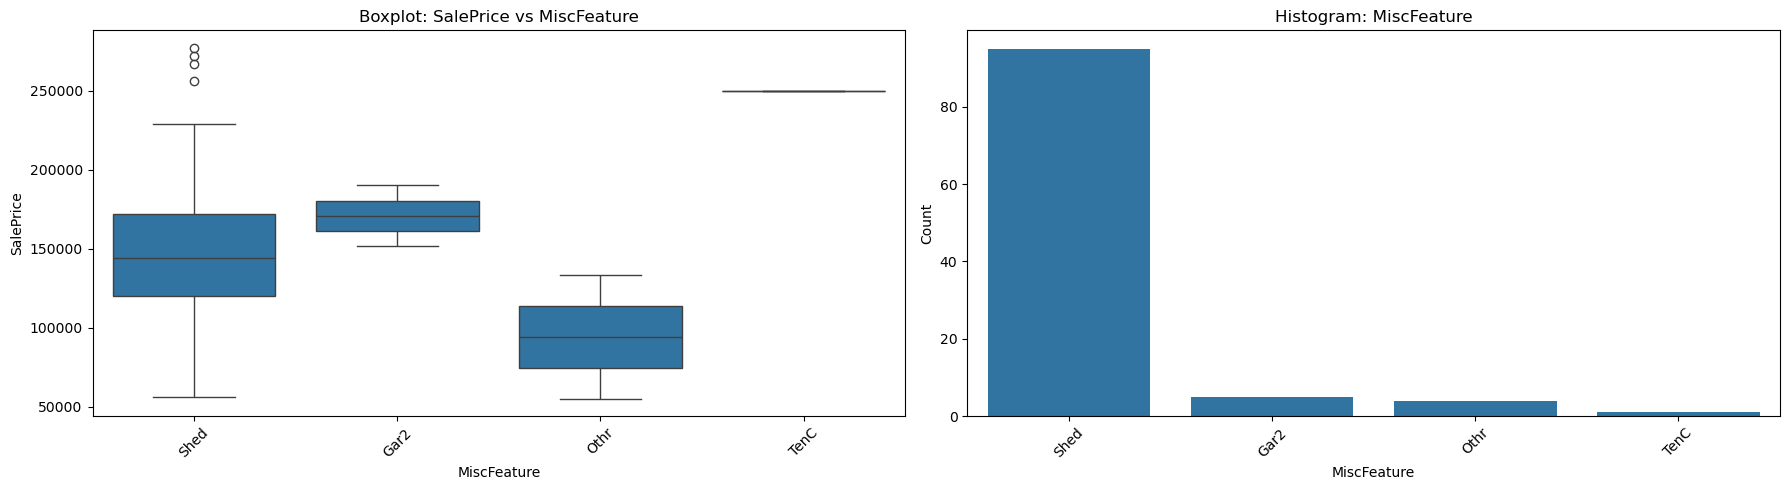

- Đã lưu: ./plots\SalePrice_vs_SaleType.png


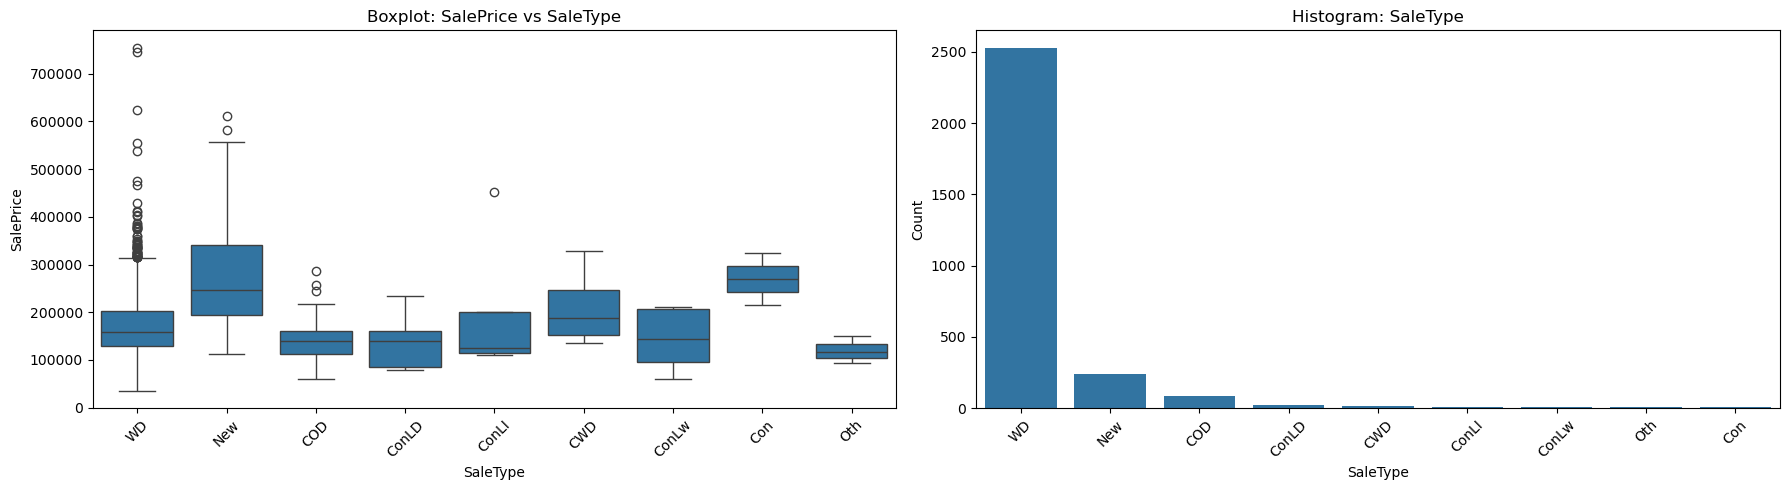

- Đã lưu: ./plots\SalePrice_vs_SaleCondition.png


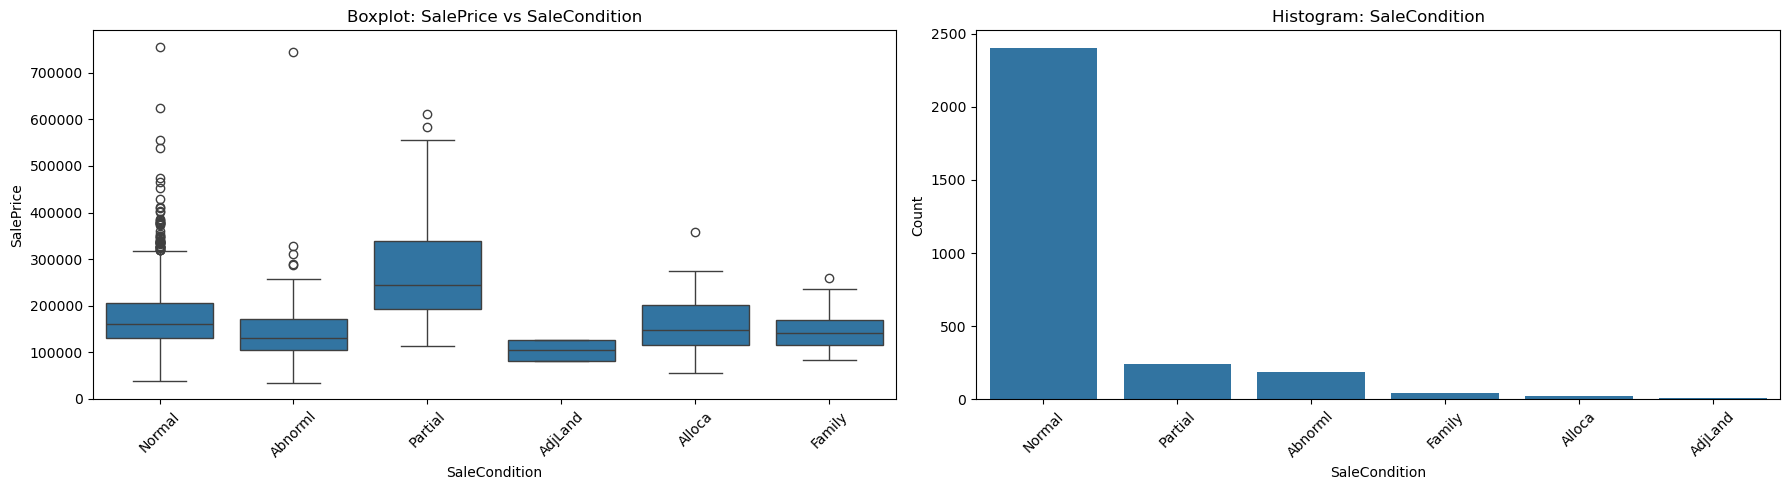

In [42]:
import os

save_dir = './plots'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

def plot_box_hist_density(df, categorical_columns=None, numeric_columns=None, max_categories=40, save_dir=None):
    """
    Vẽ boxplot, histogram và density plot cho các cột category và numeric.

    Parameters:
    - df: DataFrame chứa dữ liệu
    - categorical_columns: danh sách cột dạng category (nếu không truyền sẽ tự động chọn)
    - numeric_columns: danh sách cột dạng số (nếu không truyền sẽ tự động chọn)
    - max_categories: số lượng giá trị duy nhất tối đa để vẽ (tránh quá nhiều nhãn)
    """
    if categorical_columns is None:
        categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if numeric_columns is None:
        numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    for cat_col in categorical_columns:
        unique_vals = df[cat_col].dropna().unique()
        if len(unique_vals) > max_categories:
            print(f"Bỏ qua cột '{cat_col}' vì có quá nhiều giá trị ({len(unique_vals)})")
            continue

        for num_col in numeric_columns:
            plt.figure(figsize=(18, 5))

            # Boxplot (giữ nguyên)
            plt.subplot(1, 2, 1)
            sns.boxplot(data=df, x=cat_col, y=num_col)
            plt.title(f"Boxplot: {num_col} vs {cat_col}")
            plt.xticks(rotation=45)

            # Histogram theo value count
            plt.subplot(1, 2, 2)
            value_counts = df[cat_col].value_counts()
            sns.barplot(x=value_counts.index, y=value_counts.values)
            plt.title(f"Histogram: {cat_col}")
            plt.xlabel(cat_col)
            plt.ylabel("Count")
            plt.xticks(rotation=45)

            plt.tight_layout()
            
            if save_dir:
                file_name = f"{num_col}_vs_{cat_col}.png"
                file_path = os.path.join(save_dir, file_name)
                plt.savefig(file_path, dpi=300, bbox_inches='tight')
                print(f"- Đã lưu: {file_path}")
                
            plt.show()
plot_box_hist_density(df, categorical_columns=categorical_cols, numeric_columns=['SalePrice'], save_dir=save_dir)

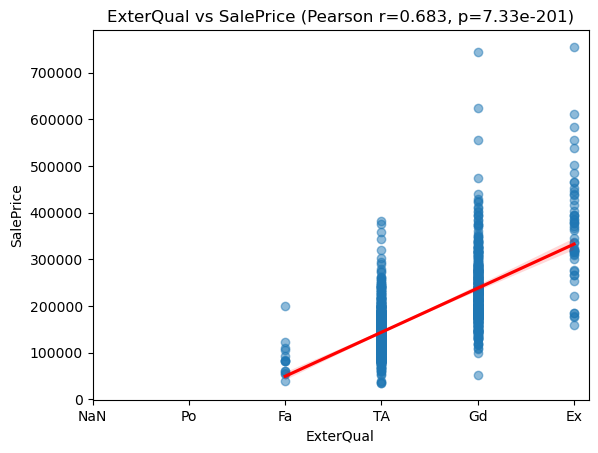

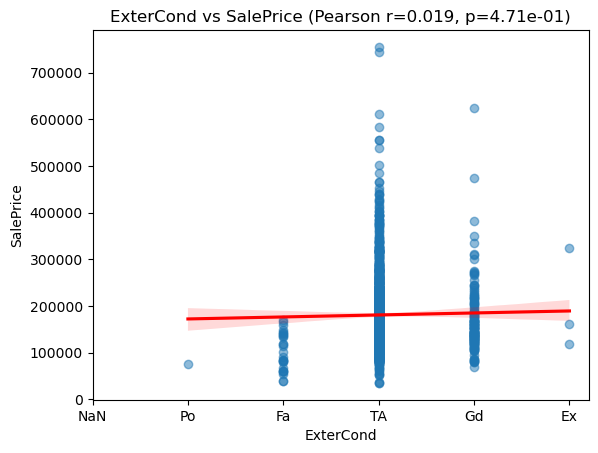

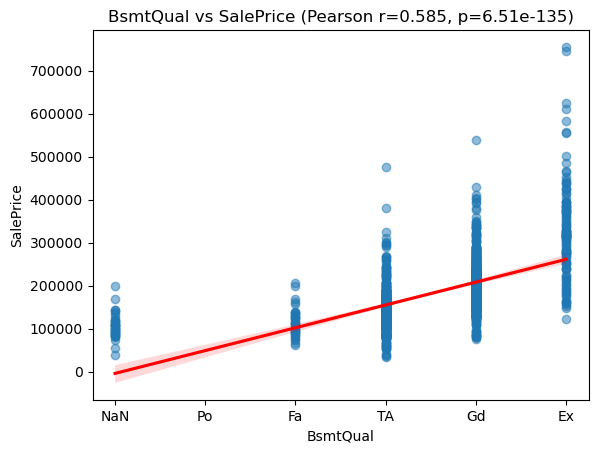

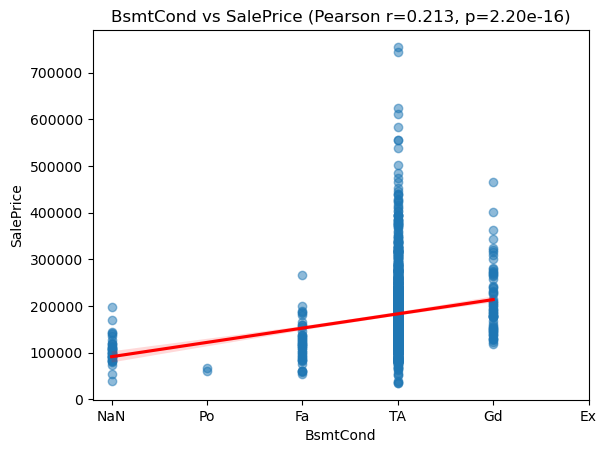

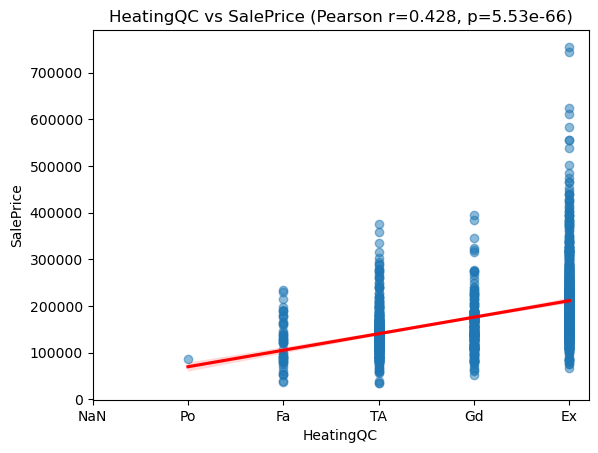

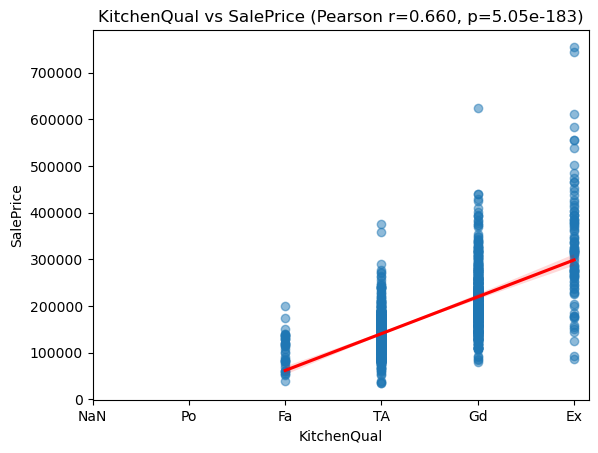

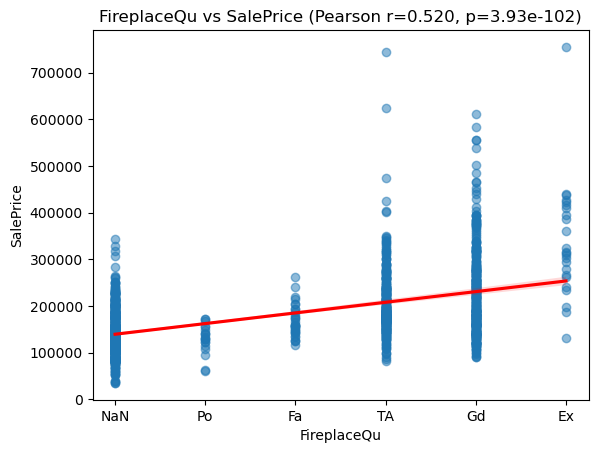

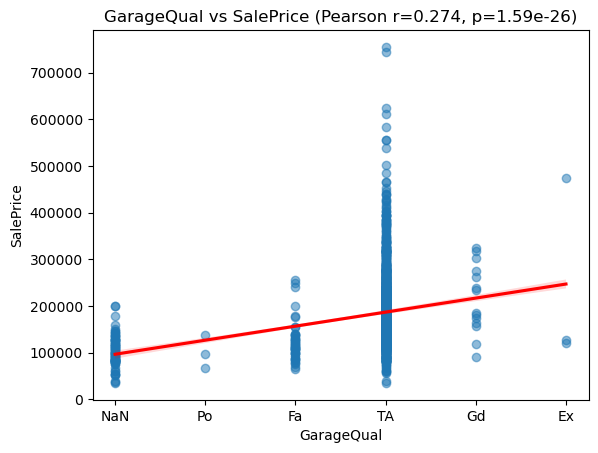

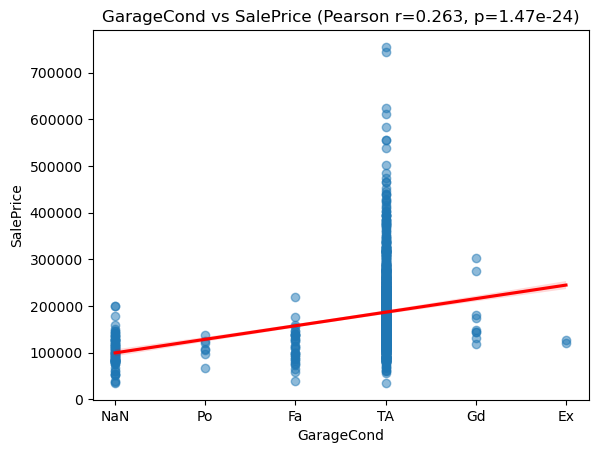

In [47]:
qual_map_standard = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NaN':0}
qual_cols_standard = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                      'KitchenQual','FireplaceQu','GarageQual','GarageCond']

# Áp mapping chỉ trên df_train để vẽ (giữ df nguyên nếu cần cho bước sau)
for col in qual_cols_standard:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna('NaN').replace(qual_map_standard).astype(float)

# Vẽ regplot an toàn (loại bỏ NaN), in Pearson r
for col in qual_cols_standard:
    if col in df_train.columns:
        x, y = col, 'SalePrice'
        plot_df = df_train[[x, y]].dropna()

        from scipy import stats
        if len(plot_df) > 1:
            r, p = stats.pearsonr(plot_df[x], plot_df[y])
        else:
            r, p = (np.nan, np.nan)

        sns.regplot(x=x, y=y, data=plot_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        plt.title(f'{x} vs {y} (Pearson r={r:.3f}, p={p:.2e})')
        plt.xlabel(x)
        plt.xticks([0, 1, 2, 3, 4, 5], ['NaN', 'Po', 'Fa', 'TA', 'Gd', 'Ex'])
        plt.ylabel(y)
        plt.show()

### Numeric columns

- Đã lưu: ./plots\MSSubClass.png


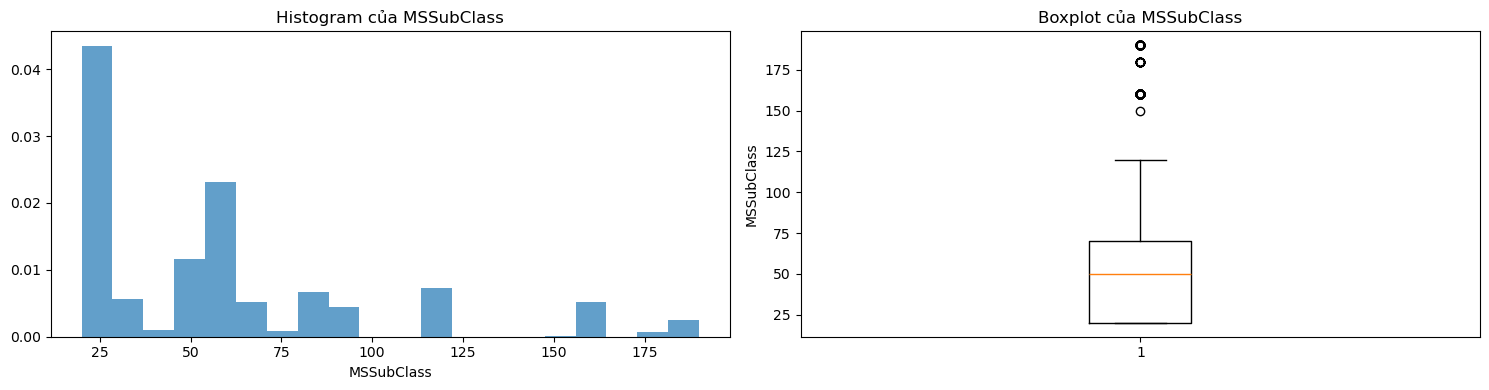

- Đã lưu: ./plots\LotFrontage.png


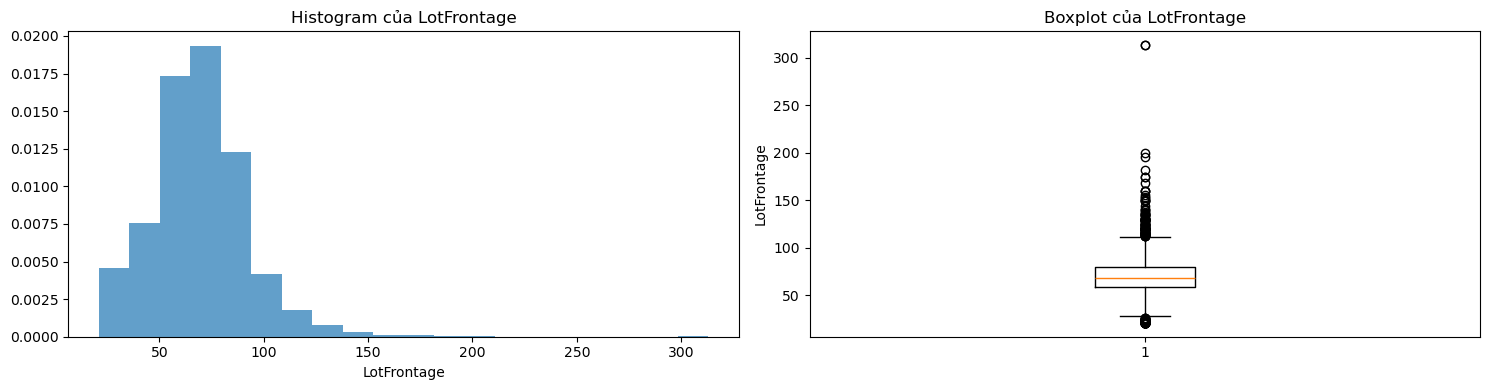

- Đã lưu: ./plots\LotArea.png


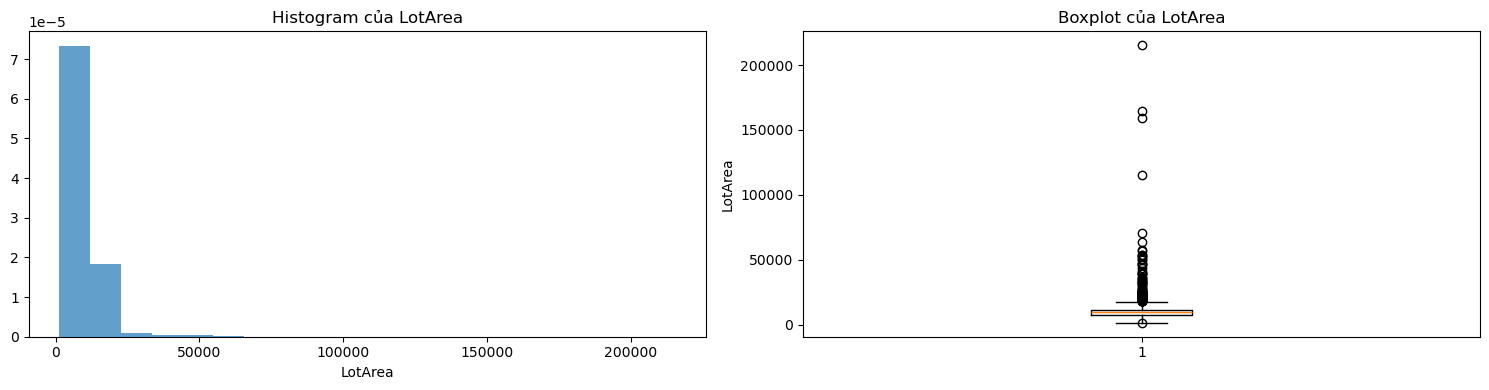

- Đã lưu: ./plots\OverallQual.png


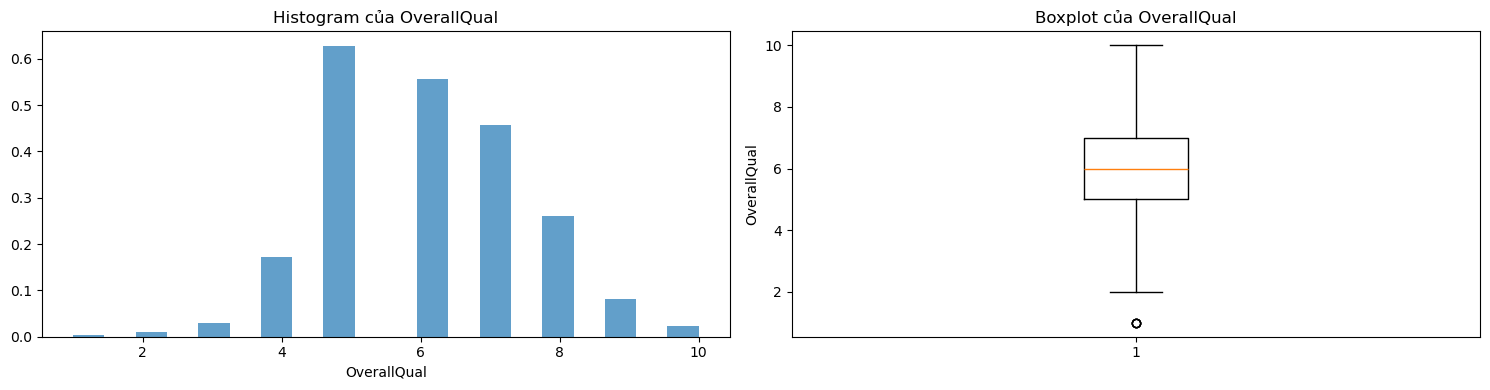

- Đã lưu: ./plots\OverallCond.png


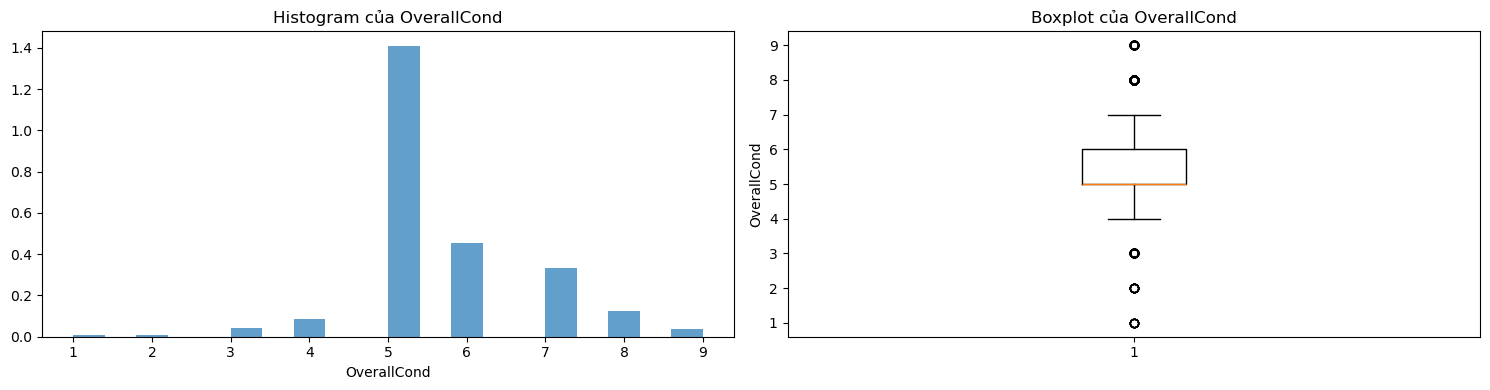

- Đã lưu: ./plots\YearBuilt.png


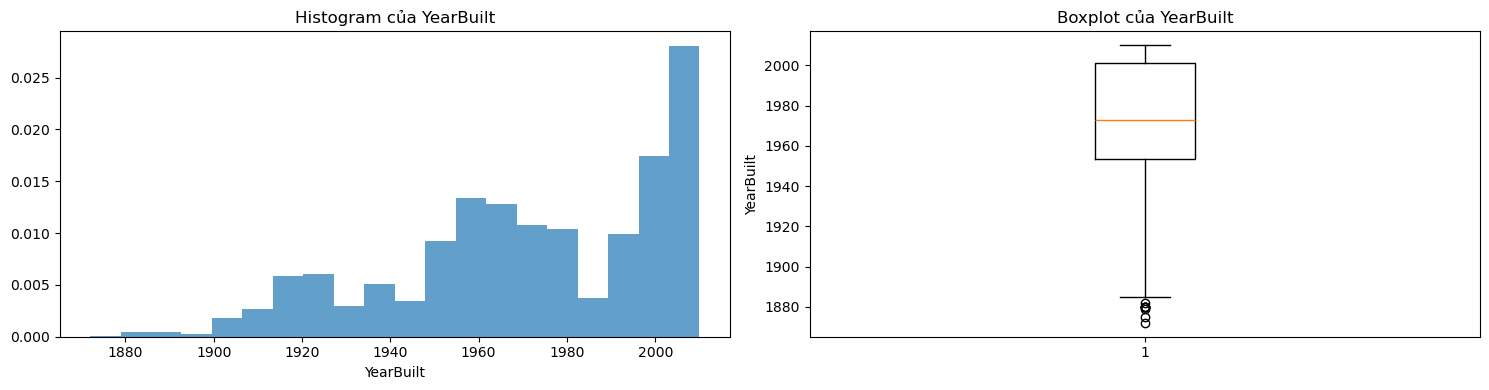

- Đã lưu: ./plots\YearRemodAdd.png


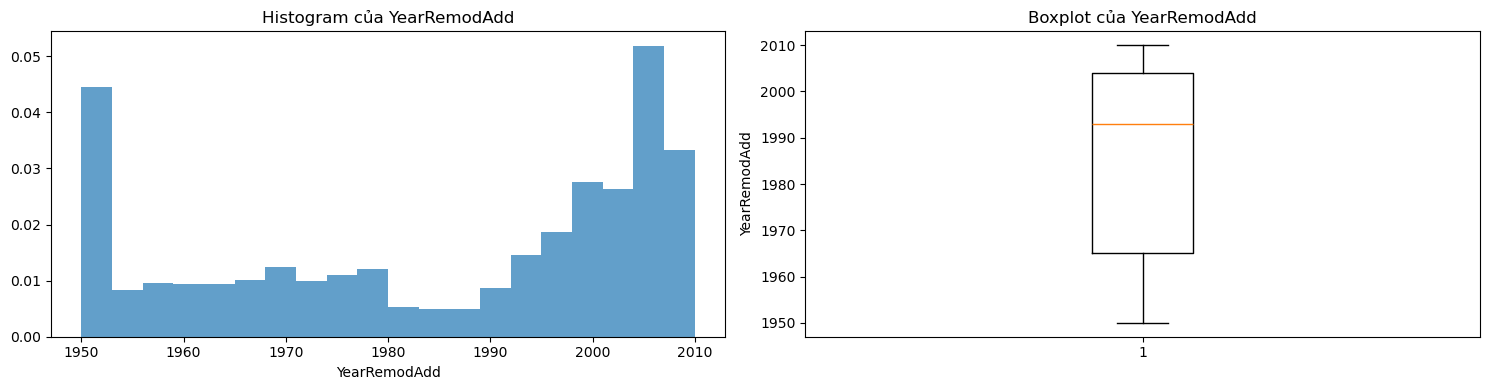

- Đã lưu: ./plots\MasVnrArea.png


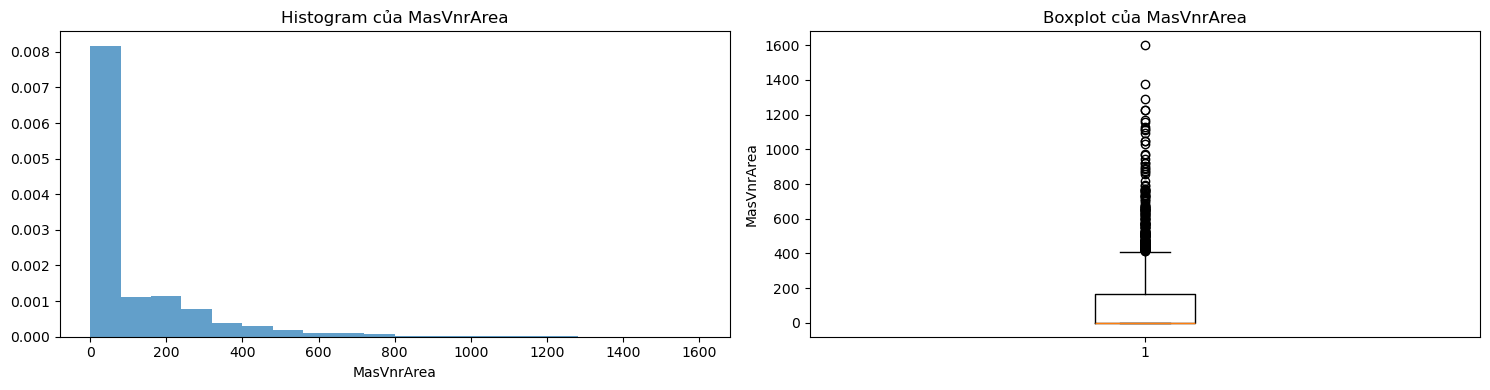

- Đã lưu: ./plots\BsmtFinSF1.png


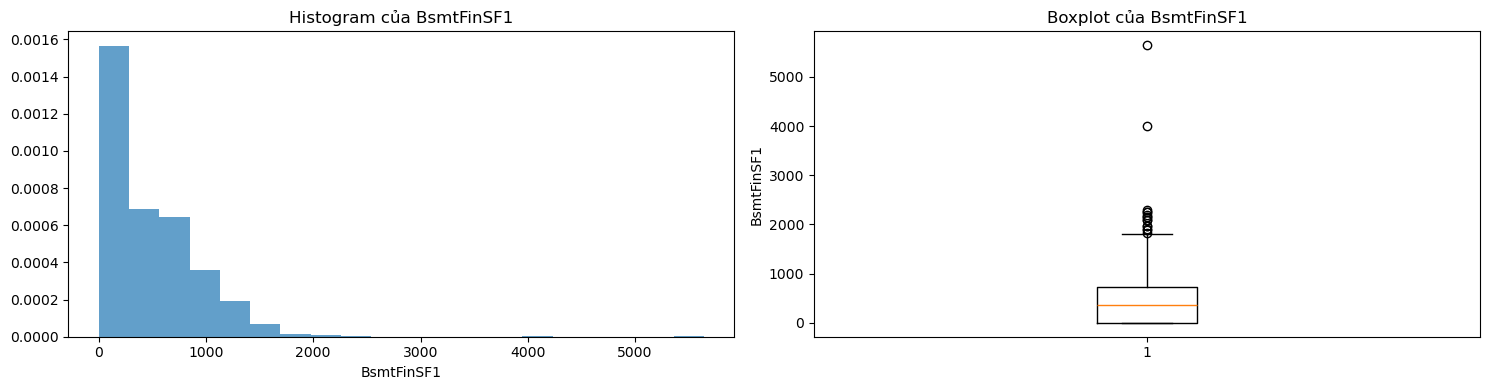

- Đã lưu: ./plots\BsmtFinSF2.png


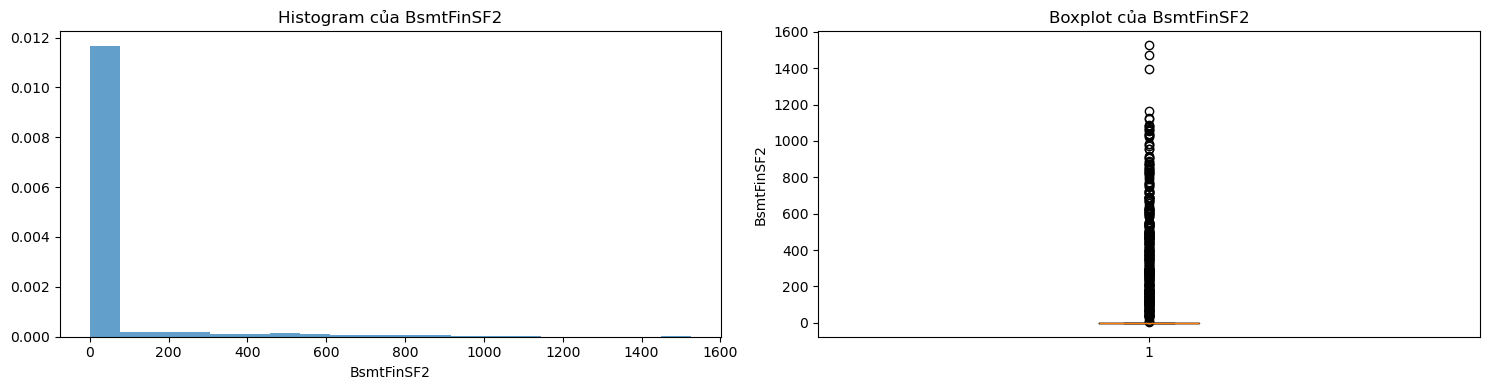

- Đã lưu: ./plots\BsmtUnfSF.png


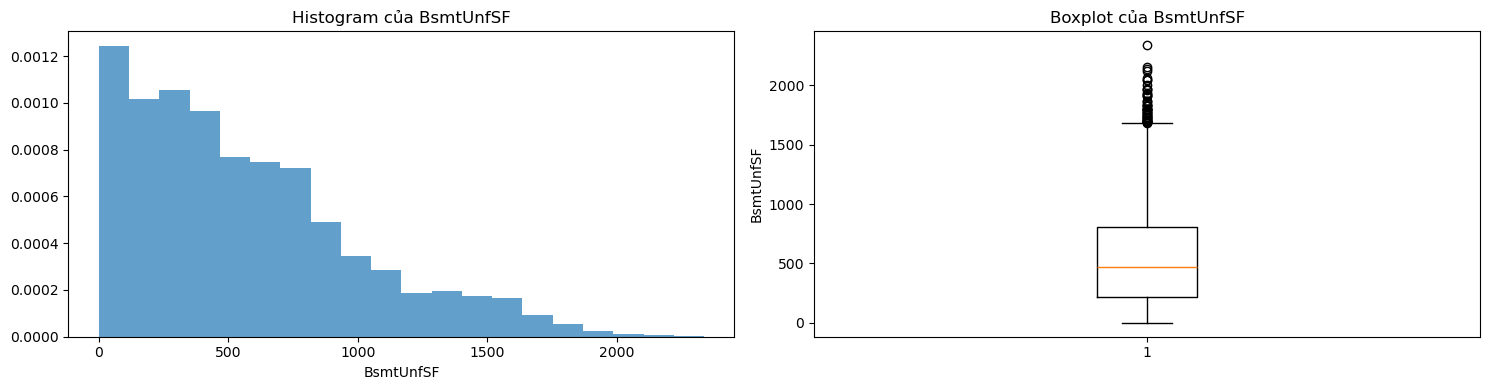

- Đã lưu: ./plots\TotalBsmtSF.png


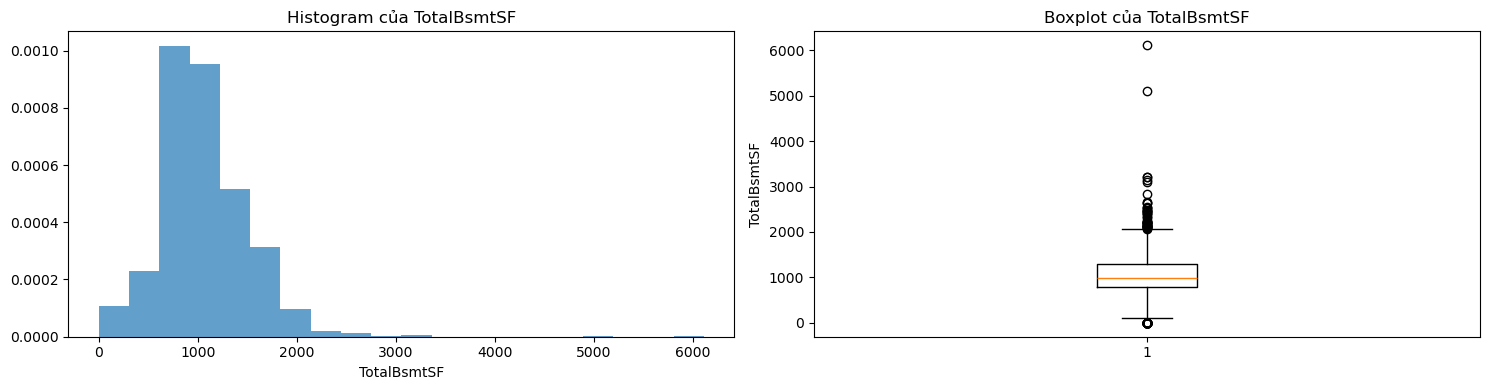

- Đã lưu: ./plots\1stFlrSF.png


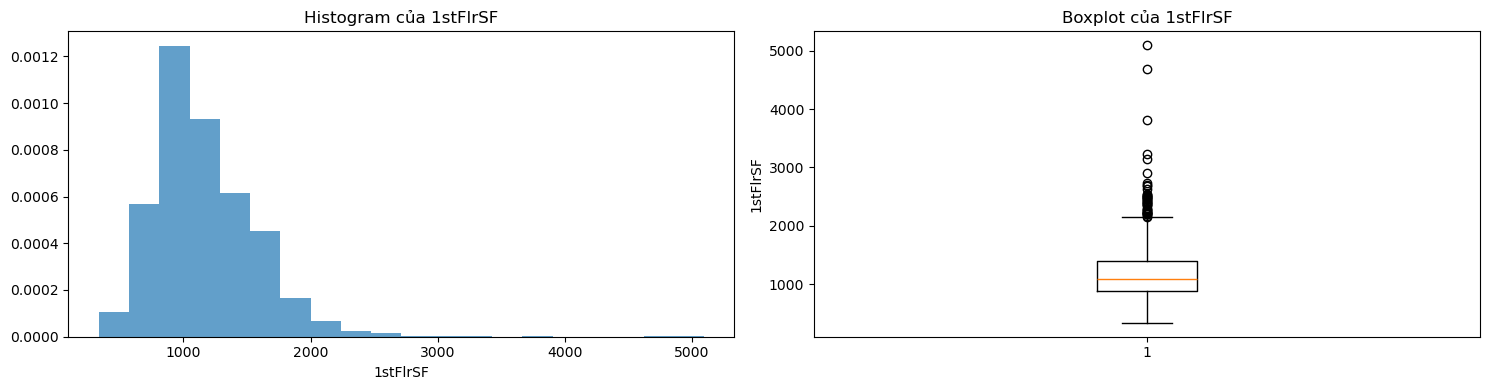

- Đã lưu: ./plots\2ndFlrSF.png


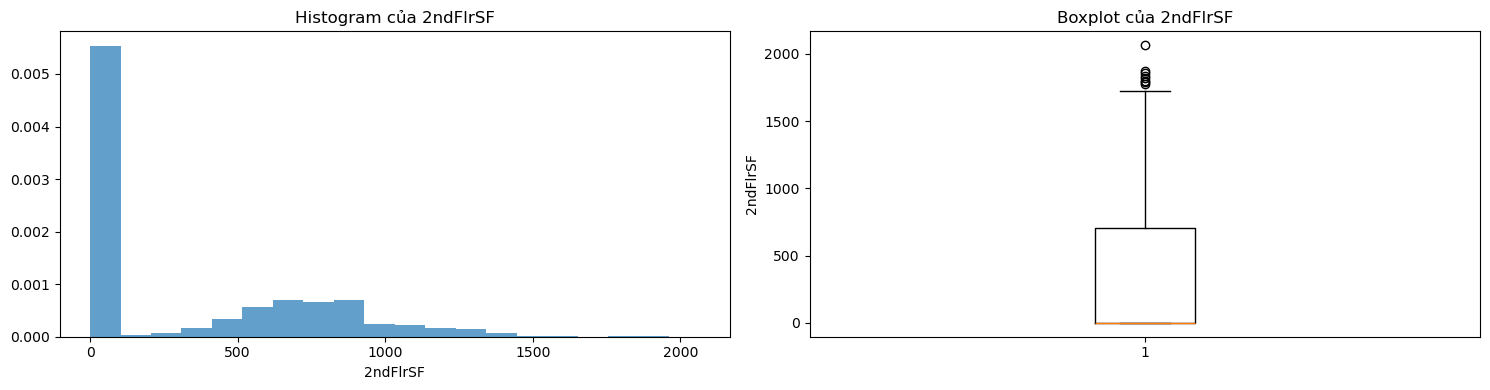

- Đã lưu: ./plots\LowQualFinSF.png


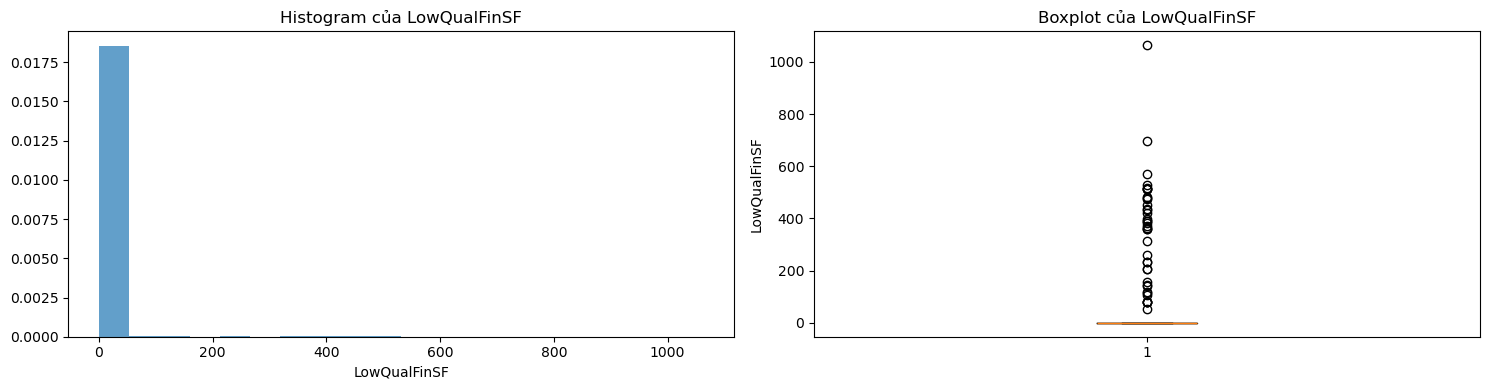

- Đã lưu: ./plots\GrLivArea.png


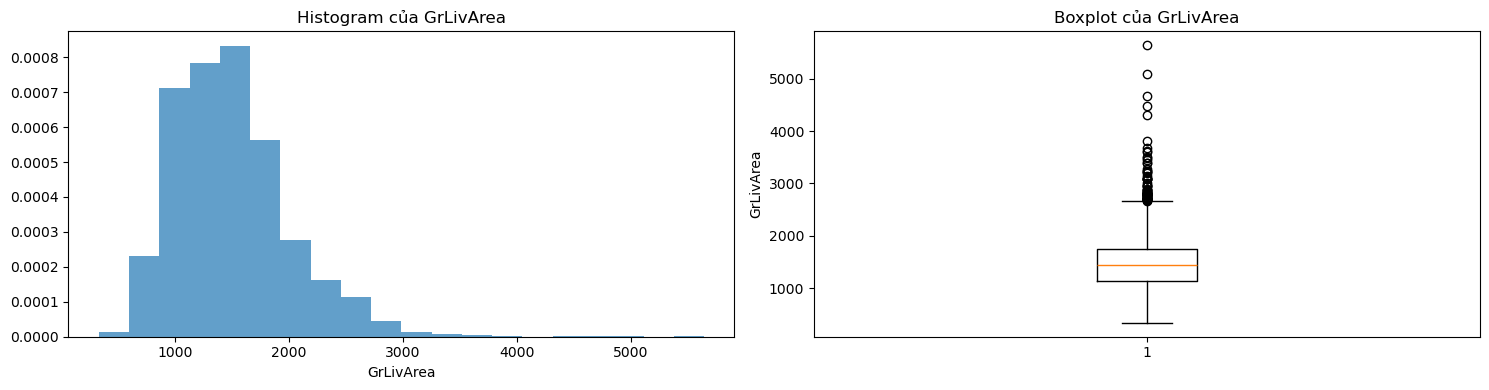

- Đã lưu: ./plots\BsmtFullBath.png


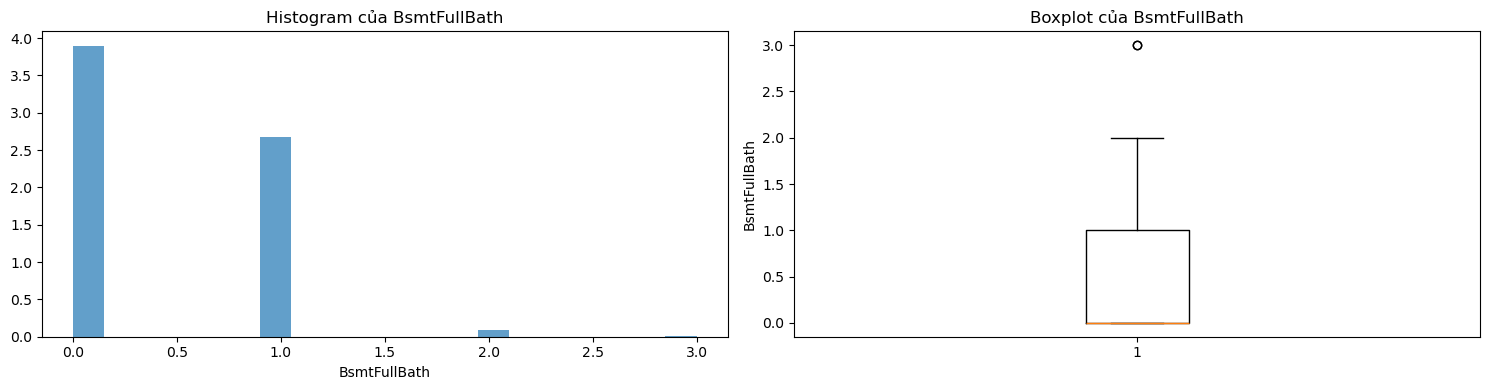

- Đã lưu: ./plots\BsmtHalfBath.png


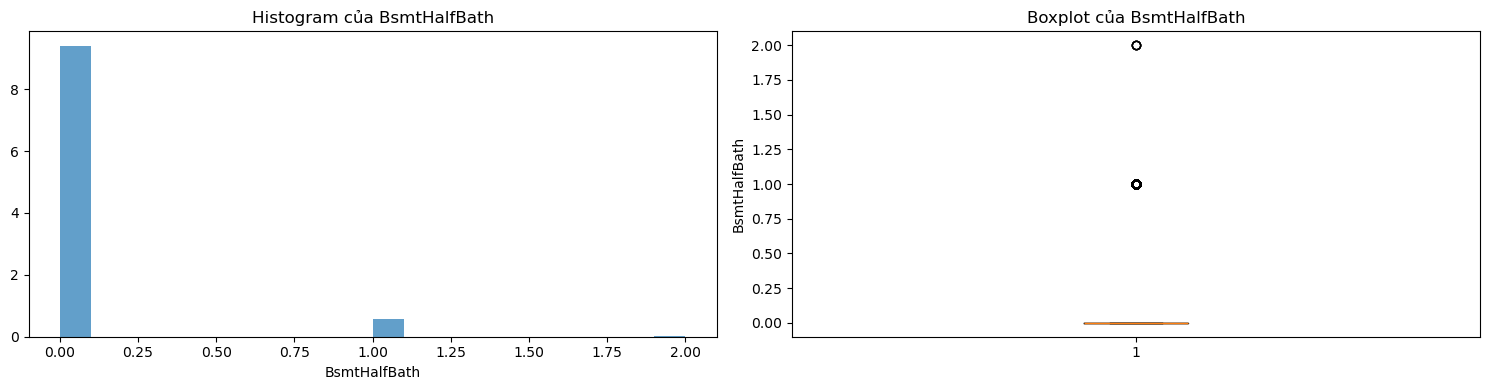

- Đã lưu: ./plots\FullBath.png


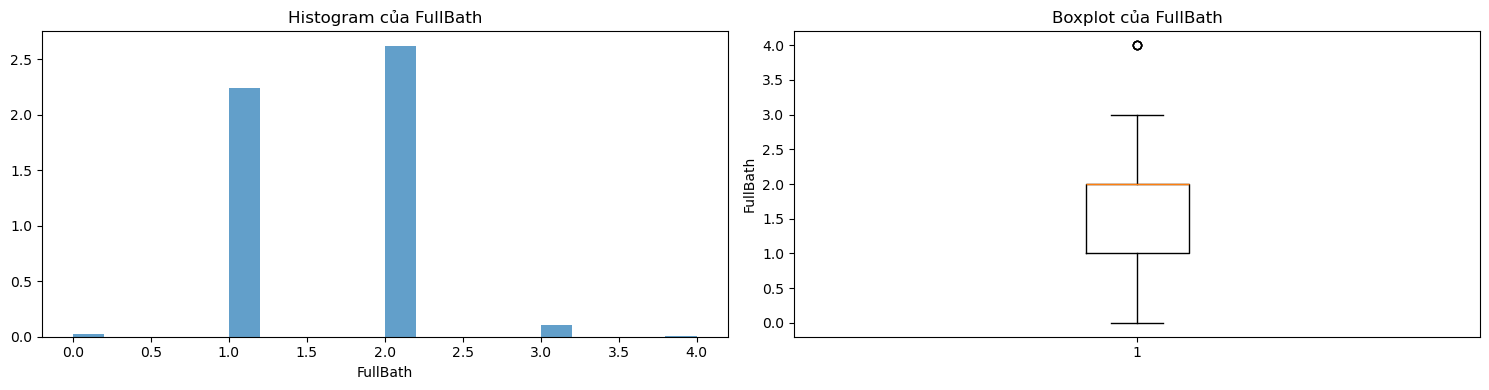

- Đã lưu: ./plots\HalfBath.png


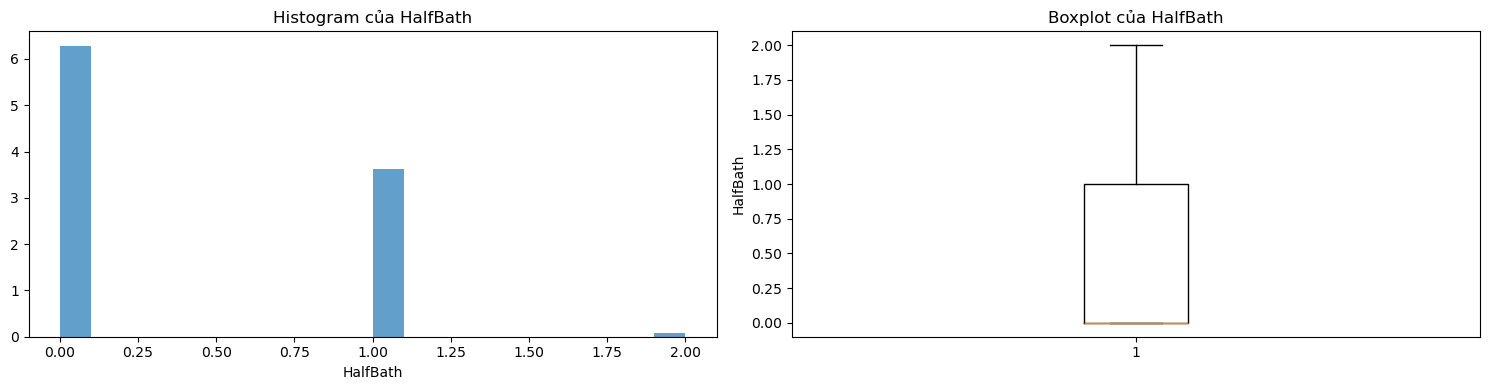

- Đã lưu: ./plots\BedroomAbvGr.png


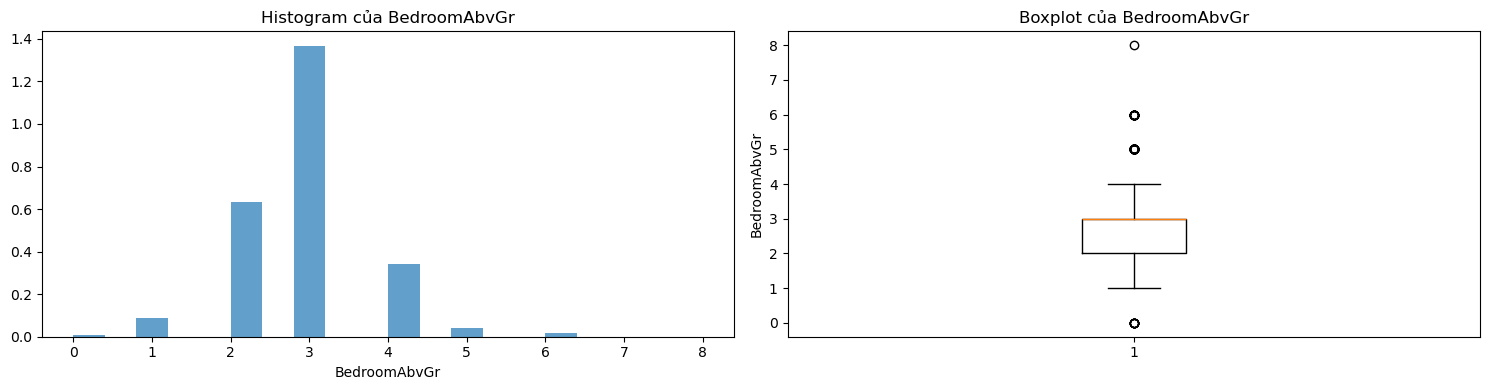

- Đã lưu: ./plots\KitchenAbvGr.png


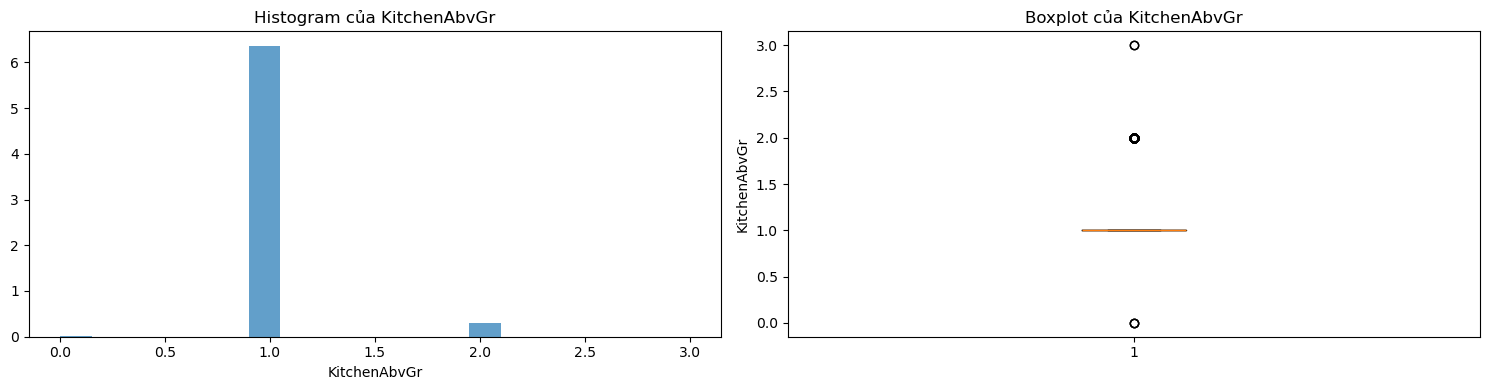

- Đã lưu: ./plots\TotRmsAbvGrd.png


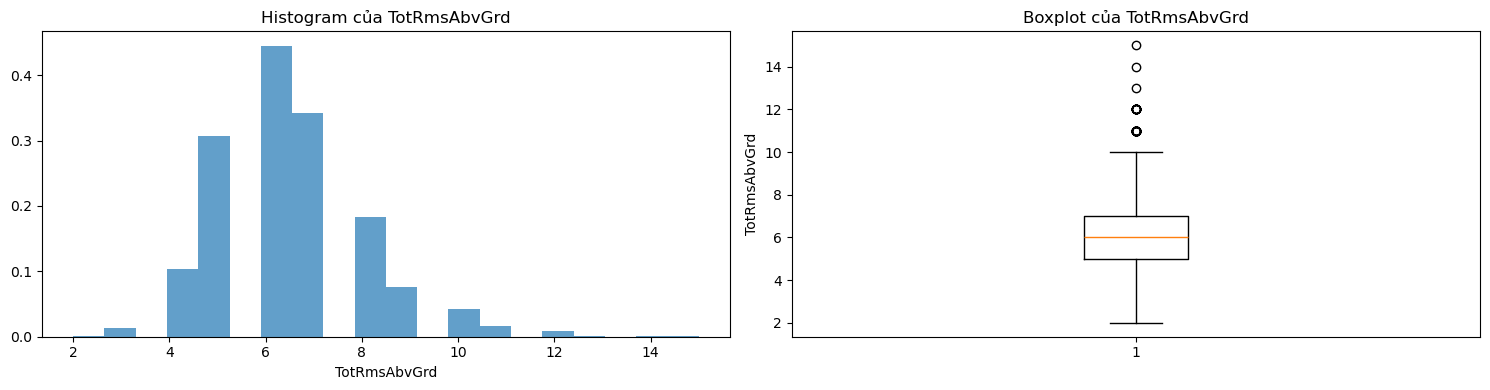

- Đã lưu: ./plots\Fireplaces.png


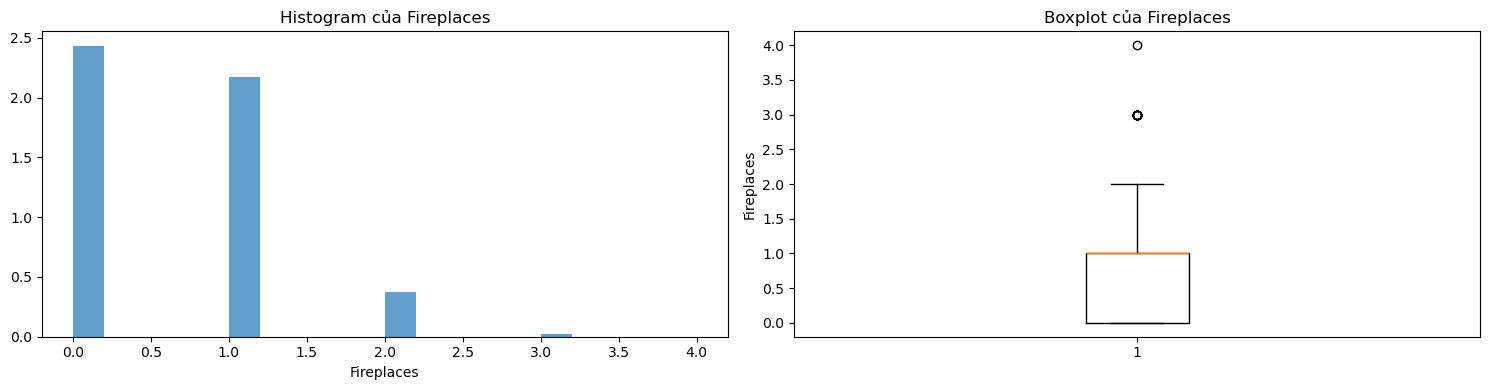

- Đã lưu: ./plots\GarageYrBlt.png


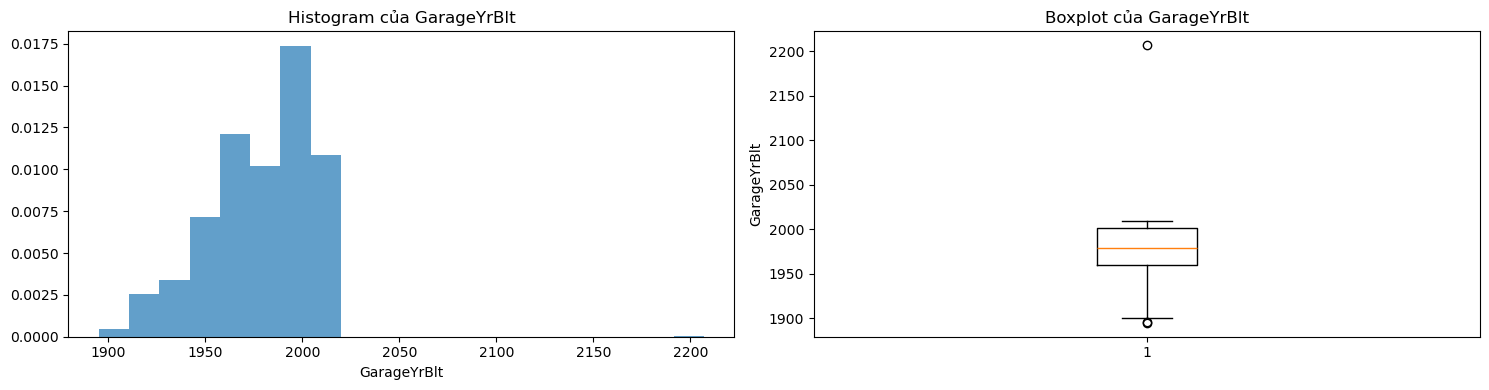

- Đã lưu: ./plots\GarageCars.png


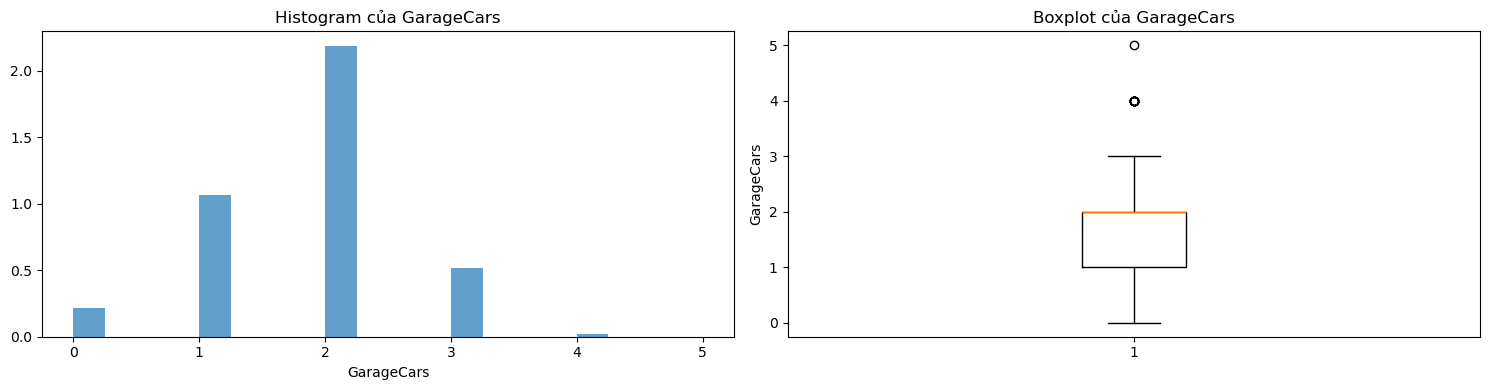

- Đã lưu: ./plots\GarageArea.png


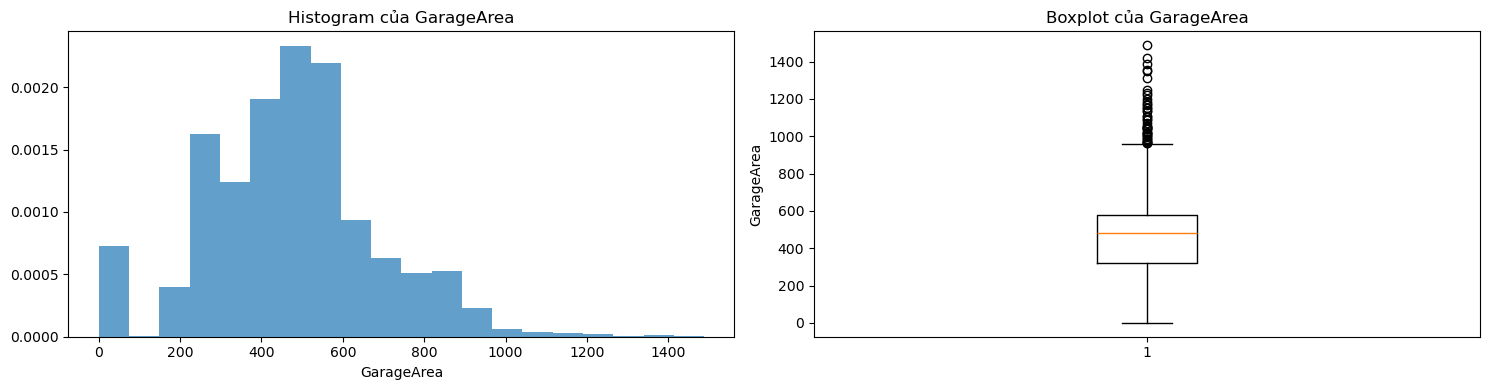

- Đã lưu: ./plots\WoodDeckSF.png


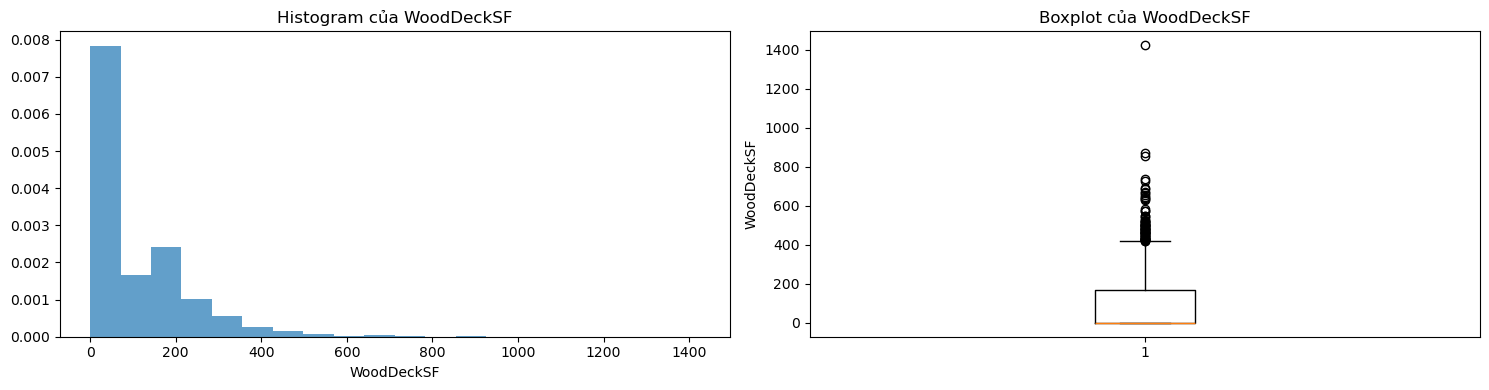

- Đã lưu: ./plots\OpenPorchSF.png


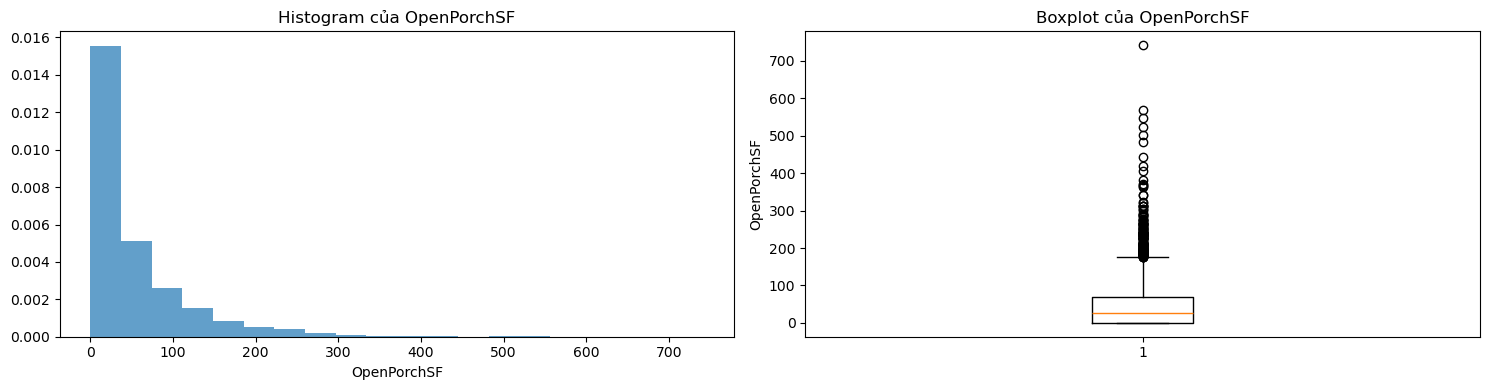

- Đã lưu: ./plots\EnclosedPorch.png


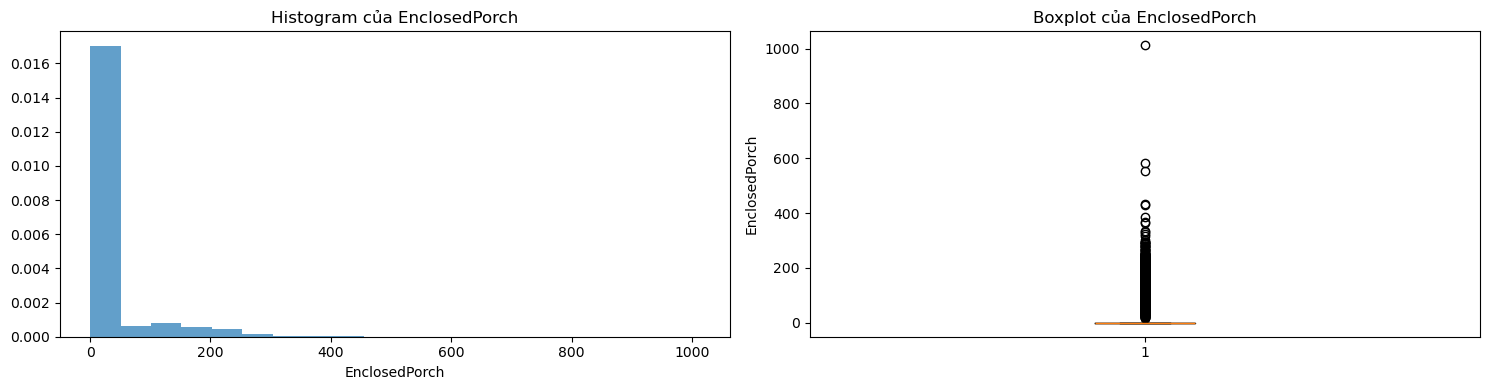

- Đã lưu: ./plots\3SsnPorch.png


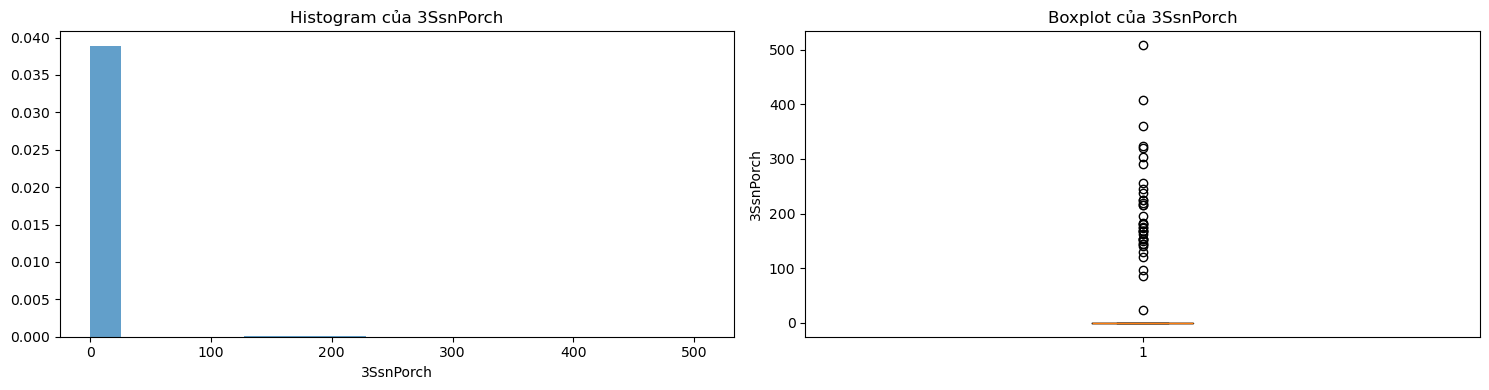

- Đã lưu: ./plots\ScreenPorch.png


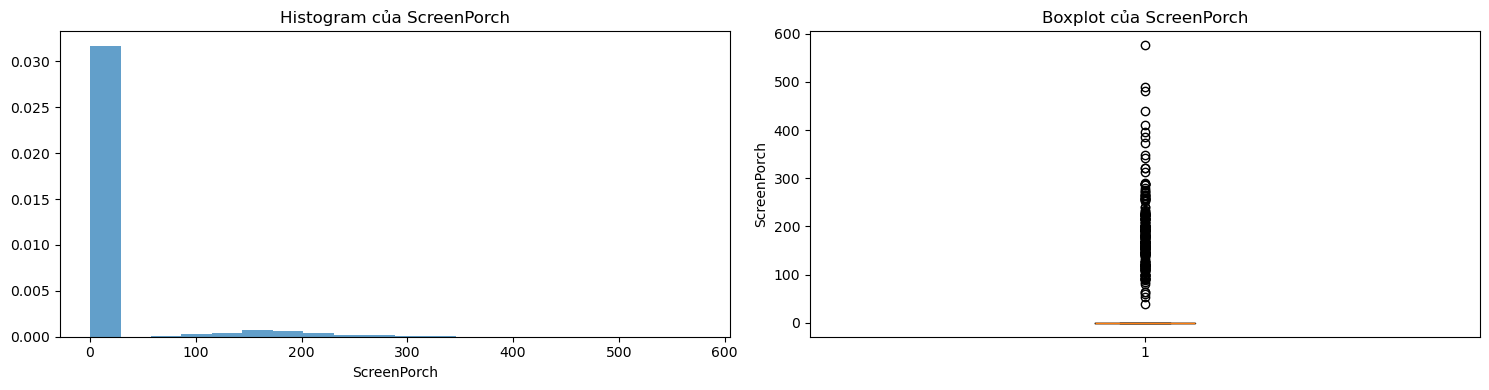

- Đã lưu: ./plots\PoolArea.png


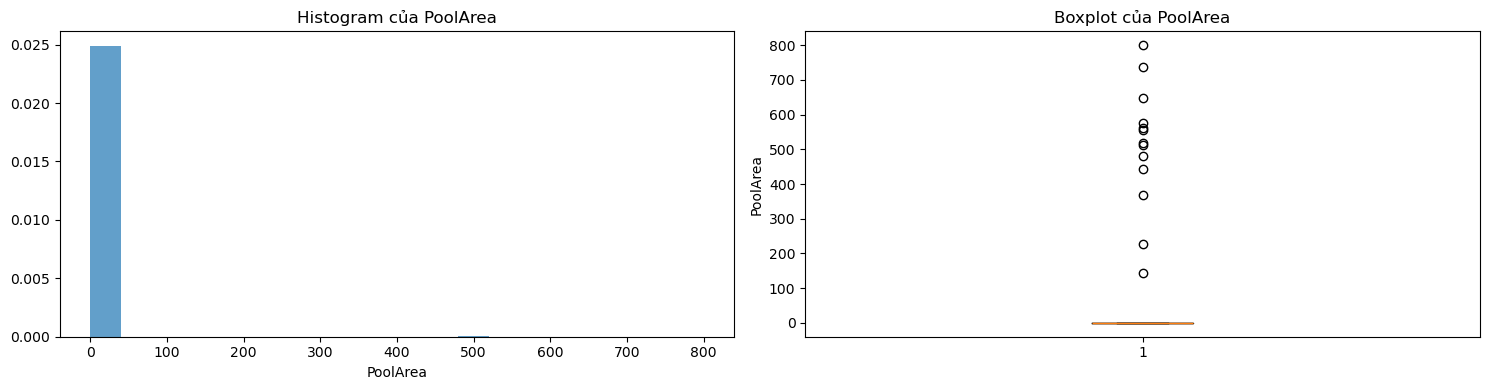

- Đã lưu: ./plots\MiscVal.png


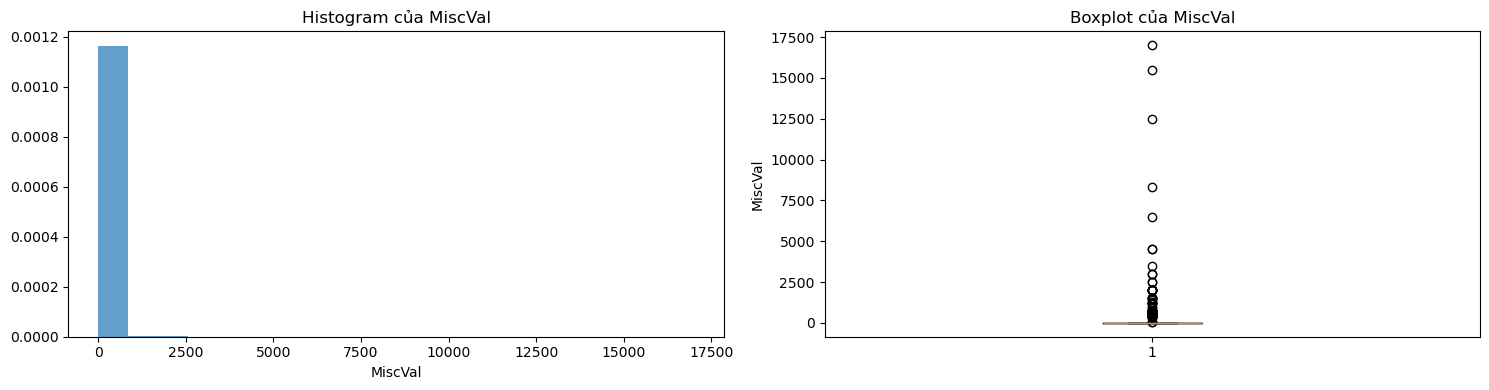

- Đã lưu: ./plots\MoSold.png


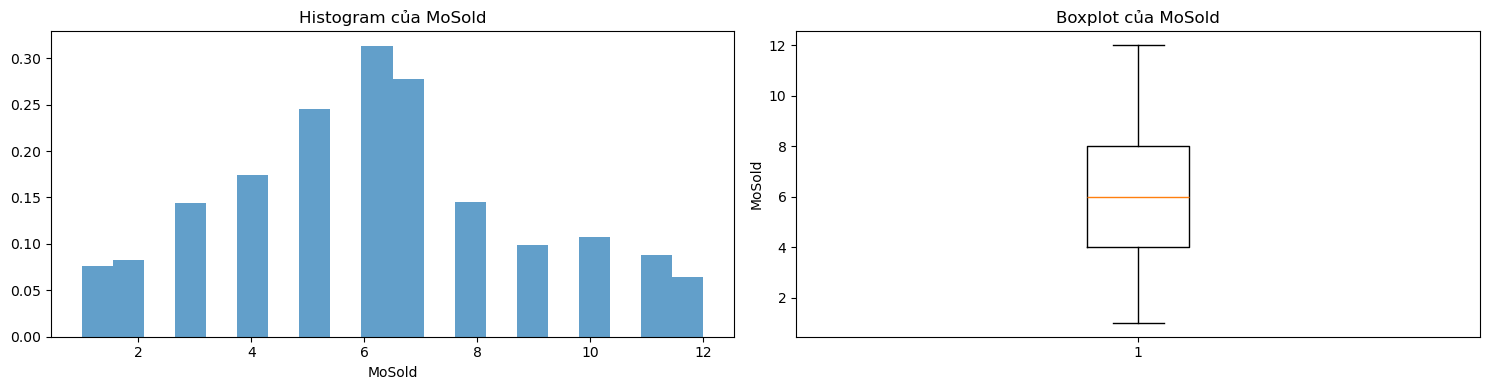

- Đã lưu: ./plots\YrSold.png


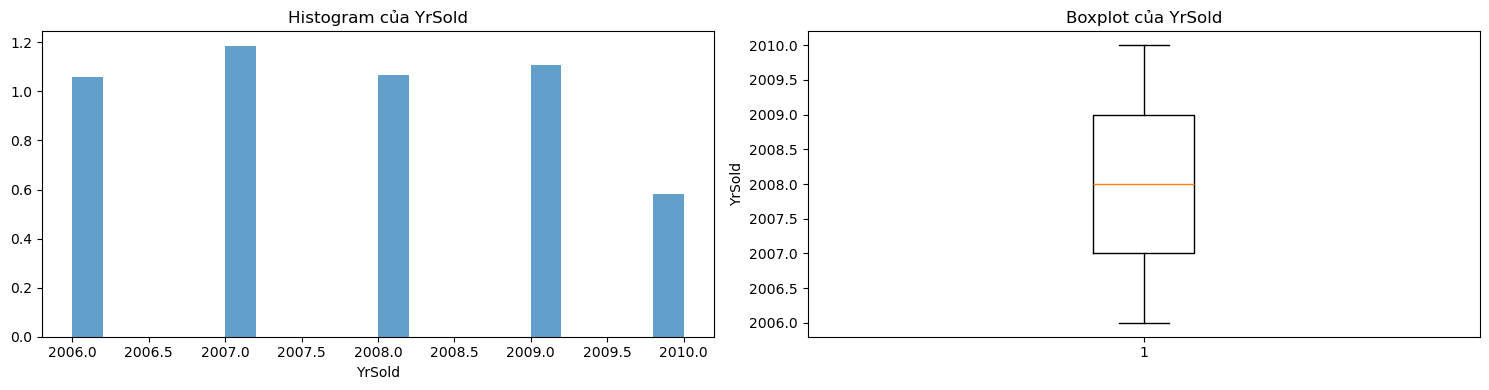

- Đã lưu: ./plots\SalePrice.png


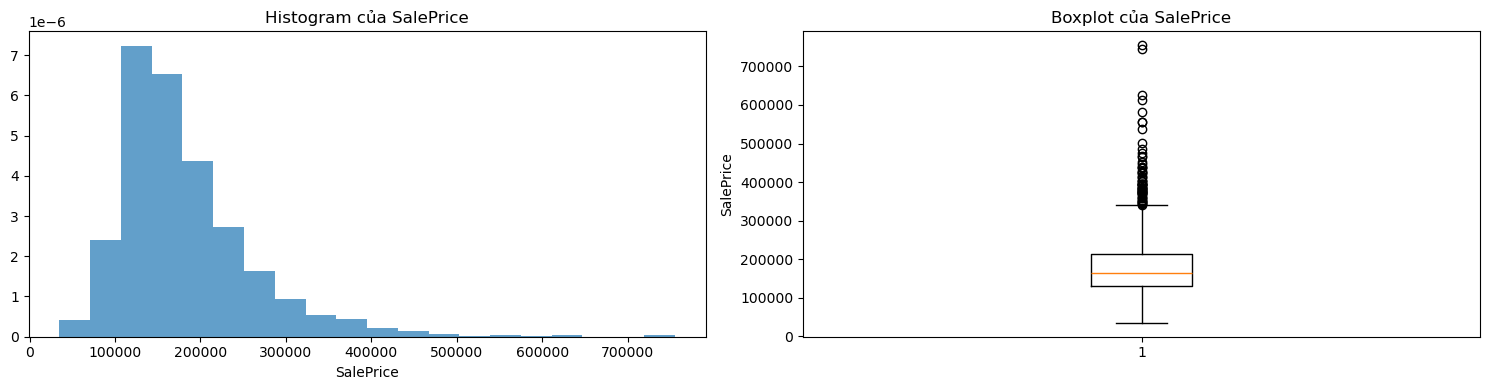

In [48]:
def numeric_visualization(df, numeric_columns=None, save_dir=None):
    """
    Trực quan hóa các cột số với 2 biểu đồ: Histogram, Boxplot
    """
    if numeric_columns is None:
        numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    for col in numeric_columns:
        data = df[col].dropna()
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))
        
        # 1. Histogram đơn giản
        axes[0].hist(data, bins=20, alpha=0.7, density=True)
        axes[0].set_title(f'Histogram của {col}')
        axes[0].set_xlabel(col)
        
        # 2. Boxplot đơn giản
        axes[1].boxplot(data)
        axes[1].set_title(f'Boxplot của {col}')
        axes[1].set_ylabel(col)
        
        plt.tight_layout()
        
        if save_dir:
            file_name = f"{col}.png"
            file_path = os.path.join(save_dir, file_name)
            plt.savefig(file_path, dpi=300, bbox_inches='tight')
            print(f"- Đã lưu: {file_path}")
                
        plt.show()

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_visualization(df, numeric_columns=numeric_cols, save_dir=save_dir)

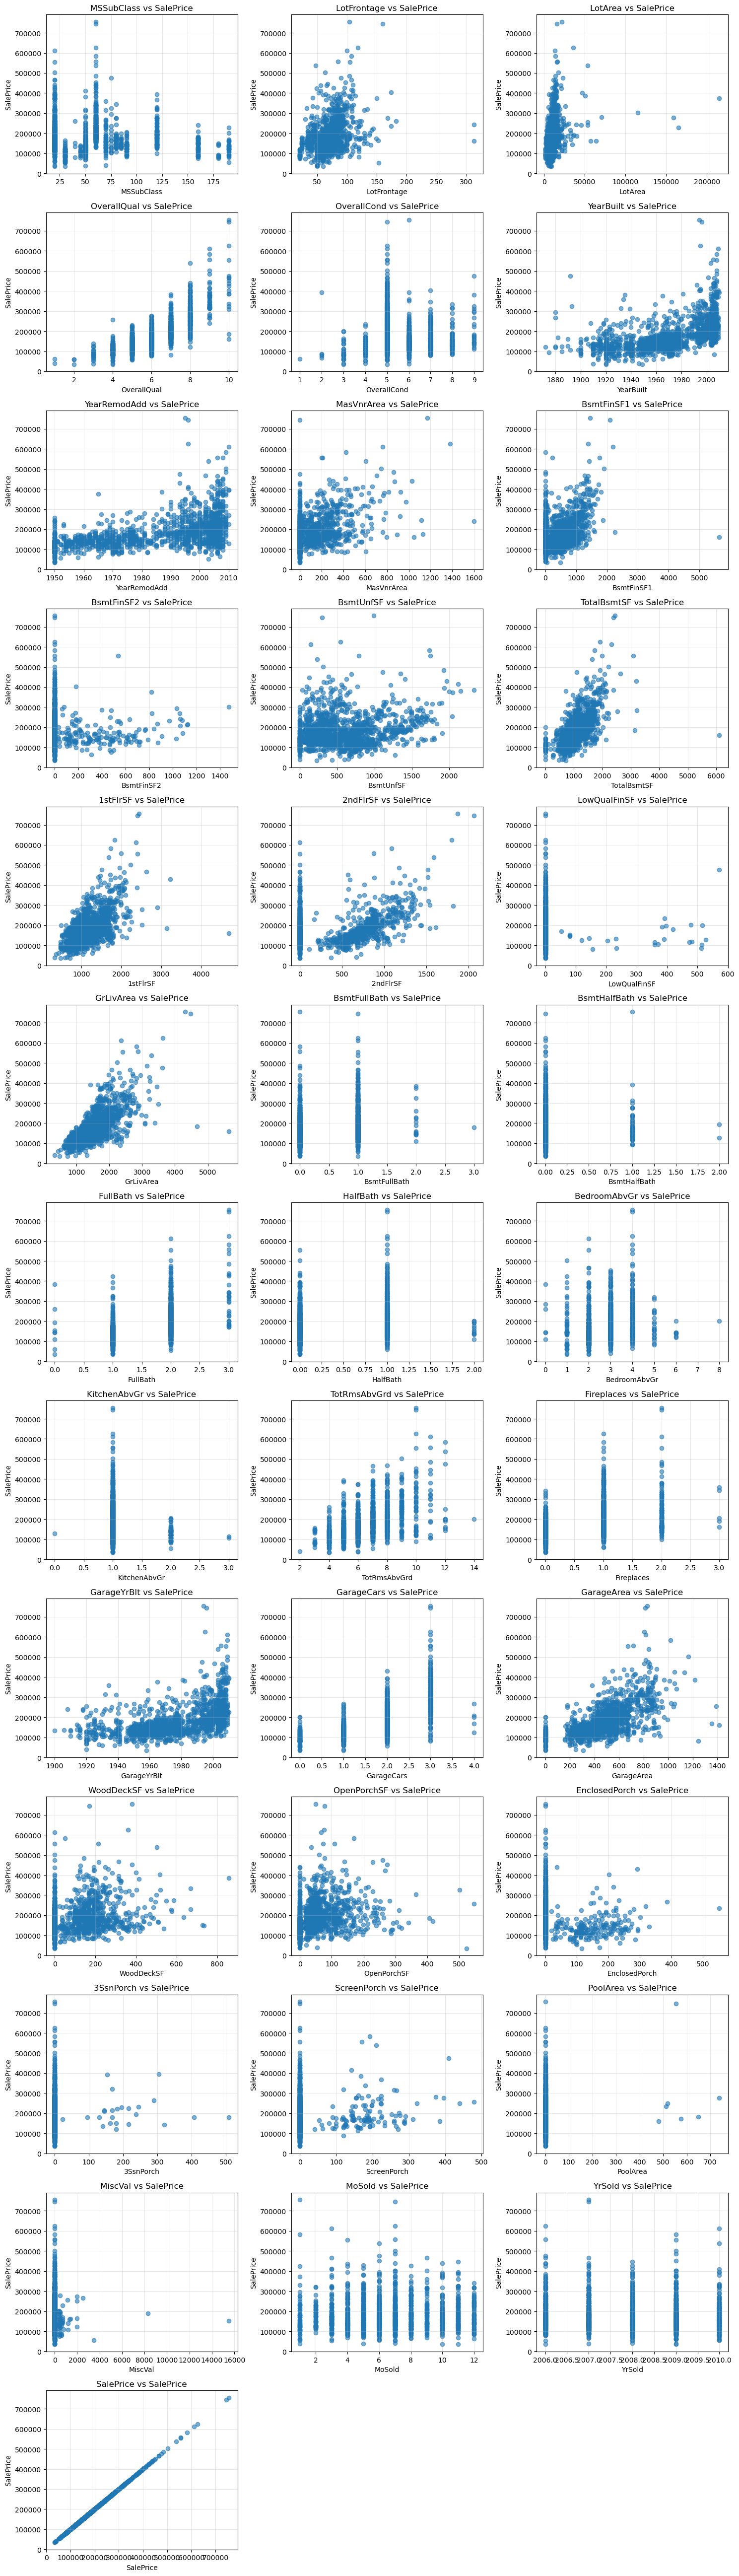

In [ ]:
def plot_multiple_scatters(df, columns, target='Sale Price'):
    """
    Vẽ scatterplot cho nhiều cột với cột mục tiêu
    """
    n_cols = len(columns)
    n_rows = (n_cols + 2) // 3  # Tối đa 3 cột mỗi hàng
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        if i < len(axes):
            axes[i].scatter(df[col], df[target], alpha=0.6)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel(target)
            axes[i].set_title(f'{col} vs {target}')
            axes[i].grid(True, alpha=0.3)
    
    # Ẩn các subplot thừa
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Sử dụng
plot_multiple_scatters(df, numeric_cols, target='SalePrice')

## Tương quan dữ liệu

Correlation with SalePrice:
SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbv

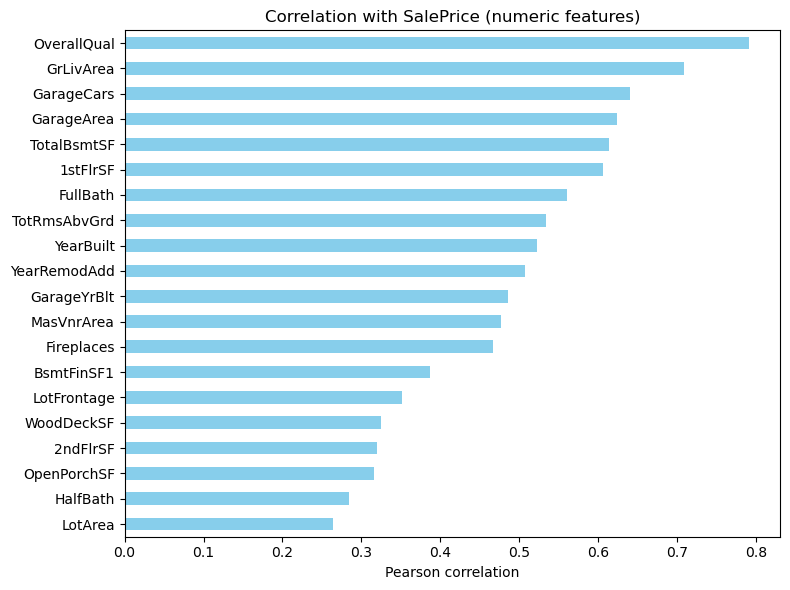

In [ ]:
# Hiển thị chỉ correlation giữa các biến số và SalePrice (dùng df_train để tránh NaN từ test)
num_df = df_train.select_dtypes(include=['number'])
corr_with_target = num_df.corr()['SalePrice'].sort_values(ascending=False)

print("Correlation with SalePrice:")
print(corr_with_target)

# Vẽ top k dương và top k âm
import matplotlib.pyplot as plt
import pandas as pd

k = 20
corr_no_target = corr_with_target.drop('SalePrice')
top_pos = corr_no_target.head(k)
top_neg = corr_no_target.tail(0)
to_plot = pd.concat([top_pos, top_neg]).sort_values()

plt.figure(figsize=(8, max(6, len(to_plot)*0.25)))
to_plot.plot(kind='barh', color='skyblue')
plt.title('Correlation with SalePrice (numeric features)')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

### Dữ liệu dạng số

<Figure size 3000x3000 with 0 Axes>

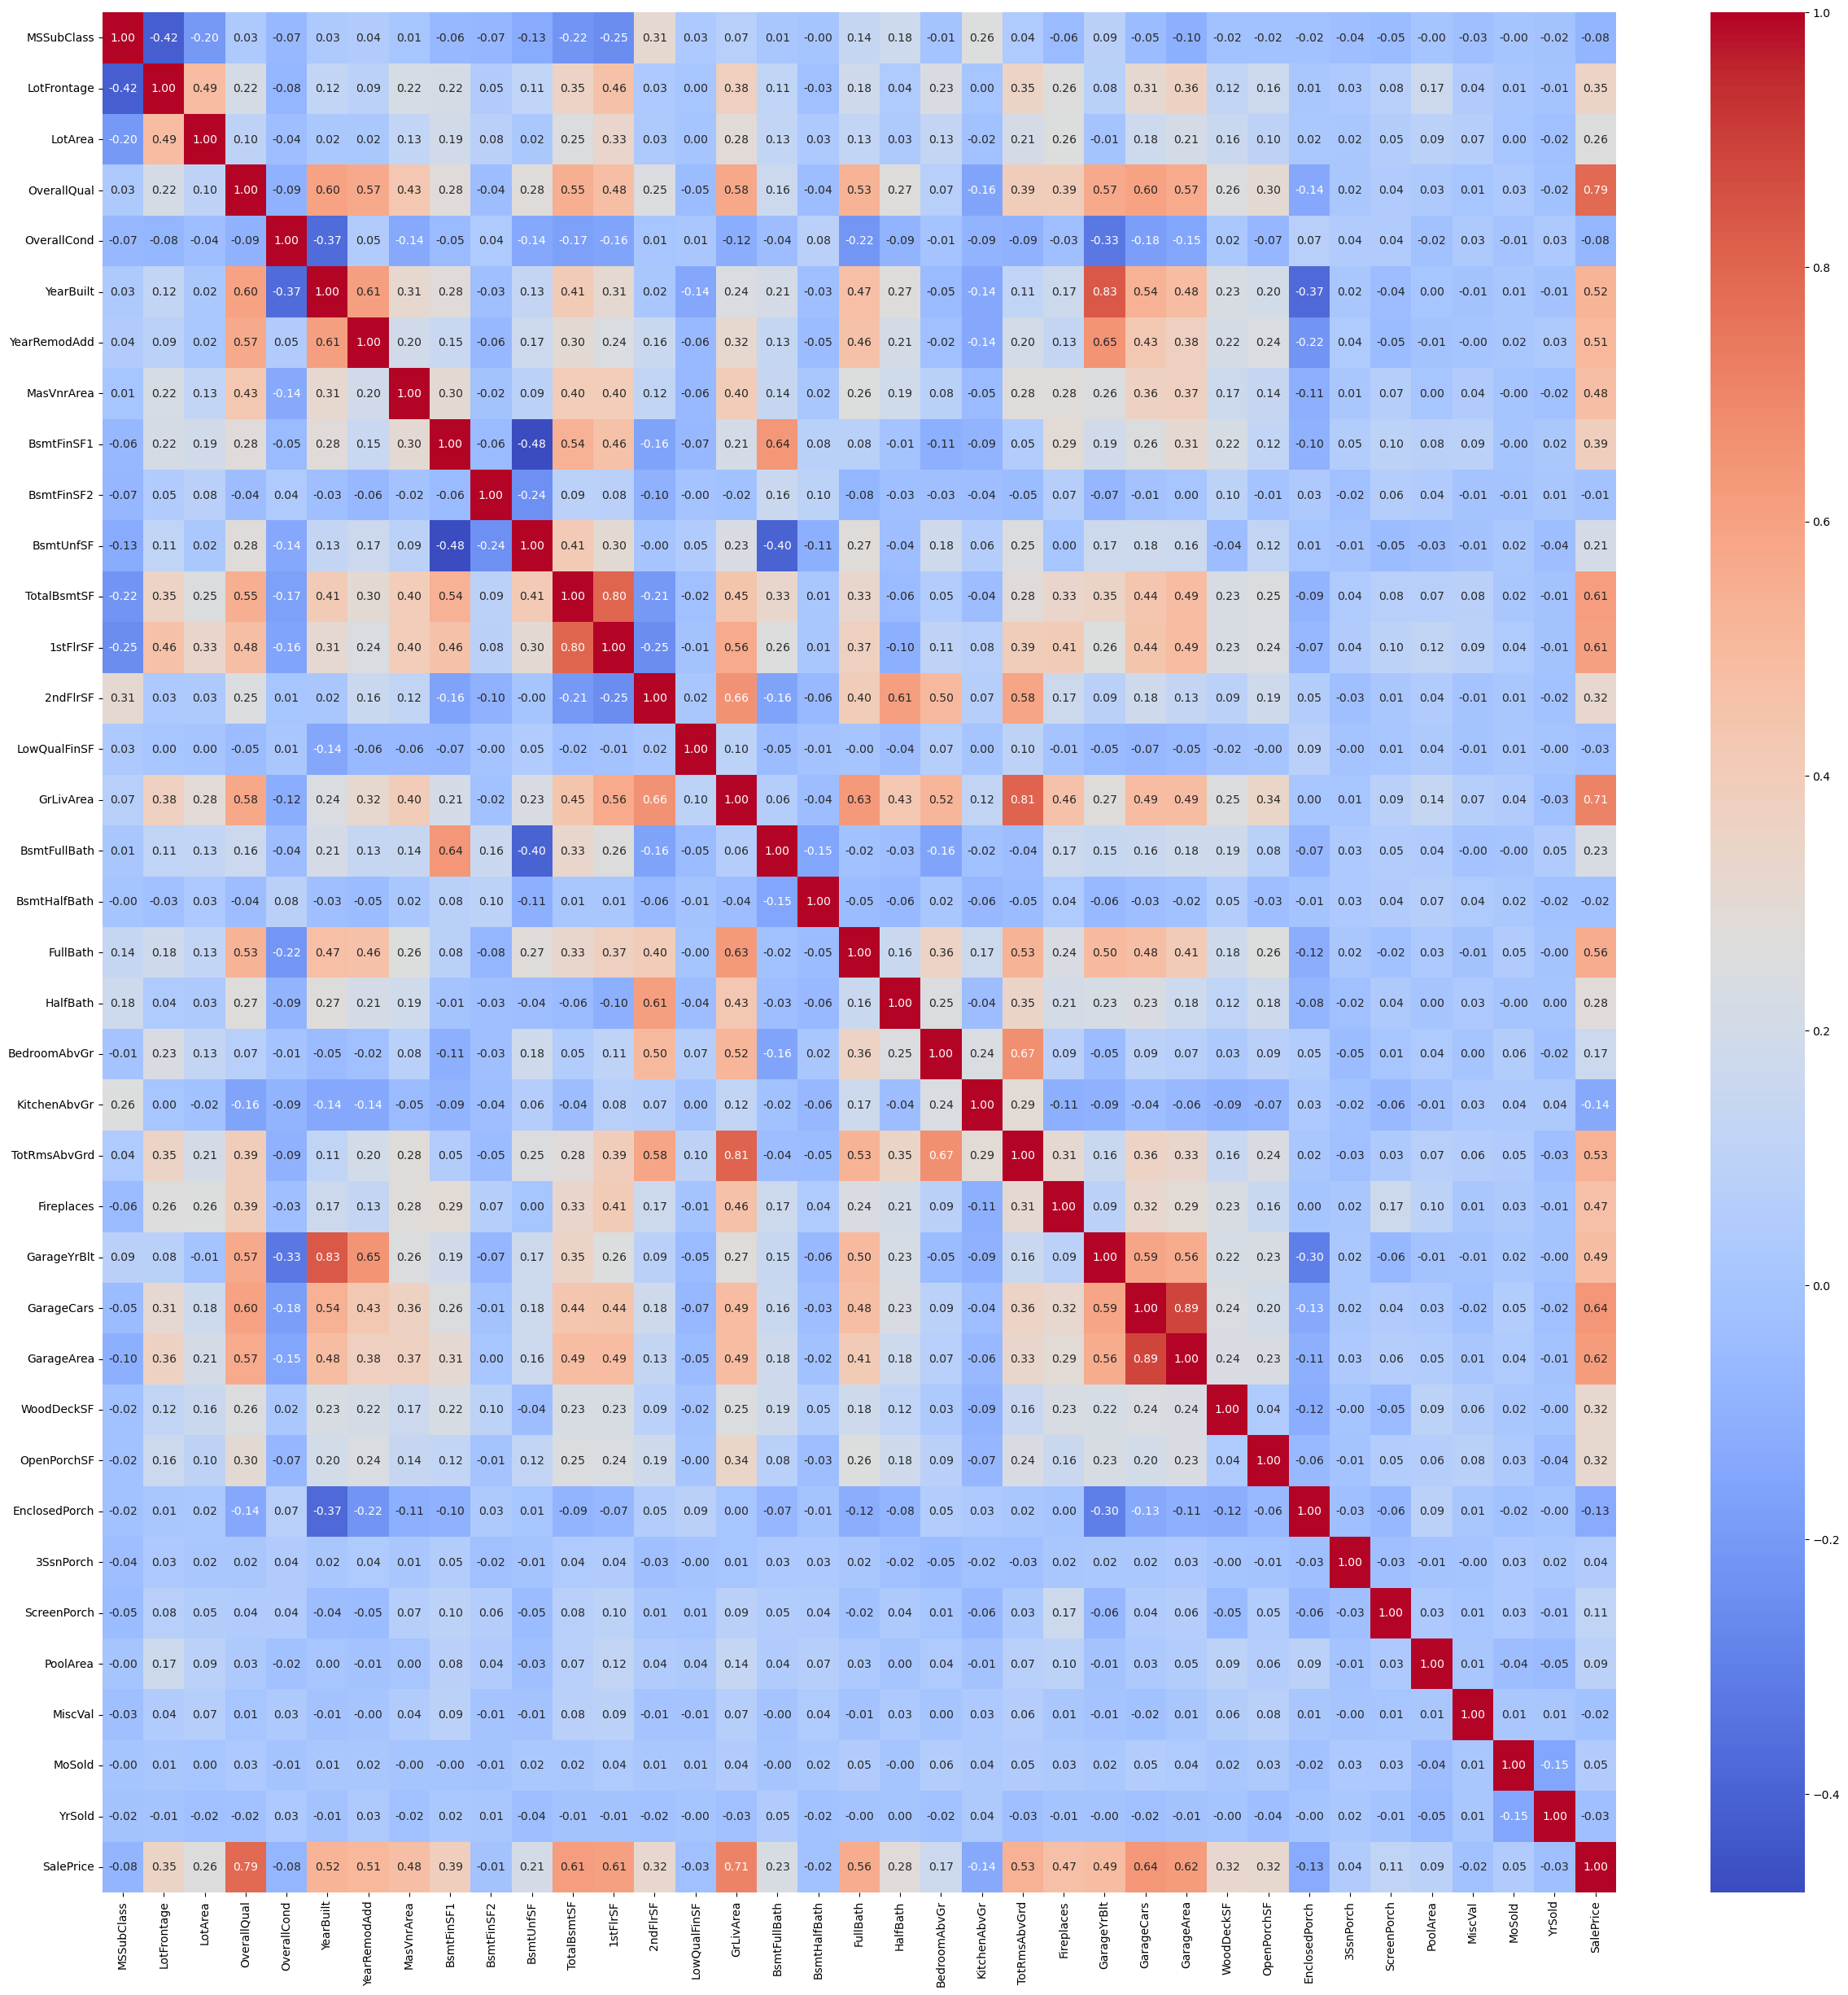

In [ ]:
plt.figure(figsize=(30, 30))
corr = df.select_dtypes(include=['number']).corr()
mask = np.triu(np.ones_like(corr))
sns.heatmap(corr, mask=None, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

### Dữ liệu dạng category

 1. BsmtQual_Ex: 0.5531
 2. KitchenQual_Ex: 0.5041
 3. Foundation_PConc: 0.4977
 4. ExterQual_Gd: 0.4525
 5. ExterQual_Ex: 0.4512
 6. BsmtFinType1_GLQ: 0.4346
 7. HeatingQC_Ex: 0.4345
 8. GarageFinish_Fin: 0.4197
 9. Neighborhood_NridgHt: 0.4021
10. SaleType_New: 0.3575
11. SaleCondition_Partial: 0.3521
12. FireplaceQu_Gd: 0.3393
13. GarageType_Attchd: 0.3360
14. MasVnrType_Stone: 0.3305
15. Neighborhood_NoRidge: 0.3304
16. KitchenQual_Gd: 0.3216
17. BsmtExposure_Gd: 0.3073
18. Exterior2nd_VinylSd: 0.3064
19. Exterior1st_VinylSd: 0.3050
20. GarageCond_TA: 0.2759


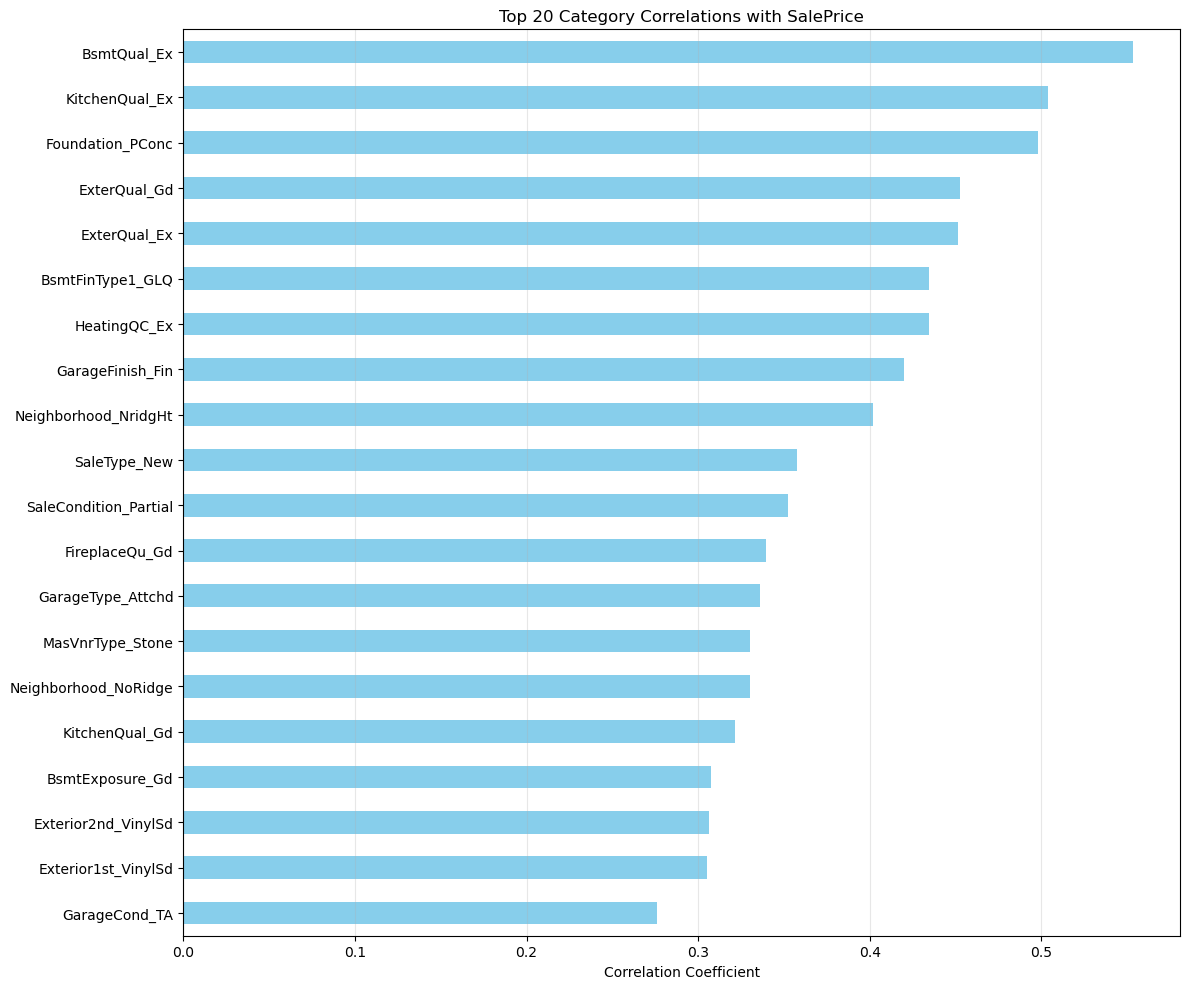

In [ ]:
def plot_category_correlations(df, category_columns, target_column='SalePrice', top_n=20):
    """
    Tính và vẽ correlation của các cột category với target sau khi one-hot encode
    """
    # One-hot encode các cột category
    df_encoded = pd.get_dummies(df[category_columns], prefix=category_columns)
    
    # Thêm cột target vào
    df_encoded[target_column] = df[target_column]
    
    # Tính correlation
    corr_with_target = df_encoded.corr()[target_column].sort_values(ascending=False)
    
    # Lọc chỉ lấy correlation với các category (bỏ target itself)
    category_corr = corr_with_target[corr_with_target.index != target_column]
    
    top_categories = category_corr.head(top_n)
    
    # In ra màn hình top N cột
    print("=" * 60)
    for i, (category, corr) in enumerate(top_categories.items(), 1):
        print(f"{i:2d}. {category}: {corr:.4f}")
    print("=" * 60)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 10))
    top_categories.sort_values().plot(kind='barh', color='skyblue')
    plt.title(f'Top {top_n} Category Correlations with {target_column}')
    plt.xlabel('Correlation Coefficient')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return category_corr

# Sử dụng
category_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
corr_results = plot_category_correlations(df, category_columns, top_n=20)

# Kết thúc